# PJ12_Asset_Simulator

# 데이터 불러오기

In [48]:
# ── 0-1. 라이브러리 Import ──────────────────────────
# 설치: pip install yfinance pandas-datareader scipy statsmodels scikit-learn

# 데이터 수집
import yfinance as yf
import pandas_datareader.data as web

# 데이터 처리
import pandas as pd
import numpy as np
from datetime import datetime

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 최적화 · 통계
from scipy.optimize import minimize
from scipy import stats
import statsmodels.api as sm

# 출력
import pprint as pprint

# 환경 설정
plt.style.use("dark_background")
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 한글
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ 환경 설정 완료")

✅ 환경 설정 완료


In [49]:
# ── 0-2. 투자 유니버스 정의 ─────────────────────────

PORTFOLIO_ASSETS = {
    "SPY": "S&P 500 (미국 대형주)",
    "QQQ": "NASDAQ-100 (미국 기술주)",
    "TLT": "US 20Y+ Treasury (미국 장기채)",
    "AGG": "US Aggregate Bond (미국 종합채권)",
    "GLD": "Gold (금 ETF)",
    "EEM": "Emerging Markets (신흥국 주식)",
}

print(f"📌 투자 유니버스: {len(PORTFOLIO_ASSETS)}개 ETF")
for ticker, name in PORTFOLIO_ASSETS.items():
    print(f"  {ticker:5s} → {name}")

📌 투자 유니버스: 6개 ETF
  SPY   → S&P 500 (미국 대형주)
  QQQ   → NASDAQ-100 (미국 기술주)
  TLT   → US 20Y+ Treasury (미국 장기채)
  AGG   → US Aggregate Bond (미국 종합채권)
  GLD   → Gold (금 ETF)
  EEM   → Emerging Markets (신흥국 주식)


In [50]:
# ── 0-3. 외부 리스크 지표 유니버스 정의 ──────────────

EXTERNAL_INDICATORS = {
    "CL=F":     "WTI 원유 선물",
    "GC=F":     "금 선물 (COMEX)",
    "SI=F":     "은 선물 (COMEX)",
    "BTC-USD":  "비트코인",
    "ETH-USD":  "이더리움",
    "^VIX":     "VIX (공포 지수)",
    "DX-Y.NYB": "DXY (달러 인덱스)",
}

# FRED 거시 지표 (pandas_datareader로 수집)
FRED_SERIES = {
    "DGS10":    "US 10Y Treasury Yield (금리)",
    "CPIAUCSL": "CPI (소비자물가지수)",
    "UNRATE":   "실업률",
}

print(f"📌 외부 지표: yfinance {len(EXTERNAL_INDICATORS)}개 + FRED {len(FRED_SERIES)}개")

📌 외부 지표: yfinance 7개 + FRED 3개


In [51]:
# ── 0-4A. yfinance 시세 수집 ─────────────────────────

START = "2021-01-01"
END   = "2025-12-31"

# 전체 티커 통합
all_tickers = list(PORTFOLIO_ASSETS.keys()) + list(EXTERNAL_INDICATORS.keys())

# 수정주가 기반 수집
raw = yf.download(
    all_tickers,
    start=START,
    end=END,
    auto_adjust=True,
    group_by="ticker",
)

# 종가(Close)만 추출하여 정리
price_data = {}
for ticker in all_tickers:
    try:
        series = raw[ticker]["Close"].dropna()
        price_data[ticker] = series
    except KeyError:
        print(f"⚠️ {ticker} 수집 실패 — 건너뜀")

df_prices = pd.DataFrame(price_data)
df_prices.index = pd.to_datetime(df_prices.index)
df_prices = df_prices.sort_index()

print(f"✅ 시세 수집 완료: {df_prices.shape[0]}일 × {df_prices.shape[1]}개 티커")
print(f"📅 기간: {df_prices.index[0].date()} ~ {df_prices.index[-1].date()}")
print(f"\n결측치 현황:")
print(df_prices.isnull().sum())

# all_tickers: 투자 자산 + 외부 지표 전체 목록
# auto_adjust=True: 배당·분할 반영 수정주가 자동 적용
# group_by="ticker": 티커별로 OHLCV 그룹핑
# 결측치: BTC는 24/7 거래, 선물은 평일만 → 비거래일 결측 발생 (Phase 1에서 처리)

[*********************100%***********************]  13 of 13 completed

✅ 시세 수집 완료: 1825일 × 13개 티커
📅 기간: 2021-01-01 ~ 2025-12-30

결측치 현황:
SPY         571
QQQ         571
TLT         571
AGG         571
GLD         571
EEM         571
CL=F        569
GC=F        569
SI=F        569
BTC-USD       0
ETH-USD       0
^VIX        571
DX-Y.NYB    569
dtype: int64


In [52]:
# ── 0-4B. FRED 거시 지표 수집 ────────────────────────

df_fred = {}
for series_id, name in FRED_SERIES.items():
    try:
        df_fred[series_id] = web.DataReader(
            series_id, "fred", START, END
        )[series_id]
        print(f"  ✅ {series_id}: {name}")
    except Exception as e:
        print(f"  ⚠️ {series_id} 수집 실패: {e}")

df_macro = pd.DataFrame(df_fred)
df_macro.index = pd.to_datetime(df_macro.index)

print(f"\n✅ FRED 수집 완료: {df_macro.shape}")
display(df_macro.tail(30))

# DGS10: 미국 10년 국채 수익률 (일별, %)
# CPIAUCSL: 소비자물가지수 (월별, 지수값 — 전월비 변화율로 변환 필요)
# UNRATE: 실업률 (월별, %)

  ✅ DGS10: US 10Y Treasury Yield (금리)
  ✅ CPIAUCSL: CPI (소비자물가지수)
  ✅ UNRATE: 실업률

✅ FRED 수집 완료: (1320, 3)


,DGS10,CPIAUCSL,UNRATE
DATE,,,
2025-11-20,4.1000,NaN,NaN
2025-11-21,4.0600,NaN,NaN
2025-11-24,4.0400,NaN,NaN
2025-11-25,4.0100,NaN,NaN
2025-11-26,4.0000,NaN,NaN
2025-11-27,NaN,NaN,NaN
2025-11-28,4.0200,NaN,NaN
2025-12-01,4.0900,326.0310,4.4000
2025-12-02,4.0900,NaN,NaN


In [53]:
# ── 0-4C. 데이터 검증 및 저장 ────────────────────────

# 기본 통계량 확인
print("=" * 60)
print("📊 투자 자산 기초 통계 (종가)")
print("=" * 60)
port_tickers = list(PORTFOLIO_ASSETS.keys())
print(df_prices[port_tickers].describe().round(2))

print("\n" + "=" * 60)
print("📊 외부 지표 기초 통계 (종가)")
print("=" * 60)
ext_tickers = list(EXTERNAL_INDICATORS.keys())
available_ext = [t for t in ext_tickers if t in df_prices.columns]
print(df_prices[available_ext].describe().round(2))

# CSV 저장 (선택)
df_prices.to_csv("prices.csv")
df_macro.to_csv("macro.csv")

print("\n✅ Phase 0 완료 — 데이터 수집 및 검증 완료")
print(f"  투자 자산: {len(port_tickers)}개")
print(f"  외부 지표: {len(available_ext)}개")
print(f"  FRED 거시: {len(FRED_SERIES)}개")

📊 투자 자산 기초 통계 (종가)
            SPY       QQQ       TLT       AGG       GLD       EEM
count 1254.0000 1254.0000 1254.0000 1254.0000 1254.0000 1254.0000
mean   468.4500  398.4400   97.0400   92.8700  210.9000   41.9000
std     94.8200   98.2100   15.8800    4.7700   60.8100    5.5100
min    340.2500  254.9400   74.5400   82.6500  151.2300   31.0400
25%    392.6700  317.4000   85.3000   88.9300  169.3400   37.0400
50%    429.8600  367.5700   89.9200   92.8500  181.8800   41.2100
75%    548.2100  475.8800  111.5000   97.8600  240.4900   46.1400
max    688.5000  634.1500  133.2200  100.7600  416.7400   55.2200

📊 외부 지표 기초 통계 (종가)
           CL=F      GC=F      SI=F     BTC-USD   ETH-USD      ^VIX  DX-Y.NYB
count 1256.0000 1256.0000 1256.0000   1825.0000 1825.0000 1254.0000 1256.0000
mean    76.1000 2274.8500   27.7200  54408.2300 2534.5600   19.3500  100.9900
std     12.9500  669.0900    8.1000  29461.7000  911.7400    5.2900    5.4400
min     47.6200 1623.3000   17.5500  15787.2800  730.37

# Proprocessing & EDA

In [54]:
# ── 1-1. 거래일 통합 및 결측치 처리 ──────────────────

# NYSE 영업일 캘린더 기준 리인덱싱
nyse_dates = pd.bdate_range(start=START, end=END, freq="B")
df_prices = df_prices.reindex(nyse_dates)

# Forward fill → 잔여 결측은 Backward fill
df_prices = df_prices.ffill().bfill()

# FRED 거시 데이터도 동일 캘린더에 맞춤
df_macro = df_macro.reindex(nyse_dates).ffill().bfill()

# CPI: 지수값 → 전월비 변화율(%) 변환
if "CPIAUCSL" in df_macro.columns:
    df_macro["CPI_MoM"] = df_macro["CPIAUCSL"].pct_change() * 100

print(f"✅ 캘린더 통합 완료: {len(nyse_dates)}영업일")
print(f"결측치 잔여: {df_prices.isnull().sum().sum()}")
print(f"\nFRED 컬럼: {list(df_macro.columns)}")

# pd.bdate_range: 영업일(Business Day)만 생성
# ffill(): 전일 값으로 채움 — "거래 없음 = 가격 불변" 가정
# bfill(): ffill 후에도 남는 초기 결측 처리 (시작일 이전 데이터 없는 경우)
# CPI_MoM: 월별 소비자물가 전월비 변화율 — 인플레이션 추세 파악용

✅ 캘린더 통합 완료: 1304영업일
결측치 잔여: 0

FRED 컬럼: ['DGS10', 'CPIAUCSL', 'UNRATE', 'CPI_MoM']


In [55]:
# ── 1-2. 로그 수익률 산출 ────────────────────────────

# 투자 자산 로그 수익률
port_tickers = list(PORTFOLIO_ASSETS.keys())
df_port_ret = np.log(df_prices[port_tickers] / df_prices[port_tickers].shift(1)).dropna()

# 외부 지표 로그 수익률 (VIX는 수준값이므로 차분 사용)
ext_tickers = [t for t in EXTERNAL_INDICATORS.keys() if t in df_prices.columns]
df_ext_ret = pd.DataFrame(index=df_port_ret.index)

for ticker in ext_tickers:
    if ticker == "^VIX":
        # VIX는 변동성 수준값 → 1차 차분 (로그 변환 아닌 절대 변화)
        df_ext_ret[ticker] = df_prices[ticker].diff()
    else:
        df_ext_ret[ticker] = np.log(df_prices[ticker] / df_prices[ticker].shift(1))

df_ext_ret = df_ext_ret.reindex(df_port_ret.index).dropna()

# 전체 수익률 통합
df_all_ret = pd.concat([df_port_ret, df_ext_ret], axis=1).dropna()

print(f"✅ 수익률 산출 완료: {df_all_ret.shape[0]}일 × {df_all_ret.shape[1]}개 변수")
print(f"\n📊 투자 자산 수익률 기초 통계:")
display(df_port_ret.describe().round(6))

# np.log(P_t / P_{t-1}): 로그 수익률 공식
# VIX 차분 이유: VIX는 이미 변동성(%) 단위 → 로그 변환 시 의미 왜곡
# df_all_ret: 투자 자산 + 외부 지표 통합 수익률 — 이후 Phase에서 핵심 입력

✅ 수익률 산출 완료: 1303일 × 13개 변수

📊 투자 자산 수익률 기초 통계:


,SPY,QQQ,TLT,AGG,GLD,EEM
count,1303.0000,1303.0000,1303.0000,1303.0000,1303.0000,1303.0000
mean,0.0005,0.0006,-0.0003,-0.0000,0.0006,0.0001
std,0.0106,0.0140,0.0099,0.0037,0.0097,0.0113
min,-0.0603,-0.0641,-0.0348,-0.0165,-0.0664,-0.0572
25%,-0.0042,-0.0061,-0.0068,-0.0022,-0.0044,-0.0059
50%,0.0004,0.0007,0.0000,0.0000,0.0003,0.0000
75%,0.0060,0.0081,0.0057,0.0022,0.0059,0.0065
max,0.0999,0.1134,0.0378,0.0212,0.0363,0.0775


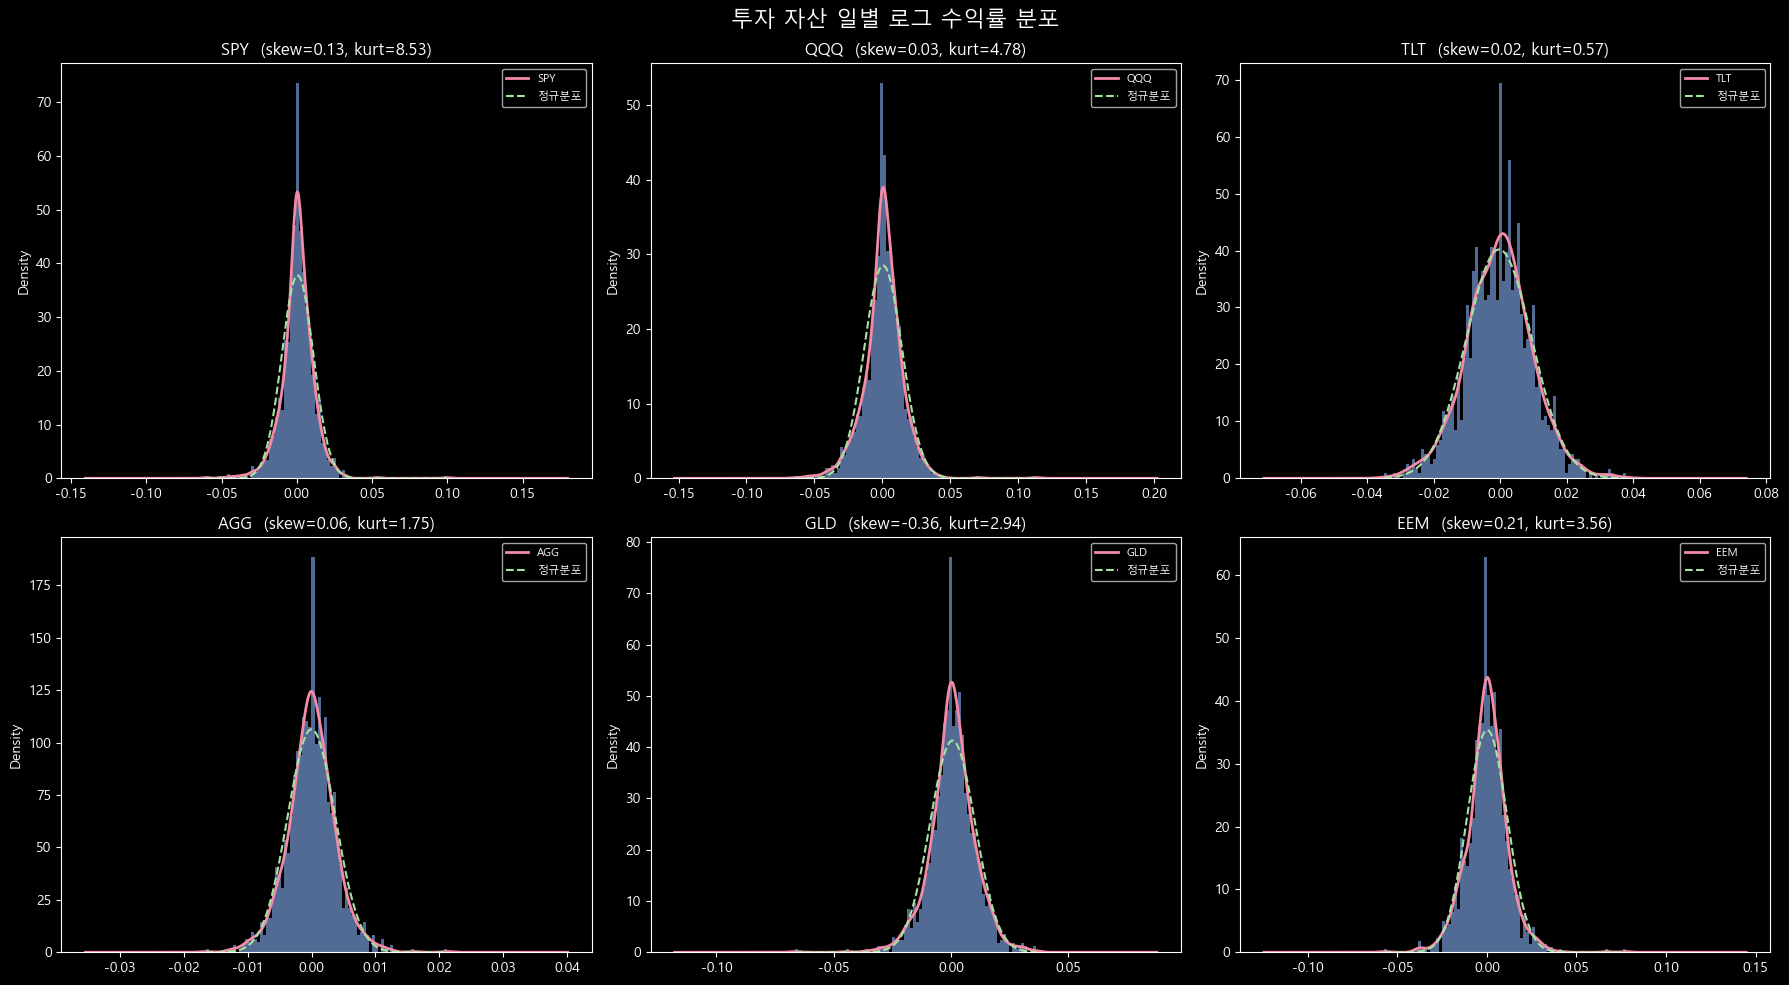

In [56]:
# ── 1-3A. 수익률 분포 시각화 ─────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("투자 자산 일별 로그 수익률 분포", fontsize=16, color="white")

for idx, ticker in enumerate(port_tickers):
    ax = axes[idx // 3, idx % 3]
    data = df_port_ret[ticker]

    # 히스토그램 + KDE
    ax.hist(data, bins=80, density=True, alpha=0.6,
            color="#89b4fa", edgecolor="none")
    data.plot.kde(ax=ax, color="#f38ba8", linewidth=2)

    # 정규분포 오버레이 (비교용)
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, data.mean(), data.std()),
            "--", color="#a6e3a1", linewidth=1.5, label="정규분포")

    # 통계량 표시
    skew = data.skew()
    kurt = data.kurtosis()  # 초과 첨도 (정규분포 = 0)
    ax.set_title(f"{ticker}  (skew={skew:.2f}, kurt={kurt:.2f})", fontsize=12)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# hist + kde: 실제 분포 형태 시각화
# norm.pdf 오버레이: 정규분포 대비 꼬리 두께 비교
# skew(): 왜도 — 0이면 대칭, 음수면 왼쪽 꼬리 긺 (손실 쪽 극단값 다수)
# kurtosis(): 초과 첨도 — 0이면 정규분포, 양수면 팻테일 (극단값 빈번)

In [57]:
# ── 1-3B. 왜도·첨도 요약 ─────────────────────────────

stats_summary = pd.DataFrame({
    "평균(일)": df_port_ret.mean(),
    "표준편차(일)": df_port_ret.std(),
    "왜도": df_port_ret.skew(),
    "초과첨도": df_port_ret.kurtosis(),
    "연율수익률": df_port_ret.mean() * 252,
    "연율변동성": df_port_ret.std() * np.sqrt(252),
}).round(4)

print("📊 투자 자산 수익률 분포 요약:")
display(stats_summary)
print("\n해석 가이드:")
print("  왜도 < 0  → 왼쪽 꼬리 긺 (손실 극단값이 이익보다 빈번)")
print("  첨도 > 0  → 팻테일 (극단값이 정규분포보다 자주 발생)")

# 연율수익률: 일평균 × 252영업일
# 연율변동성: 일표준편차 × √252 — 시간 스케일링 (분산의 시간 합산 원리)

📊 투자 자산 수익률 분포 요약:


,평균(일),표준편차(일),왜도,초과첨도,연율수익률,연율변동성
SPY,0.0005,0.0106,0.1330,8.5346,0.1336,0.1676
QQQ,0.0006,0.0140,0.0340,4.7800,0.1401,0.2222
TLT,-0.0003,0.0099,0.0235,0.5693,-0.0827,0.1576
AGG,-0.0000,0.0037,0.0614,1.7536,-0.0031,0.0595
GLD,0.0006,0.0097,-0.3634,2.9430,0.1514,0.1533
EEM,0.0001,0.0113,0.2135,3.5609,0.0330,0.1790



해석 가이드:
  왜도 < 0  → 왼쪽 꼬리 긺 (손실 극단값이 이익보다 빈번)
  첨도 > 0  → 팻테일 (극단값이 정규분포보다 자주 발생)


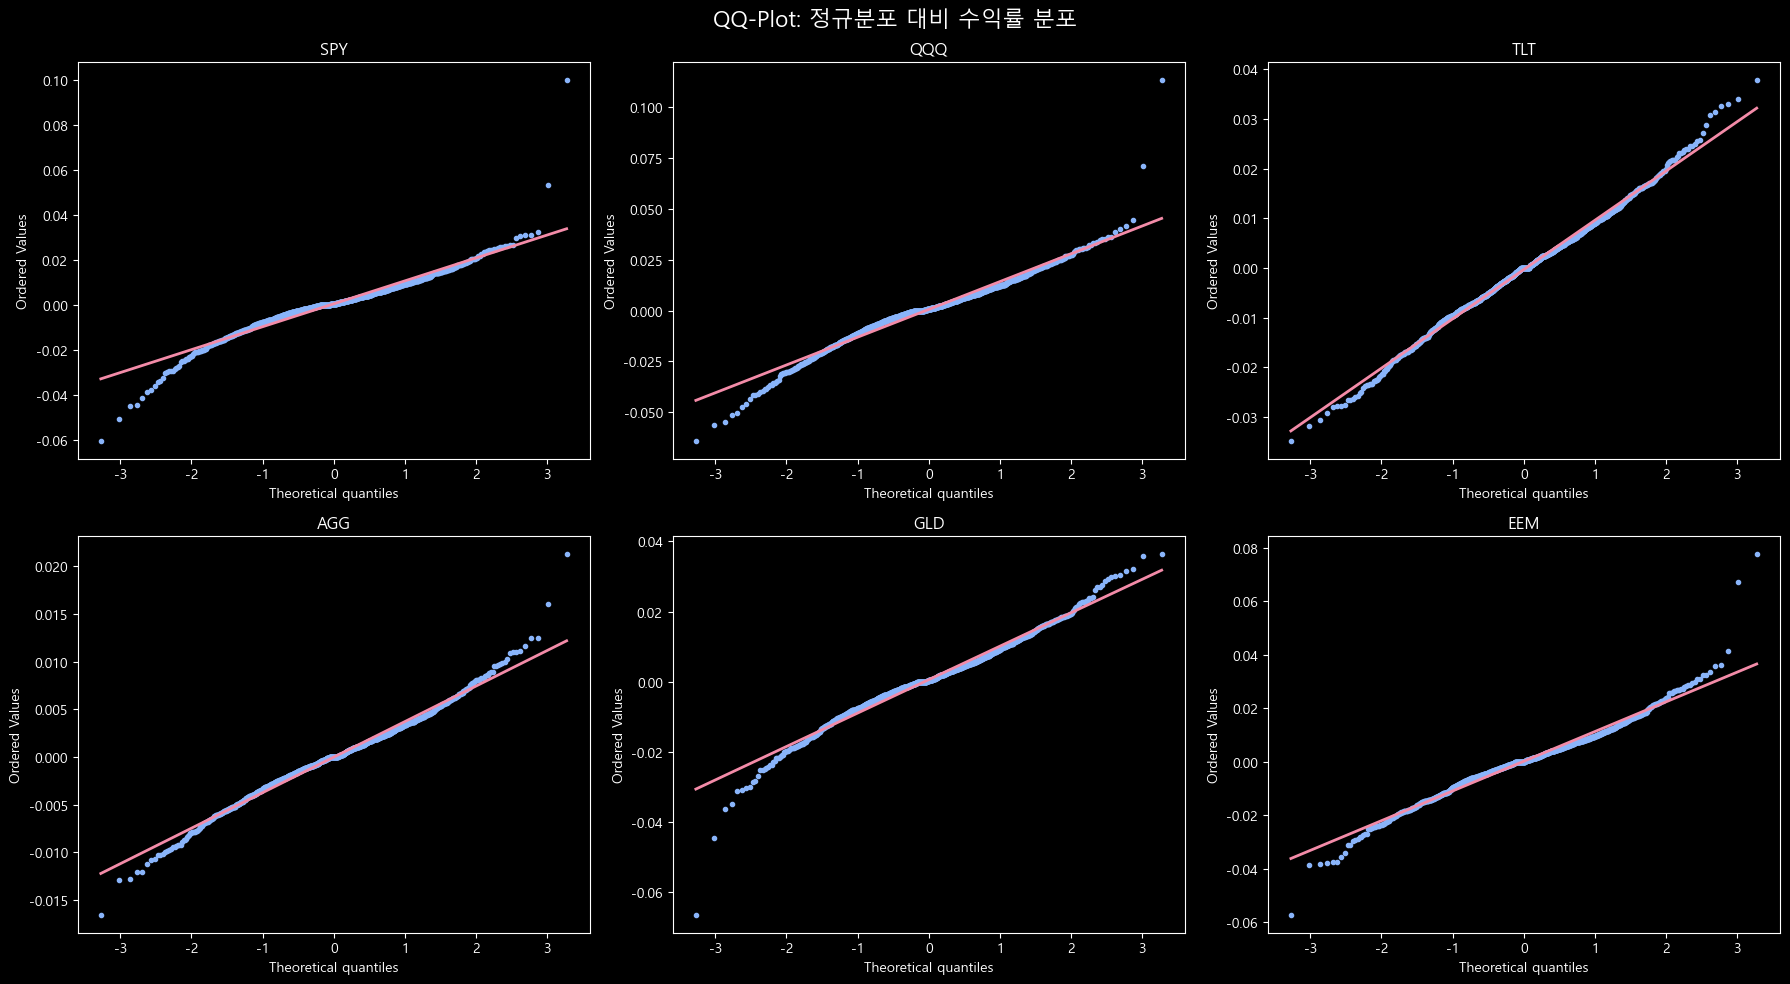

In [58]:
# ── 1-3C. QQ-Plot ────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("QQ-Plot: 정규분포 대비 수익률 분포", fontsize=16, color="white")

for idx, ticker in enumerate(port_tickers):
    ax = axes[idx // 3, idx % 3]
    stats.probplot(df_port_ret[ticker], dist="norm", plot=ax)
    ax.set_title(f"{ticker}", fontsize=12)
    ax.get_lines()[0].set(color="#89b4fa", markersize=3)  # 데이터 점
    ax.get_lines()[1].set(color="#f38ba8", linewidth=2)    # 기준선

plt.tight_layout()
plt.show()

# QQ-Plot 해석:
#   직선 위의 점: 정규분포와 일치
#   양쪽 끝 위로 벗어남: 양쪽 꼬리가 두꺼움 (팻테일)
#   왼쪽 아래로 벗어남: 왼쪽 꼬리가 더 두꺼움 (음의 왜도)
# 금융 데이터는 대부분 양쪽 끝에서 직선 이탈 → 정규분포 가정 한계 확인

In [59]:
# ── 1-3D. Shapiro-Wilk 정규성 검정 ──────────────────────

from scipy import stats

print("📊 Shapiro-Wilk 정규성 검정 결과:")
print("-" * 50)
print(f"{'Ticker':<10} | {'W-Statistic':<12} | {'p-value':<10} | {'결과'}")
print("-" * 50)

for ticker in port_tickers:
    # 결측치 제거 후 검정 수행
    data = df_port_ret[ticker].dropna()
    
    # 데이터 개수가 너무 많으면(>5000) Shapiro 검정의 정확도가 떨어질 수 있으나, 
    # 통상적인 일별 수익률 분석에서는 유효합니다.
    shapiro_stat, p_value = stats.shapiro(data)
    
    # 결과 해석 (유의수준 0.05 기준)
    is_normal = "정규분포 아님" if p_value < 0.05 else "정규분포 가능성"
    
    print(f"{ticker:<10} | {shapiro_stat:12.4f} | {p_value:10.4f} | {is_normal}")

print("-" * 50)
print("💡 해석: 금융 데이터 특성상 대부분 p-value가 0.0000으로 나오며, 이는 '정규분포가 아님'을 강력하게 시사합니다.")


📊 Shapiro-Wilk 정규성 검정 결과:
--------------------------------------------------
Ticker     | W-Statistic  | p-value    | 결과
--------------------------------------------------
SPY        |       0.9326 |     0.0000 | 정규분포 아님
QQQ        |       0.9564 |     0.0000 | 정규분포 아님
TLT        |       0.9960 |     0.0018 | 정규분포 아님
AGG        |       0.9851 |     0.0000 | 정규분포 아님
GLD        |       0.9729 |     0.0000 | 정규분포 아님
EEM        |       0.9692 |     0.0000 | 정규분포 아님
--------------------------------------------------
💡 해석: 금융 데이터 특성상 대부분 p-value가 0.0000으로 나오며, 이는 '정규분포가 아님'을 강력하게 시사합니다.


In [60]:
# ── 1-4. 거시 지표 변화율(Returns) 계산 ──────────────────

# 수집된 df_macro 데이터를 바탕으로 일별 변화율을 계산합니다.
# pct_change()를 통해 전일 대비 변화율을 구하고, 첫 번째 행의 결측치(NaN)를 제거합니다.
df_macro_ret = df_macro.pct_change().dropna()

# 만약 금리(DGS10)나 실업률(UNRATE)의 단순 '수치 차이'를 보고 싶다면 
# 아래와 같이 diff()를 사용할 수도 있지만, 
# 일반적으로 자산 수익률과 맞추기 위해 pct_change()를 많이 사용합니다.

print("✅ df_macro_ret 정의 완료!")
display(df_macro_ret.tail())


✅ df_macro_ret 정의 완료!


,DGS10,CPIAUCSL,UNRATE,CPI_MoM
2025-08-04,-0.0024,0.0000,0.0000,-1.0000
2025-09-01,0.0000,0.0030,0.0233,inf
2025-09-02,0.0118,0.0000,0.0000,-1.0000
2025-12-01,0.0174,0.0055,0.0000,inf
2025-12-02,0.0000,0.0000,0.0000,-1.0000


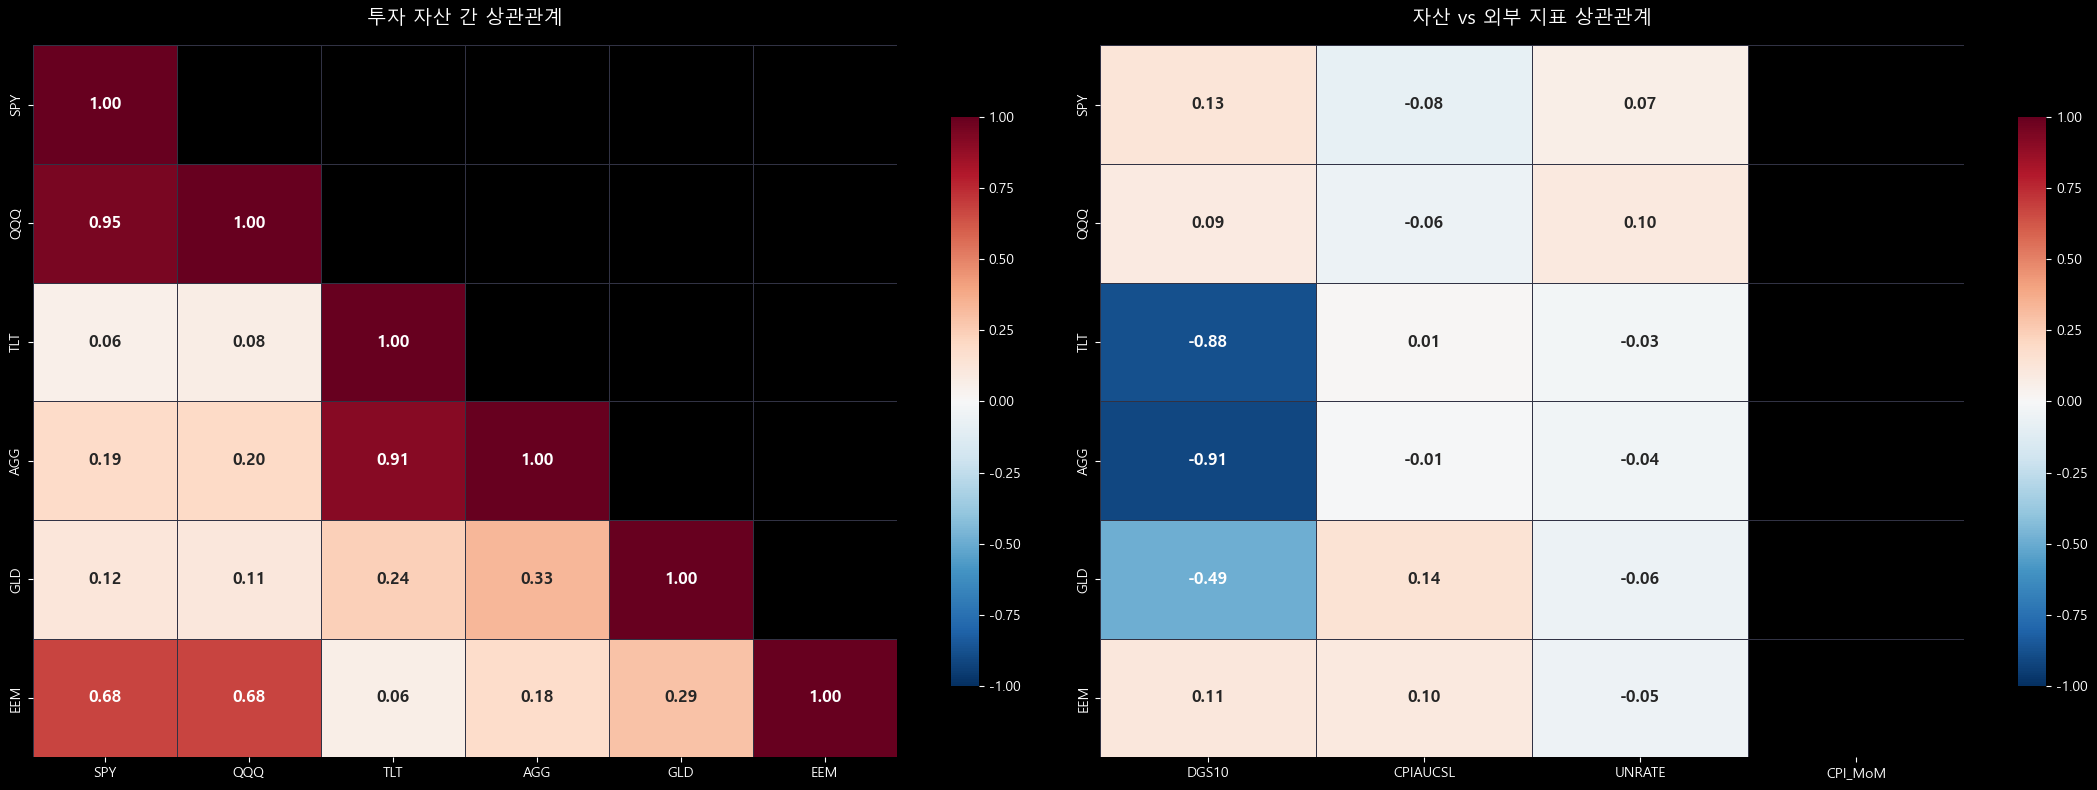

In [61]:
# ── 1-4A. 투자 자산 및 외부 지표 상관관계 히트맵 ──────────

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# (A) 투자 자산 내부 상관관계 (왼쪽)
corr_port = df_port_ret.corr()
mask_port = np.triu(np.ones_like(corr_port, dtype=bool), k=1)

sns.heatmap(
    corr_port, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, ax=axes[0], mask=mask_port,
    annot_kws={"fontsize": 12, "fontweight": "bold"},
    linewidths=0.5, linecolor="#313244",
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("투자 자산 간 상관관계", fontsize=14, color="white", pad=15)


# (B) 투자 자산 vs 외부 지표 상관관계 (오른쪽) - 추가된 부분
# 두 데이터프레임을 합쳐서 서로 간의 상관관계를 구합니다.
df_combined = pd.concat([df_port_ret, df_macro_ret], axis=1)
corr_external = df_combined.corr().loc[df_port_ret.columns, df_macro_ret.columns]

sns.heatmap(
    corr_external, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, ax=axes[1], # axes[1]에 그리도록 설정
    annot_kws={"fontsize": 12, "fontweight": "bold"},
    linewidths=0.5, linecolor="#313244",
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("자산 vs 외부 지표 상관관계", fontsize=14, color="white", pad=15)

plt.tight_layout()
plt.show()


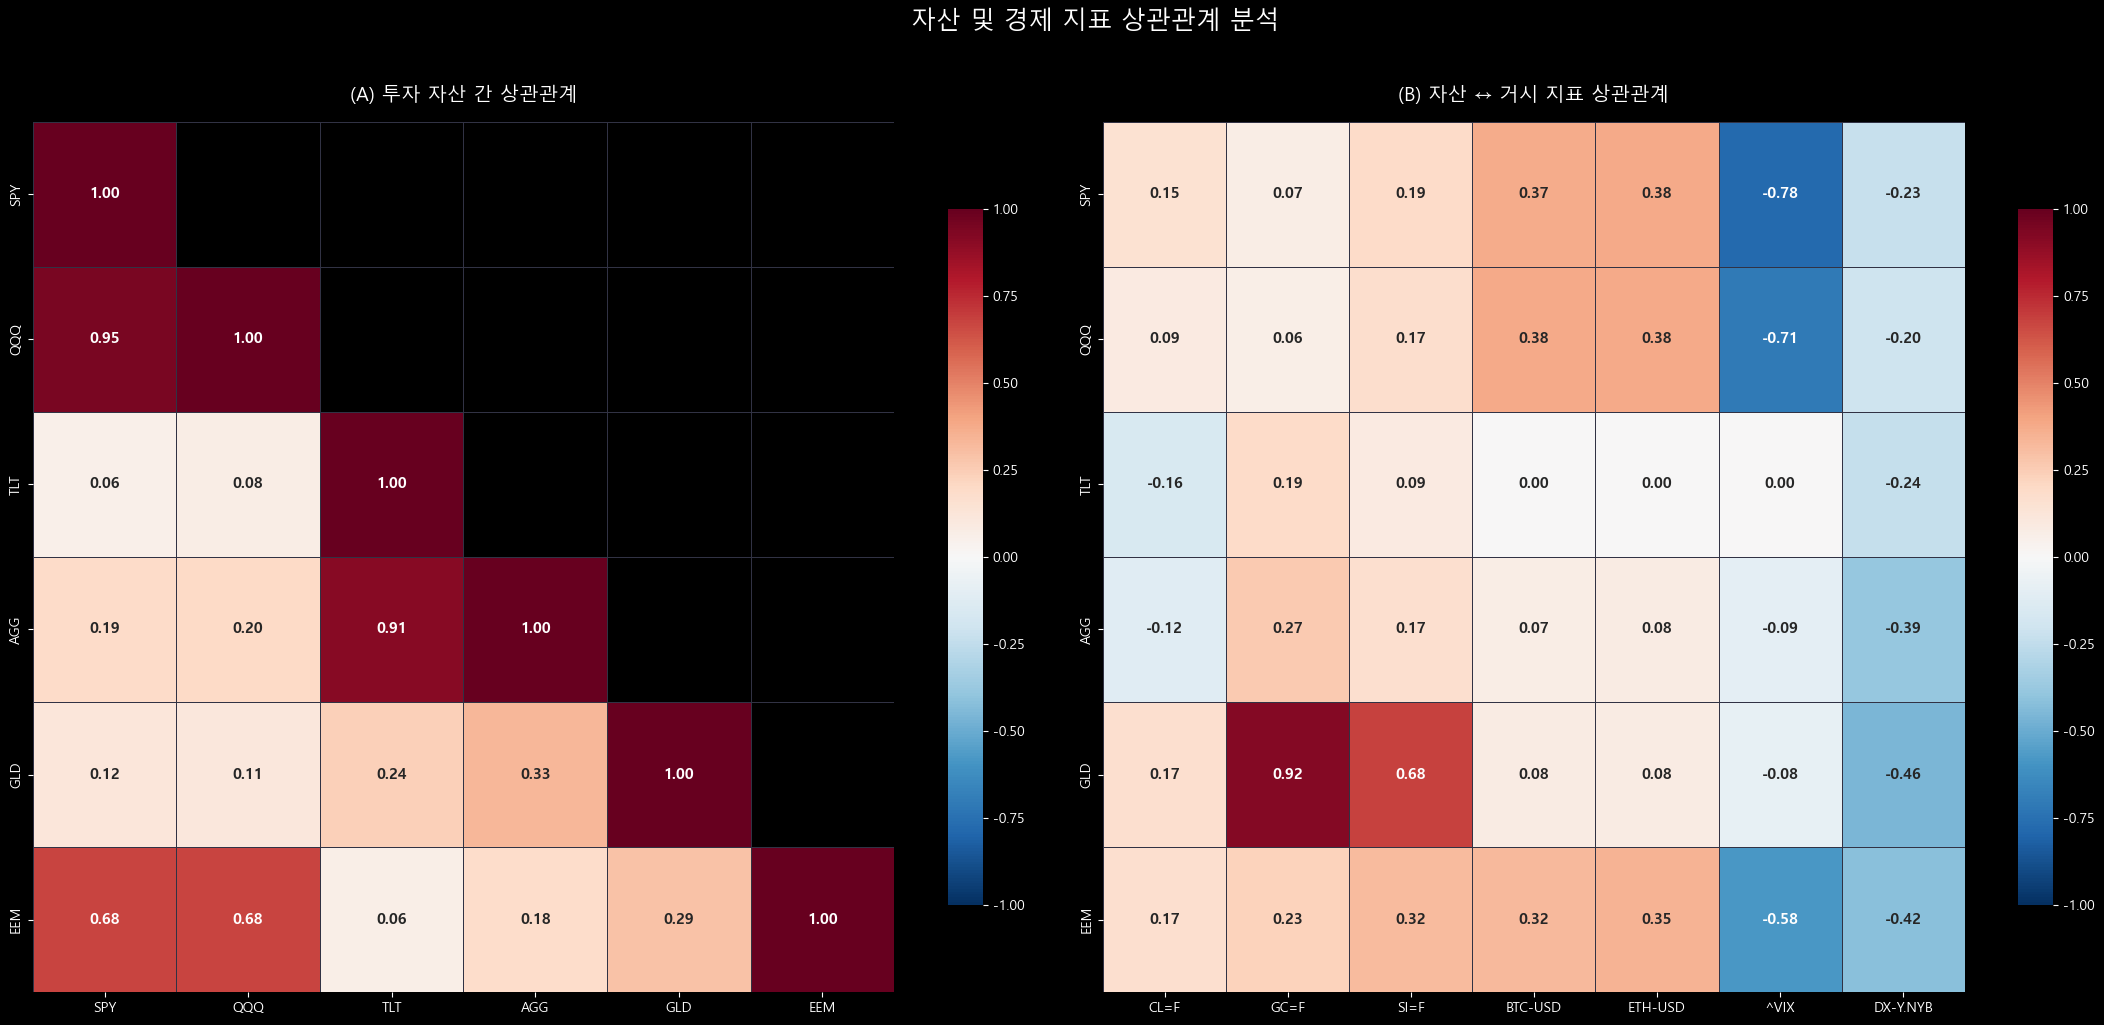


📊 교차 상관 매트릭스 수치:


,CL=F,GC=F,SI=F,BTC-USD,ETH-USD,^VIX,DX-Y.NYB
SPY,0.1540,0.0720,0.1920,0.3690,0.3790,-0.7750,-0.2290
QQQ,0.0890,0.0640,0.1720,0.3750,0.3800,-0.7090,-0.2040
TLT,-0.1600,0.1920,0.0930,0.0010,0.0040,0.0050,-0.2380
AGG,-0.1190,0.2660,0.1650,0.0740,0.0810,-0.0940,-0.3850
GLD,0.1670,0.9210,0.6810,0.0830,0.0780,-0.0810,-0.4590
EEM,0.1690,0.2270,0.3170,0.3230,0.3500,-0.5800,-0.4170


In [62]:
# ── 1-4. 상관관계 분석 통합 시각화 ────────────────────

# 1. 도화지(Figure) 생성 - 한 셀 안에서 한꺼번에 실행해야 합니다.
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle("자산 및 경제 지표 상관관계 분석", fontsize=18, color="white", y=1.02)

# [A] 투자 자산 간 상관관계 (왼쪽)
corr_port = df_port_ret.corr()
mask_port = np.triu(np.ones_like(corr_port, dtype=bool), k=1)

sns.heatmap(
    corr_port, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, ax=axes[0], mask=mask_port,
    annot_kws={"fontsize": 11, "fontweight": "bold"},
    linewidths=0.5, linecolor="#313244",
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("(A) 투자 자산 간 상관관계", fontsize=14, color="white", pad=15)


# [B] 투자 자산 ↔ 외부 지표 교차 상관 (오른쪽)
# df_all_ret이 이미 합쳐진 데이터프레임이라고 가정합니다.
corr_full = df_all_ret.corr()

# 만약 여기서 에러가 난다면 port_tickers나 ext_tickers와 컬럼명이 일치하는지 확인이 필요합니다.
try:
    corr_cross = corr_full.loc[port_tickers, ext_tickers]

    sns.heatmap(
        corr_cross, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
        vmin=-1, vmax=1, ax=axes[1],
        annot_kws={"fontsize": 11, "fontweight": "bold"},
        linewidths=0.5, linecolor="#313244",
        cbar_kws={"shrink": 0.8}
    )
    axes[1].set_title("(B) 자산 ↔ 거시 지표 상관관계", fontsize=14, color="white", pad=15)
except KeyError as e:
    print(f"⚠️ 티커 이름이 일치하지 않습니다: {e}")

plt.tight_layout()
plt.show()

# 데이터 숫자로도 확인
print("\n📊 교차 상관 매트릭스 수치:")
display(corr_cross.round(3))


# corr_cross: 행 = 투자 자산, 열 = 외부 지표 — 교차 관계만 추출
# 핵심 관찰 포인트:
#   SPY ↔ ^VIX: 강한 음의 상관 (시장 하락 시 VIX 급등)
#   TLT ↔ DGS10: 강한 음의 상관 (금리 상승 → 채권 가격 하락)
#   GLD ↔ DX-Y.NYB: 음의 상관 (달러 강세 → 금 가격 하락)
#   EEM ↔ DX-Y.NYB: 음의 상관 (달러 강세 → 신흥국 자산 약세)

c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


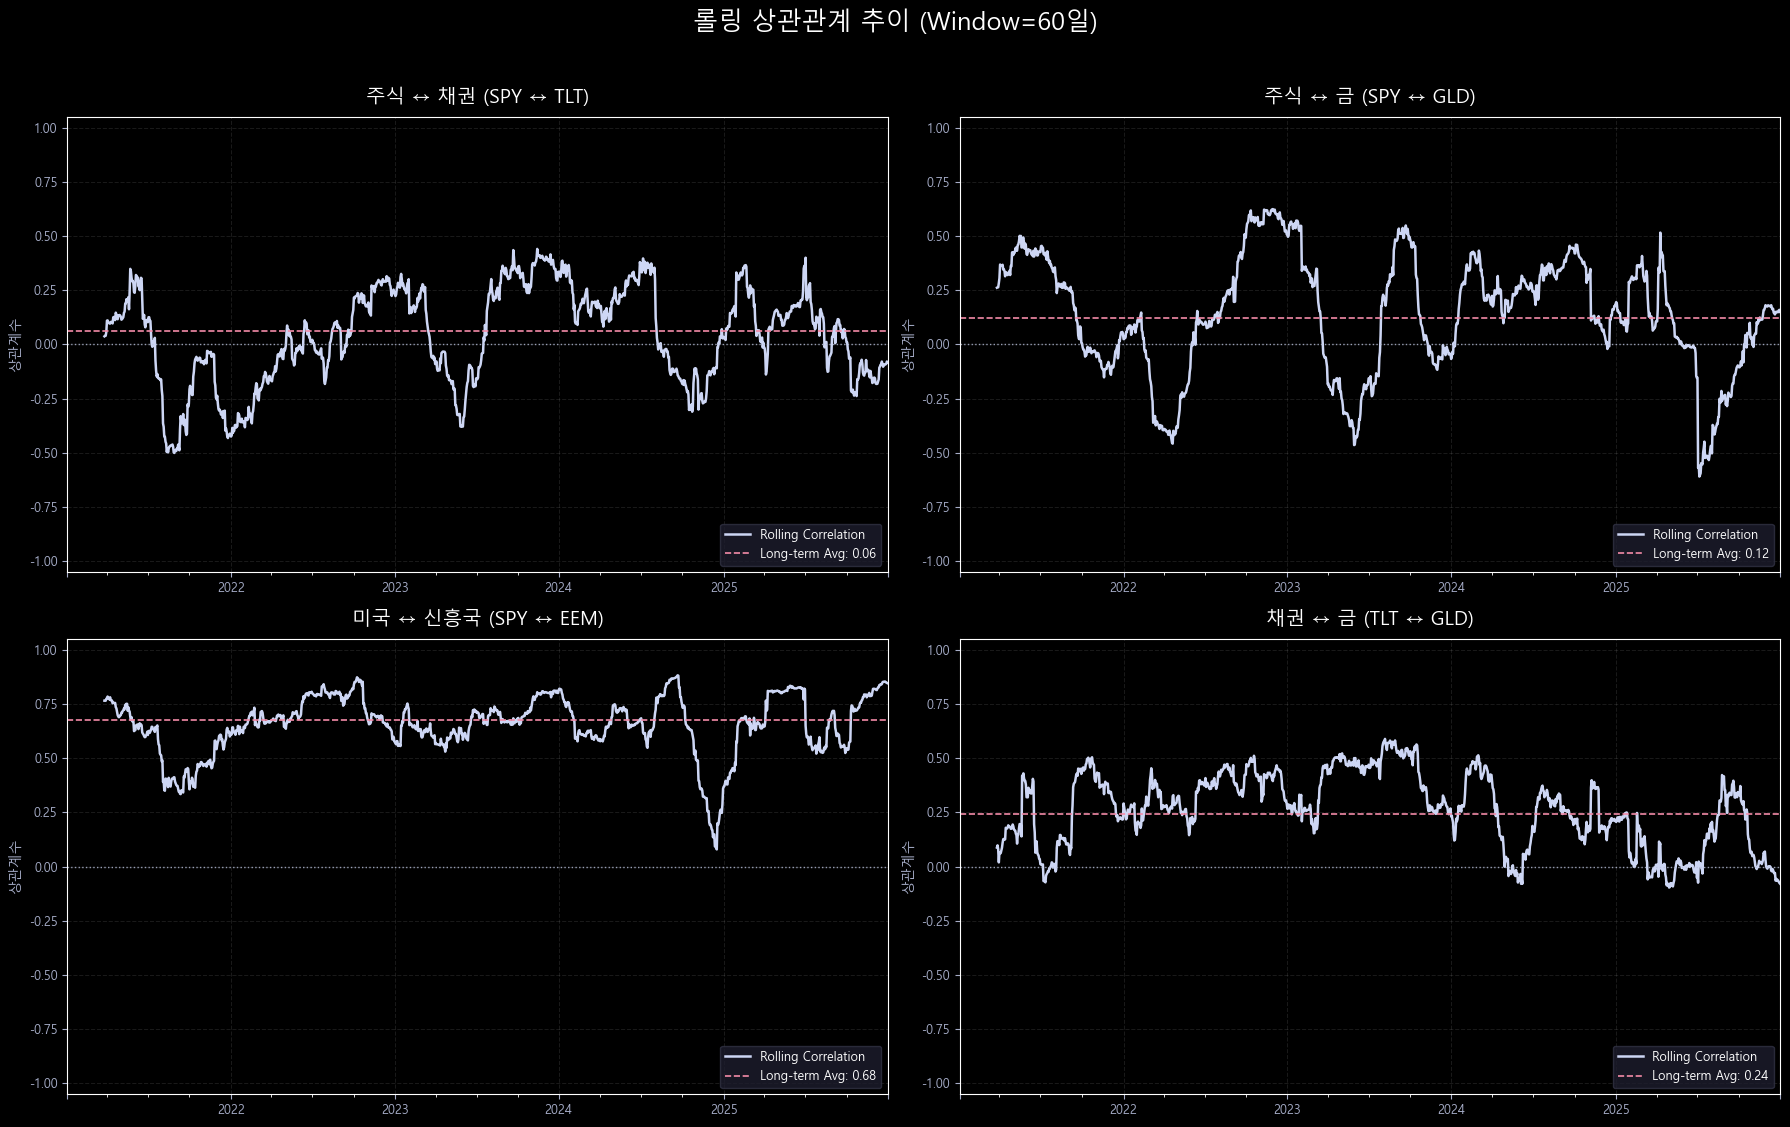

In [63]:
# ── 1-5A. 핵심 자산 쌍 롤링 상관 (개선 버전) ────────────

WINDOW = 60  # 60영업일 ≈ 약 3개월

# 분석할 핵심 자원 쌍
pairs = [
    ("SPY", "TLT",      "주식 ↔ 채권"),
    ("SPY", "GLD",      "주식 ↔ 금"),
    ("SPY", "EEM",      "미국 ↔ 신흥국"),
    ("TLT", "GLD",      "채권 ↔ 금"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle(f"롤링 상관관계 추이 (Window={WINDOW}일)", fontsize=18, color="white", y=1.02)

for idx, (t1, t2, label) in enumerate(pairs):
    ax = axes[idx // 2, idx % 2]
    
    # 롤링 상관계수 계산
    rolling_corr = df_port_ret[t1].rolling(WINDOW).corr(df_port_ret[t2])
    
    # 1. 배경 영역 채우기 (직관적 해석 도움)
    # 양(+): 붉은색 계열, 음(-): 푸른색 계열로 아주 연하게 채움
    ax.fill_between(rolling_corr.index, 0, rolling_corr, 
                    where=(rolling_corr >= 0), color="#f38ba8", alpha=0.15)
    ax.fill_between(rolling_corr.index, 0, rolling_corr, 
                    where=(rolling_corr < 0), color="#89b4fa", alpha=0.15)

    # 2. 메인 상관계수 선
    rolling_corr.plot(ax=ax, color="#cdd6f4", linewidth=1.8, label="Rolling Correlation")

    # 3. 전체 기간 평균 상관 (빨간색 점선)
    avg_corr = df_port_ret[t1].corr(df_port_ret[t2])
    ax.axhline(y=avg_corr, color="#f38ba8", linestyle="--", 
               linewidth=1.2, label=f"Long-term Avg: {avg_corr:.2f}")

    # 4. 0점 기준선 (검은 배경에서 잘 보이도록 밝은 회색/흰색 처리)
    ax.axhline(y=0, color="#bac2de", linestyle=":", linewidth=1.0, alpha=0.8)

    # 차트 꾸미기
    ax.set_title(f"{label} ({t1} ↔ {t2})", fontsize=14, color="white", pad=10)
    ax.set_ylabel("상관계수", color="#a6adc8")
    ax.set_ylim(-1.05, 1.05) # 여유 공간 확보
    
    # 테두리 및 눈금 색상 조정
    ax.tick_params(colors="#a6adc8", labelsize=9)
    ax.grid(True, linestyle="--", alpha=0.1) # 아주 연한 그리드 추가
    
    # 레전드 위치 조정
    ax.legend(fontsize=9, loc='lower right', facecolor="#1e1e2e", edgecolor="#313244")

plt.tight_layout()
plt.show()

# [개선 포인트]
# 💡 배경 채우기: 상관관계가 양(+)으로 반전되는 구간(헤지 실패 등)을 즉각 포착 가능
# 💡 선명한 색상: 검은 배경에 대비되는 #cdd6f4(연회색)와 #bac2de(밝은 회색) 사용
# 💡 해석: SPY-TLT가 0 위로 높게 솟구칠 때는 자산 배분 포트폴리오의 변동성이 커지는 위험 구간임


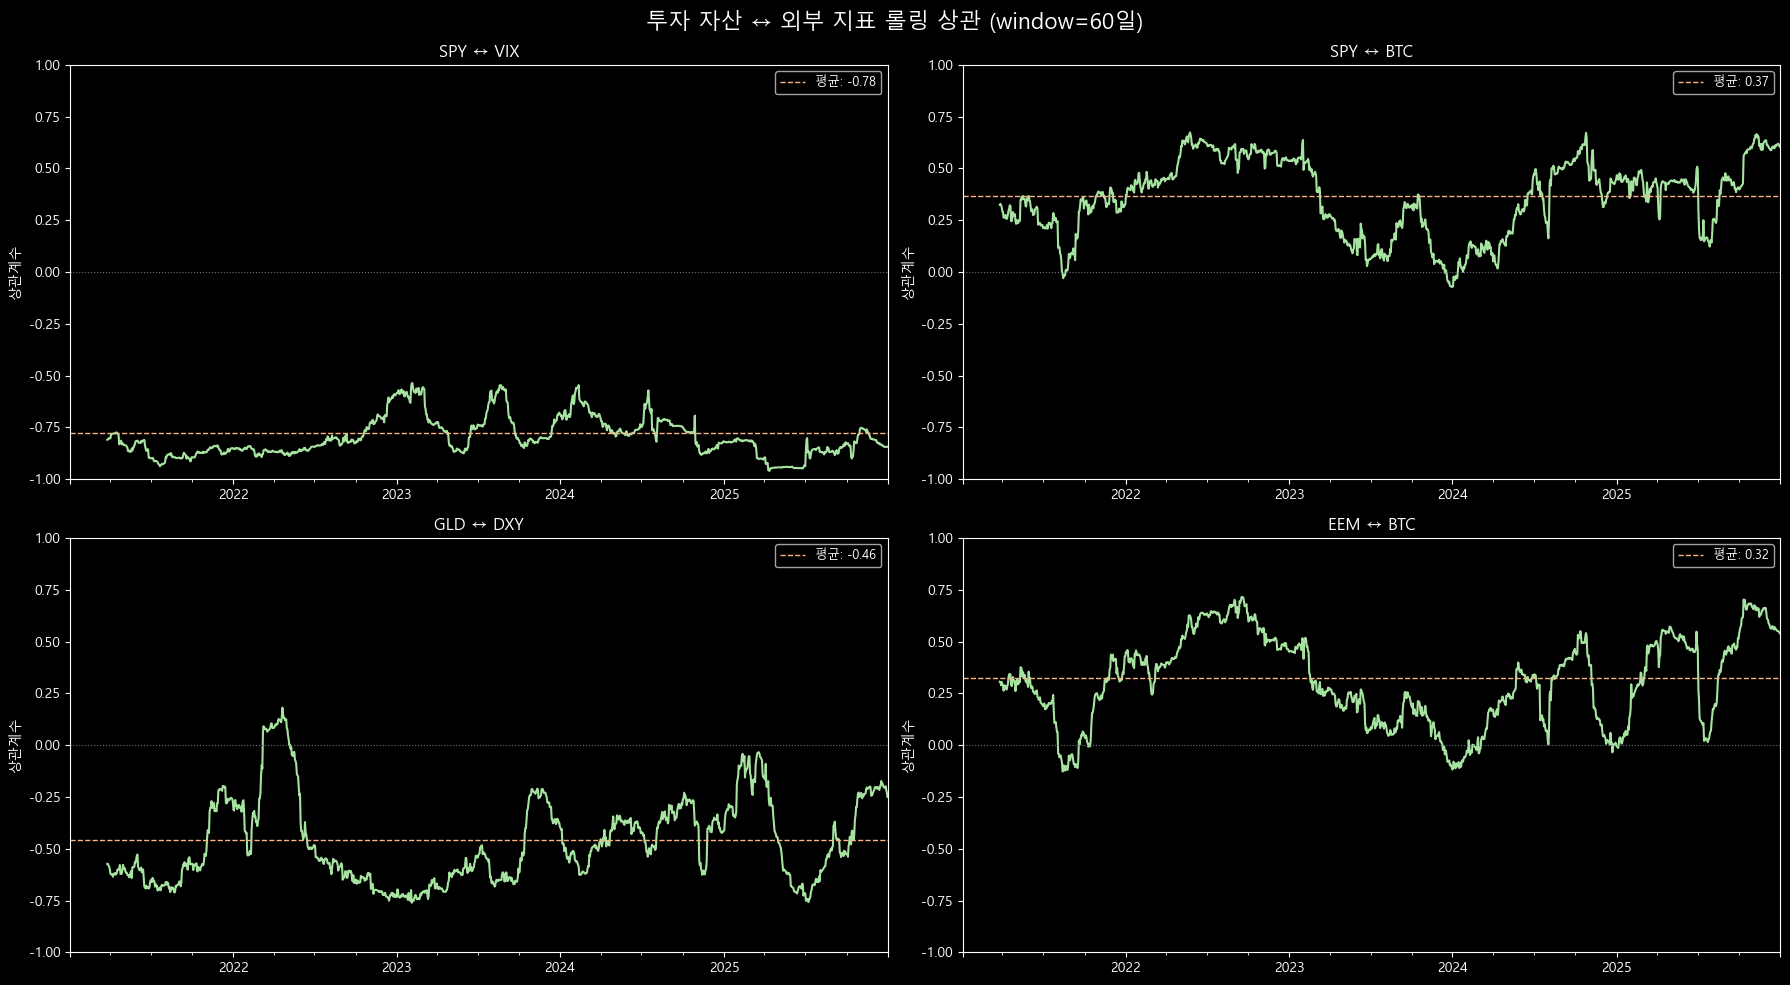

In [64]:
# ── 1-5B. 투자 자산 ↔ 외부 지표 롤링 상관 ────────────

# 핵심 외부 지표와 SPY의 롤링 상관
ext_pairs = [
    ("SPY", "^VIX",     "SPY ↔ VIX"),
    ("TLT", "DGS10",    "TLT ↔ 10Y금리")  if "DGS10" in df_all_ret.columns
        else ("SPY", "BTC-USD", "SPY ↔ BTC"),
    ("GLD", "DX-Y.NYB", "GLD ↔ DXY"),
    ("EEM", "BTC-USD",  "EEM ↔ BTC"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle(f"투자 자산 ↔ 외부 지표 롤링 상관 (window={WINDOW}일)",
             fontsize=16, color="white")

for idx, (t1, t2, label) in enumerate(ext_pairs):
    ax = axes[idx // 2, idx % 2]
    if t1 in df_all_ret.columns and t2 in df_all_ret.columns:
        rolling_corr = df_all_ret[t1].rolling(WINDOW).corr(df_all_ret[t2])
        rolling_corr.plot(ax=ax, color="#a6e3a1", linewidth=1.5)

        avg = df_all_ret[t1].corr(df_all_ret[t2])
        ax.axhline(y=avg, color="#fab387", linestyle="--",
                   linewidth=1, label=f"평균: {avg:.2f}")

    ax.axhline(y=0, color="#6c7086", linestyle=":", linewidth=0.8)
    ax.set_title(label, fontsize=12)
    ax.set_ylabel("상관계수")
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 핵심 관찰:
#   SPY ↔ VIX: 항상 강한 음의 상관 — 안정적 리스크 선행 지표
#   TLT ↔ 금리: 금리 급등기(2022)에 상관 강도 변화 관찰
#   GLD ↔ DXY: 달러 강세/약세 국면에 따라 상관 변동
#   EEM ↔ BTC: 위험자산 간 동조화 여부 — 위기 시 동반 하락 가능성

In [65]:
# ── 1-5C. 롤링 상관 요약 통계 (개선 버전) ────────────
all_pairs = pairs + [(t1, t2, label) for t1, t2, label in ext_pairs]
# (상단 로직은 동일)
summary_rows = []
for t1, t2, label in all_pairs:
    if t1 in df_all_ret.columns and t2 in df_all_ret.columns:
        rc = df_all_ret[t1].rolling(WINDOW).corr(df_all_ret[t2]).dropna()
        summary_rows.append({
            "쌍": label,
            "평균": rc.mean(),
            "표준편차": rc.std(),
            "최솟값": rc.min(),
            "최댓값": rc.max(),
            "범위": rc.max() - rc.min(),
        })

df_rolling_summary = pd.DataFrame(summary_rows).round(3)

# ── 수정된 출력 부분 ──────────────────────────────────
print("📊 롤링 상관 요약 (60일 윈도우)")
print("-" * 60)

# 1. display() 함수를 사용하면 주피터의 이쁜 표 형식이 나옵니다.
# 평균값이 높은 순서대로 색상 그라데이션을 넣는 예시
display(df_rolling_summary.style.background_gradient(cmap='RdBu_r', subset=['평균']))


# 또는 셀의 마지막 줄에 변수명만 적어도 됩니다.
# df_rolling_summary

print("\n💡 범위(range)가 클수록 시장 국면에 따라 상관이 크게 변한다는 의미.")


📊 롤링 상관 요약 (60일 윈도우)
------------------------------------------------------------


,쌍,평균,표준편차,최솟값,최댓값,범위
0,주식 ↔ 채권,0.044000,0.221000,-0.501000,0.441000,0.941000
1,주식 ↔ 금,0.138000,0.272000,-0.610000,0.624000,1.234000
2,미국 ↔ 신흥국,0.657000,0.136000,0.080000,0.883000,0.803000
3,채권 ↔ 금,0.266000,0.170000,-0.096000,0.589000,0.686000
4,SPY ↔ VIX,-0.798000,0.094000,-0.960000,-0.536000,0.424000
5,SPY ↔ BTC,0.359000,0.182000,-0.073000,0.674000,0.746000
6,GLD ↔ DXY,-0.466000,0.208000,-0.761000,0.181000,0.942000
7,EEM ↔ BTC,0.311000,0.213000,-0.127000,0.716000,0.843000



💡 범위(range)가 클수록 시장 국면에 따라 상관이 크게 변한다는 의미.


In [66]:
print("-투자, 자산 일별 로그 수익률-")
display(df_port_ret)
print("외부 지표 일별 로그 수익률(VIX는 차분)")
display(df_ext_ret)
print("위 둘을 통합한 전체 수익률")
display(df_all_ret)
print("왜도/첨도/연율 수익률/변동성 요약")
display(stats_summary)

-투자, 자산 일별 로그 수익률-


,SPY,QQQ,TLT,AGG,GLD,EEM
2021-01-04,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2021-01-05,0.0069,0.0082,-0.0075,-0.0010,0.0030,0.0238
2021-01-06,0.0060,-0.0139,-0.0207,-0.0049,-0.0164,-0.0085
2021-01-07,0.0147,0.0239,-0.0089,-0.0010,-0.0023,0.0094
2021-01-08,0.0057,0.0128,-0.0032,-0.0012,-0.0348,0.0261
...,...,...,...,...,...,...
2025-12-25,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2025-12-26,-0.0001,-0.0001,-0.0033,0.0002,0.0116,0.0070
2025-12-29,-0.0036,-0.0049,0.0038,0.0012,-0.0445,-0.0026
2025-12-30,-0.0012,-0.0023,-0.0024,-0.0004,0.0007,0.0040


외부 지표 일별 로그 수익률(VIX는 차분)


,CL=F,GC=F,SI=F,BTC-USD,ETH-USD,^VIX,DX-Y.NYB
2021-01-04,0.0000,0.0000,0.0000,0.0847,0.3537,0.0000,0.0000
2021-01-05,0.0474,0.0041,0.0105,0.0613,0.0559,-1.6300,-0.0049
2021-01-06,0.0139,-0.0237,-0.0219,0.0800,0.0929,-0.2700,0.0010
2021-01-07,0.0039,0.0028,0.0084,0.0669,0.0153,-2.7000,0.0033
2021-01-08,0.0274,-0.0418,-0.1012,0.0356,-0.0012,-0.8100,0.0030
...,...,...,...,...,...,...,...
2025-12-25,0.0000,0.0000,0.0000,-0.0043,-0.0144,0.0000,0.0000
2025-12-26,-0.0280,0.0108,0.0740,0.0008,0.0076,0.1300,0.0004
2025-12-29,0.0233,-0.0461,-0.0907,-0.0019,0.0030,0.6000,0.0002
2025-12-30,-0.0022,0.0104,0.1022,0.0147,0.0125,0.1300,0.0020


위 둘을 통합한 전체 수익률


,SPY,QQQ,TLT,AGG,GLD,EEM,CL=F,GC=F,SI=F,BTC-USD,ETH-USD,^VIX,DX-Y.NYB
2021-01-04,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0847,0.3537,0.0000,0.0000
2021-01-05,0.0069,0.0082,-0.0075,-0.0010,0.0030,0.0238,0.0474,0.0041,0.0105,0.0613,0.0559,-1.6300,-0.0049
2021-01-06,0.0060,-0.0139,-0.0207,-0.0049,-0.0164,-0.0085,0.0139,-0.0237,-0.0219,0.0800,0.0929,-0.2700,0.0010
2021-01-07,0.0147,0.0239,-0.0089,-0.0010,-0.0023,0.0094,0.0039,0.0028,0.0084,0.0669,0.0153,-2.7000,0.0033
2021-01-08,0.0057,0.0128,-0.0032,-0.0012,-0.0348,0.0261,0.0274,-0.0418,-0.1012,0.0356,-0.0012,-0.8100,0.0030
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0043,-0.0144,0.0000,0.0000
2025-12-26,-0.0001,-0.0001,-0.0033,0.0002,0.0116,0.0070,-0.0280,0.0108,0.0740,0.0008,0.0076,0.1300,0.0004
2025-12-29,-0.0036,-0.0049,0.0038,0.0012,-0.0445,-0.0026,0.0233,-0.0461,-0.0907,-0.0019,0.0030,0.6000,0.0002
2025-12-30,-0.0012,-0.0023,-0.0024,-0.0004,0.0007,0.0040,-0.0022,0.0104,0.1022,0.0147,0.0125,0.1300,0.0020


왜도/첨도/연율 수익률/변동성 요약


,평균(일),표준편차(일),왜도,초과첨도,연율수익률,연율변동성
SPY,0.0005,0.0106,0.1330,8.5346,0.1336,0.1676
QQQ,0.0006,0.0140,0.0340,4.7800,0.1401,0.2222
TLT,-0.0003,0.0099,0.0235,0.5693,-0.0827,0.1576
AGG,-0.0000,0.0037,0.0614,1.7536,-0.0031,0.0595
GLD,0.0006,0.0097,-0.3634,2.9430,0.1514,0.1533
EEM,0.0001,0.0113,0.2135,3.5609,0.0330,0.1790


# 투자자 성향 프로파일링

In [67]:
# ── 2-1. 투자 성향 분류 체계 정의 ────────────────────

PROFILES = {
    "보수형": {
        "label_en": "Conservative",
        "emoji": "🛡️",
        "gamma": 8,          # 위험 회피 계수
        "description": "원금 보전 최우선, 은퇴 자금 운용",
    },
    "중립형": {
        "label_en": "Moderate",
        "emoji": "⚖️",
        "gamma": 4,
        "description": "안정·성장 균형, 중장기 자산 형성",
    },
    "적극형": {
        "label_en": "Aggressive",
        "emoji": "📈",
        "gamma": 2,
        "description": "성장 추구, 단기 손실 감내 가능",
    },
    "공격형": {
        "label_en": "Very Aggressive",
        "emoji": "🔥",
        "gamma": 1,
        "description": "최대 수익 추구, 높은 변동 수용",
    },
}

print("📊 투자 성향 분류 체계:")
for name, p in PROFILES.items():
    print(f"  {p['emoji']} {name} (γ={p['gamma']}) — {p['description']}")

# gamma (γ): Mean-Variance 효용 함수의 위험 회피 계수
#   U = μ_p - (γ/2) * σ_p²
#   γ가 클수록 동일 변동성에서 효용이 더 많이 감소 → 보수적 포트폴리오 선호
#   γ=1: 변동성 1%당 효용 0.5% 감소
#   γ=8: 변동성 1%당 효용 4% 감소 — 훨씬 강한 위험 회피

📊 투자 성향 분류 체계:
  🛡️ 보수형 (γ=8) — 원금 보전 최우선, 은퇴 자금 운용
  ⚖️ 중립형 (γ=4) — 안정·성장 균형, 중장기 자산 형성
  📈 적극형 (γ=2) — 성장 추구, 단기 손실 감내 가능
  🔥 공격형 (γ=1) — 최대 수익 추구, 높은 변동 수용


In [68]:
# ── 2-2A. 성향별 리스크 파라미터 설정 ────────────────

# 자산군 분류
EQUITY_TICKERS = ["SPY", "QQQ", "EEM"]   # 주식군
BOND_TICKERS   = ["TLT", "AGG"]          # 채권군
GOLD_TICKERS   = ["GLD"]                 # 귀금속

for name, p in PROFILES.items():
    if name == "보수형":
        p.update({
            "target_vol": 0.07,      # 연율 목표 변동성 7%
            "max_mdd": -0.10,        # 최대 허용 MDD -10%
            "max_equity": 0.30,      # 주식군 최대 30%
            "min_bond": 0.40,        # 채권군 최소 40%
            "max_single": 0.25,      # 단일 자산 최대 25%
            "min_single": 0.05,      # 단일 자산 최소 5%
        })
    elif name == "중립형":
        p.update({
            "target_vol": 0.10,
            "max_mdd": -0.18,
            "max_equity": 0.55,
            "min_bond": 0.20,
            "max_single": 0.30,
            "min_single": 0.05,
        })
    elif name == "적극형":
        p.update({
            "target_vol": 0.15,
            "max_mdd": -0.25,
            "max_equity": 0.75,
            "min_bond": 0.10,
            "max_single": 0.35,
            "min_single": 0.03,
        })
    elif name == "공격형":
        p.update({
            "target_vol": 0.22,
            "max_mdd": -0.35,
            "max_equity": 0.90,
            "min_bond": 0.00,
            "max_single": 0.40,
            "min_single": 0.00,
        })

# 파라미터 요약 출력
param_df = pd.DataFrame({
    name: {
        "γ (위험회피)": p["gamma"],
        "목표 변동성": f"{p['target_vol']:.0%}",
        "최대 MDD": f"{p['max_mdd']:.0%}",
        "주식 상한": f"{p['max_equity']:.0%}",
        "채권 하한": f"{p['min_bond']:.0%}",
        "단일자산 상한": f"{p['max_single']:.0%}",
    }
    for name, p in PROFILES.items()
})

print("📊 성향별 리스크 허용 파라미터:")
display(param_df)

# target_vol: 연율 목표 변동성 — 최적화 시 변동성 상한으로 사용
# max_mdd: 최대 허용 낙폭 — 백테스팅에서 위반 시 전략 재검토
# max_equity: 주식군 합산 비중 상한 — 보수형은 30%, 공격형은 90%
# min_bond: 채권군 합산 비중 하한 — 보수형은 최소 40% 채권 보유
# max_single: 단일 자산 집중 방지 — 분산 효과 보장
# min_single: 최소 편입 비중 — 너무 작은 비중은 거래비용 대비 비효율

📊 성향별 리스크 허용 파라미터:


,보수형,중립형,적극형,공격형
γ (위험회피),8,4,2,1
목표 변동성,7%,10%,15%,22%
최대 MDD,-10%,-18%,-25%,-35%
주식 상한,30%,55%,75%,90%
채권 하한,40%,20%,10%,0%
단일자산 상한,25%,30%,35%,40%


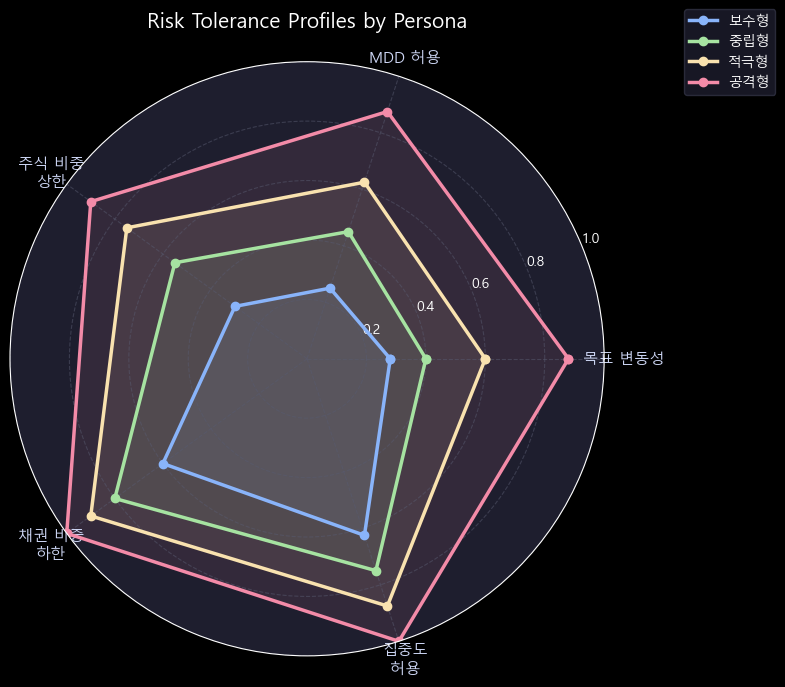

In [69]:
# ── 2-2B. 성향별 파라미터 레이더 차트 (경고 해결 버전) ──────

from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mticker

# 카테고리 설정 (한글 텍스트는 괜찮습니다)
categories = ["목표 변동성", "MDD 허용", "주식 비중\n상한", "채권 비중\n하한", "집중도\n허용"]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

colors = {"보수형": "#89b4fa", "중립형": "#a6e3a1",
          "적극형": "#f9e2af", "공격형": "#f38ba8"}

for name, p in PROFILES.items():
    values = [
        p["target_vol"] / 0.25,            # 정규화: 0~25% → 0~1
        abs(p["max_mdd"]) / 0.40,          # 정규화: 0~40% → 0~1
        p["max_equity"],                    # 이미 0~1
        1 - p["min_bond"],                  # 채권 하한 역전 (높을수록 공격적)
        p["max_single"] / 0.40,            # 정규화
    ]
    values += values[:1]

    # [수정] p['emoji']를 제거하고 이름(name)만 라벨로 사용합니다.
    ax.plot(angles, values, "o-", linewidth=2.5,
            label=f"{name}", color=colors[name])
    ax.fill(angles, values, alpha=0.1, color=colors[name])

# 차트 설정
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, color="#cdd6f4") # 텍스트 색상 추가
ax.set_ylim(0, 1)

# 배경 및 그리드 가독성 개선
ax.set_facecolor("#1e1e2e") # 차트 내부 배경색
ax.grid(color="#585b70", linestyle="--", alpha=0.5)

ax.set_title("Risk Tolerance Profiles by Persona", fontsize=15, color="white", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10, 
          facecolor="#1e1e2e", edgecolor="#313244", labelcolor="white")

plt.tight_layout()
plt.show()

# 레이더 차트: 각 축이 하나의 리스크 파라미터를 나타냄
# 면적이 넓을수록 공격적 성향 — 직관적 비교 가능
# 보수형: 작고 둥근 형태, 공격형: 크고 뾰족한 형태


In [70]:
# ── 2-3A. 제약조건 함수 구현 ─────────────────────────

def build_constraints(profile, cov_matrix, tickers):
    """
    성향별 제약조건을 scipy.optimize 형식으로 반환한다.

    Parameters
    ----------
    profile  : dict — PROFILES[성향명]
    cov_matrix : np.ndarray — 공분산 행렬
    tickers  : list — 자산 티커 목록

    Returns
    -------
    constraints : list[dict] — scipy.optimize.minimize 제약조건
    bounds      : list[tuple] — 각 자산의 (min, max) 비중
    """
    n = len(tickers)

    # 자산군 인덱스
    eq_idx   = [i for i, t in enumerate(tickers) if t in EQUITY_TICKERS]
    bond_idx = [i for i, t in enumerate(tickers) if t in BOND_TICKERS]

    constraints = []

    # (1) 비중 합 = 1
    constraints.append({
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1.0
    })

    # (3) 변동성 상한
    target_vol = profile["target_vol"]
    constraints.append({
        "type": "ineq",
        "fun": lambda w, tv=target_vol: tv - np.sqrt(w @ cov_matrix @ w)
    })

    # (4) 주식군 상한
    max_eq = profile["max_equity"]
    constraints.append({
        "type": "ineq",
        "fun": lambda w, idx=eq_idx, mx=max_eq: mx - sum(w[i] for i in idx)
    })

    # (5) 채권군 하한
    min_bond = profile["min_bond"]
    if min_bond > 0:
        constraints.append({
            "type": "ineq",
            "fun": lambda w, idx=bond_idx, mn=min_bond: sum(w[i] for i in idx) - mn
        })

    # (2)(6)(7) 비중 범위 — bounds로 처리
    w_min = profile["min_single"]
    w_max = profile["max_single"]
    bounds = [(w_min, w_max) for _ in range(n)]

    return constraints, bounds


# 테스트: 보수형 제약조건 생성
cov_annual = df_port_ret.cov() * 252  # 연율 공분산
test_constraints, test_bounds = build_constraints(
    PROFILES["보수형"], cov_annual.values, port_tickers
)
print(f"✅ 보수형 제약조건: {len(test_constraints)}개 + bounds {len(test_bounds)}개")
print(f"  bounds 범위: {test_bounds[0]}")

# build_constraints(): 성향 파라미터 → scipy 최적화 제약조건 변환
# "eq" 제약: 등식 (비중 합 = 1)
# "ineq" 제약: 부등식 (fun(w) ≥ 0 형태)
# bounds: 각 자산의 (min, max) — 공매도 금지 + 단일 자산 집중 방지
# cov_annual: 일별 공분산 × 252 = 연율 공분산 (시간 스케일링)

✅ 보수형 제약조건: 4개 + bounds 6개
  bounds 범위: (0.05, 0.25)


In [71]:
# ── 2-3B. 제약조건 유효성 검증 ───────────────────────

def validate_weights(weights, profile, cov_matrix, tickers):
    """비중 벡터가 제약조건을 만족하는지 검증한다."""
    n = len(tickers)
    eq_idx   = [i for i, t in enumerate(tickers) if t in EQUITY_TICKERS]
    bond_idx = [i for i, t in enumerate(tickers) if t in BOND_TICKERS]

    port_vol = np.sqrt(weights @ cov_matrix @ weights)
    equity_sum = sum(weights[i] for i in eq_idx)
    bond_sum   = sum(weights[i] for i in bond_idx)

    checks = {
        "비중 합 = 1":       abs(sum(weights) - 1.0) < 1e-6,
        "공매도 없음":        all(w >= -1e-6 for w in weights),
        f"변동성 ≤ {profile['target_vol']:.0%}":
                              port_vol <= profile["target_vol"] + 1e-6,
        f"주식 ≤ {profile['max_equity']:.0%}":
                              equity_sum <= profile["max_equity"] + 1e-6,
        f"채권 ≥ {profile['min_bond']:.0%}":
                              bond_sum >= profile["min_bond"] - 1e-6,
    }

    print(f"\n{'='*50}")
    print(f"📋 {profile['emoji']} 제약조건 검증:")
    for desc, passed in checks.items():
        status = "✅" if passed else "❌"
        print(f"  {status} {desc}")
    print(f"  포트폴리오 변동성: {port_vol:.2%}")
    print(f"  주식 비중: {equity_sum:.2%} | 채권 비중: {bond_sum:.2%}")

    return all(checks.values())


# 동일 비중으로 테스트
equal_weights = np.ones(len(port_tickers)) / len(port_tickers)

print("🔍 동일 비중(1/N) 포트폴리오 제약조건 검증:")
for name, p in PROFILES.items():
    validate_weights(equal_weights, p, cov_annual.values, port_tickers)

# validate_weights(): 최적화 결과를 Phase 3에서 검증할 때 재사용
# 동일 비중 테스트: 약 16.67%씩 — 보수형 제약(주식 30%, 채권 40%)은 위반 예상
# → Phase 3에서 최적화가 이 제약을 만족하도록 비중을 조정하는 과정을 확인

🔍 동일 비중(1/N) 포트폴리오 제약조건 검증:

📋 🛡️ 제약조건 검증:
  ✅ 비중 합 = 1
  ✅ 공매도 없음
  ❌ 변동성 ≤ 7%
  ❌ 주식 ≤ 30%
  ❌ 채권 ≥ 40%
  포트폴리오 변동성: 10.75%
  주식 비중: 50.00% | 채권 비중: 33.33%

📋 ⚖️ 제약조건 검증:
  ✅ 비중 합 = 1
  ✅ 공매도 없음
  ❌ 변동성 ≤ 10%
  ✅ 주식 ≤ 55%
  ✅ 채권 ≥ 20%
  포트폴리오 변동성: 10.75%
  주식 비중: 50.00% | 채권 비중: 33.33%

📋 📈 제약조건 검증:
  ✅ 비중 합 = 1
  ✅ 공매도 없음
  ✅ 변동성 ≤ 15%
  ✅ 주식 ≤ 75%
  ✅ 채권 ≥ 10%
  포트폴리오 변동성: 10.75%
  주식 비중: 50.00% | 채권 비중: 33.33%

📋 🔥 제약조건 검증:
  ✅ 비중 합 = 1
  ✅ 공매도 없음
  ✅ 변동성 ≤ 22%
  ✅ 주식 ≤ 90%
  ✅ 채권 ≥ 0%
  포트폴리오 변동성: 10.75%
  주식 비중: 50.00% | 채권 비중: 33.33%


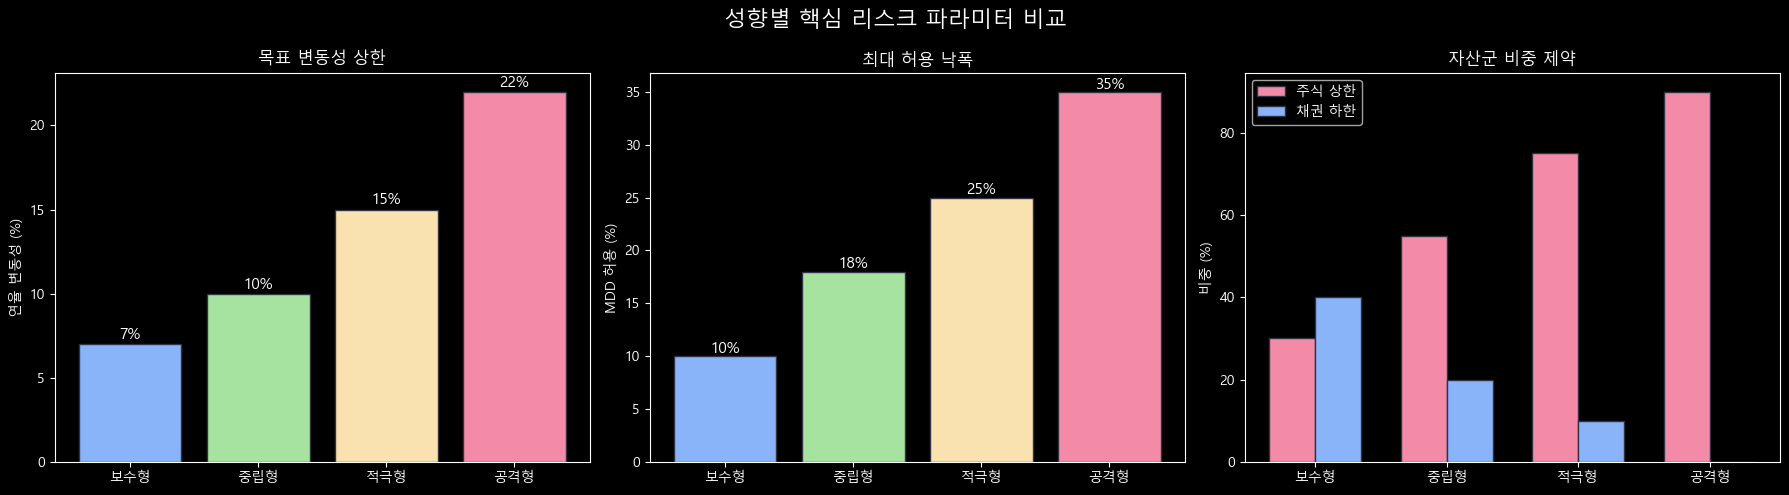

In [72]:
# ── 2-3C. 성향별 파라미터 비교 막대 차트 ─────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("성향별 핵심 리스크 파라미터 비교", fontsize=16, color="white")

profile_names = list(PROFILES.keys())
colors_bar = ["#89b4fa", "#a6e3a1", "#f9e2af", "#f38ba8"]

# (1) 목표 변동성
vals = [PROFILES[n]["target_vol"] * 100 for n in profile_names]
axes[0].bar(profile_names, vals, color=colors_bar, edgecolor="#313244")
axes[0].set_ylabel("연율 변동성 (%)")
axes[0].set_title("목표 변동성 상한")
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.3, f"{v:.0f}%", ha="center", fontsize=11, color="white")

# (2) 최대 MDD
vals = [abs(PROFILES[n]["max_mdd"]) * 100 for n in profile_names]
axes[1].bar(profile_names, vals, color=colors_bar, edgecolor="#313244")
axes[1].set_ylabel("MDD 허용 (%)")
axes[1].set_title("최대 허용 낙폭")
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.3, f"{v:.0f}%", ha="center", fontsize=11, color="white")

# (3) 주식 상한 vs 채권 하한
x = np.arange(len(profile_names))
width = 0.35
eq_vals = [PROFILES[n]["max_equity"] * 100 for n in profile_names]
bd_vals = [PROFILES[n]["min_bond"] * 100 for n in profile_names]

axes[2].bar(x - width/2, eq_vals, width, label="주식 상한",
            color="#f38ba8", edgecolor="#313244")
axes[2].bar(x + width/2, bd_vals, width, label="채권 하한",
            color="#89b4fa", edgecolor="#313244")
axes[2].set_xticks(x)
axes[2].set_xticklabels(profile_names)
axes[2].set_ylabel("비중 (%)")
axes[2].set_title("자산군 비중 제약")
axes[2].legend()

plt.tight_layout()
plt.show()

# 시각화 해석:
#   보수형 → 공격형으로 갈수록:
#     목표 변동성: 7% → 22% (3배 이상 확대)
#     MDD 허용: 10% → 35% (낙폭 감내 증가)
#     주식 상한: 30% → 90% (성장 노출 확대)
#     채권 하한: 40% → 0% (안전장치 제거)

In [133]:
# ── 3-1. 기대 수익률 · 공분산 행렬 추정 ──────────────

from sklearn.covariance import LedoitWolf

# 기대 수익률: 표본 평균 (연율화)
mu_annual = df_port_ret.mean() * 252

# 공분산 행렬: Ledoit-Wolf Shrinkage (연율화)
lw = LedoitWolf().fit(df_port_ret)
cov_daily_lw = pd.DataFrame(
    lw.covariance_, index=port_tickers, columns=port_tickers
)
cov_annual_lw = cov_daily_lw * 252

# 표본 공분산 (비교용)
cov_annual_sample = df_port_ret.cov() * 252

# 축소 강도 확인
print(f"✅ Ledoit-Wolf Shrinkage 완료")
print(f"  축소 강도 (α): {lw.shrinkage_:.4f}")
print(f"  α=0이면 표본 공분산, α=1이면 완전 축소")
print(f"\n📊 연율 기대 수익률:")
display(mu_annual.round(4))
print(f"\n📊 연율 공분산 행렬 (Ledoit-Wolf):")
display(cov_annual_lw.round(6))

# LedoitWolf(): 최적 축소 강도 α를 데이터 기반으로 자동 결정
# 축소 대상 F: 대각 행렬 (자산 간 상관 0 가정) — 과적합 방지
# 연율화: 일별 × 252 (수익률), 일별 × 252 (공분산)
# α가 높을수록 표본 공분산에서 멀어짐 → 자산 수 대비 표본 부족 시 유리

✅ Ledoit-Wolf Shrinkage 완료
  축소 강도 (α): 0.0127
  α=0이면 표본 공분산, α=1이면 완전 축소

📊 연율 기대 수익률:


SPY    0.1336
QQQ    0.1401
TLT   -0.0827
AGG   -0.0031
GLD    0.1514
EEM    0.0330
dtype: float64


📊 연율 공분산 행렬 (Ledoit-Wolf):


,SPY,QQQ,TLT,AGG,GLD,EEM
SPY,0.0280,0.0348,0.0016,0.0019,0.0031,0.0201
QQQ,0.0348,0.0490,0.0026,0.0026,0.0037,0.0265
TLT,0.0016,0.0026,0.0248,0.0084,0.0058,0.0017
AGG,0.0019,0.0026,0.0084,0.0038,0.0030,0.0019
GLD,0.0031,0.0037,0.0058,0.0030,0.0235,0.0078
EEM,0.0201,0.0265,0.0017,0.0019,0.0078,0.0319


In [74]:
# ── 3-2. 효율적 프론티어 도출 ────────────────────────

def max_return_for_vol(target_vol, mu, cov, n_assets):
    """주어진 변동성 상한에서 수익률을 최대화하는 비중 탐색."""
    def neg_return(w):
        return -(w @ mu)

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "ineq",
         "fun": lambda w, tv=target_vol: tv - np.sqrt(w @ cov @ w)},
    ]
    bounds = [(0, 1)] * n_assets
    w0 = np.ones(n_assets) / n_assets

    result = minimize(
        neg_return, w0, method="SLSQP",
        bounds=bounds, constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-12}
    )
    return result


# 변동성 목표 범위 설정
n = len(port_tickers)
mu_arr = mu_annual.values
cov_arr = cov_annual_lw.values

vol_targets = np.linspace(0.03, 0.28, 80)
frontier_results = []

for tv in vol_targets:
    res = max_return_for_vol(tv, mu_arr, cov_arr, n)
    if res.success:
        w = res.x
        ret = w @ mu_arr
        vol = np.sqrt(w @ cov_arr @ w)
        frontier_results.append({"vol": vol, "ret": ret, "weights": w})

df_frontier = pd.DataFrame(frontier_results)

print(f"✅ 효율적 프론티어: {len(df_frontier)}개 포인트")
print(f"  변동성 범위: {df_frontier['vol'].min():.2%} ~ {df_frontier['vol'].max():.2%}")
print(f"  수익률 범위: {df_frontier['ret'].min():.2%} ~ {df_frontier['ret'].max():.2%}")

# minimize(method="SLSQP"): Sequential Least Squares Programming
#   비선형 제약 최적화에 적합한 알고리즘
# neg_return: scipy는 최소화만 지원 → 수익률에 음수를 씌워 최대화
# ftol=1e-12: 수렴 허용 오차 — 작을수록 정밀한 해

✅ 효율적 프론티어: 70개 포인트
  변동성 범위: 6.16% ~ 15.34%
  수익률 범위: 2.50% ~ 15.14%


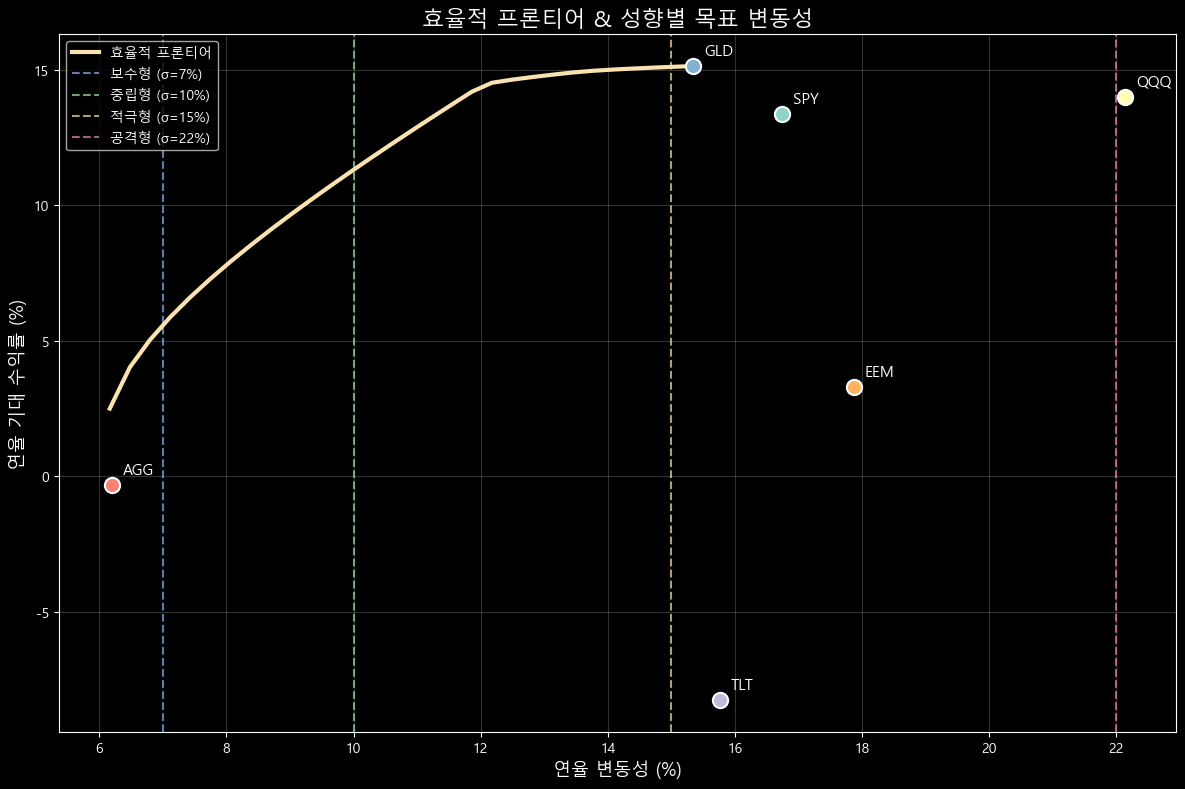

In [75]:
# ── 3-2 시각화. 효율적 프론티어 ──────────────────────

fig, ax = plt.subplots(figsize=(12, 8))

# 효율적 프론티어
ax.plot(df_frontier["vol"] * 100, df_frontier["ret"] * 100,
        color="#f9e2af", linewidth=3, label="효율적 프론티어", zorder=3)

# 개별 자산 산점도
for ticker in port_tickers:
    ret_i = mu_annual[ticker] * 100
    vol_i = np.sqrt(cov_annual_lw.loc[ticker, ticker]) * 100
    ax.scatter(vol_i, ret_i, s=120, zorder=5, edgecolors="white", linewidth=1.5)
    ax.annotate(ticker, (vol_i, ret_i), textcoords="offset points",
                xytext=(8, 8), fontsize=11, color="white")

# 성향별 목표 변동성 수직선
profile_colors = {"보수형": "#89b4fa", "중립형": "#a6e3a1",
                  "적극형": "#f9e2af", "공격형": "#f38ba8"}
for name, p in PROFILES.items():
    ax.axvline(x=p["target_vol"] * 100, color=profile_colors[name],
               linestyle="--", linewidth=1.5, alpha=0.7,
               label=f"{name} (σ={p['target_vol']:.0%})")

ax.set_xlabel("연율 변동성 (%)", fontsize=13)
ax.set_ylabel("연율 기대 수익률 (%)", fontsize=13)
ax.set_title("효율적 프론티어 & 성향별 목표 변동성", fontsize=16, color="white")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 효율적 프론티어 위의 점: 해당 변동성에서 최대 수익률 달성
# 프론티어 아래: 비효율 (동일 변동성에서 더 높은 수익 가능)
# 성향별 수직선: 해당 변동성에서 프론티어와 만나는 점이 최적 포트폴리오

In [76]:
# ── 3-3. 성향별 최적 비중 산출 ───────────────────────

def optimize_portfolio(profile, mu, cov, tickers):
    """성향별 효용 함수를 최대화하는 최적 비중을 탐색한다."""
    gamma = profile["gamma"]
    n = len(tickers)

    # 효용 함수 (최소화 → 음수 부호)
    def neg_utility(w):
        ret = w @ mu
        vol2 = w @ cov @ w
        return -(ret - (gamma / 2) * vol2)

    constraints, bounds = build_constraints(profile, cov, tickers)
    w0 = np.ones(n) / n

    result = minimize(
        neg_utility, w0, method="SLSQP",
        bounds=bounds, constraints=constraints,
        options={"maxiter": 2000, "ftol": 1e-12}
    )

    if result.success:
        w = result.x
        w = np.maximum(w, 0)          # 부동소수점 음수 보정
        w = w / w.sum()                # 비중 합 정규화
        return w
    else:
        print(f"⚠️ {profile['emoji']} 최적화 실패: {result.message}")
        return np.ones(n) / n


# 전 성향 최적화 실행
optimal_weights = {}
for name, p in PROFILES.items():
    w = optimize_portfolio(p, mu_arr, cov_arr, port_tickers)
    optimal_weights[name] = w

    # 성과 지표
    ret = w @ mu_arr
    vol = np.sqrt(w @ cov_arr @ w)
    sharpe = ret / vol

    print(f"\n{p['emoji']} {name} (γ={p['gamma']}):")
    for i, ticker in enumerate(port_tickers):
        bar = "█" * int(w[i] * 40)
        print(f"  {ticker:5s} {w[i]:6.1%}  {bar}")
    print(f"  ──────────────────")
    print(f"  기대 수익률: {ret:.2%} | 변동성: {vol:.2%} | Sharpe: {sharpe:.2f}")

    # 제약조건 검증
    validate_weights(w, p, cov_arr, port_tickers)

# optimize_portfolio(): 효용 함수 최대화 + 성향별 제약조건 적용
# neg_utility: U = μ - (γ/2)σ² → 최소화를 위해 -U
# 비중 정규화: 부동소수점 오차로 합이 정확히 1이 아닐 수 있어 보정
# Sharpe Ratio: μ/σ — 위험 조정 수익률 (무위험 이자율 = 0 가정)

⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch

🛡️ 보수형 (γ=8):
  SPY    16.7%  ██████
  QQQ    16.7%  ██████
  TLT    16.7%  ██████
  AGG    16.7%  ██████
  GLD    16.7%  ██████
  EEM    16.7%  ██████
  ──────────────────
  기대 수익률: 6.21% | 변동성: 10.70% | Sharpe: 0.58

📋 🛡️ 제약조건 검증:
  ✅ 비중 합 = 1
  ✅ 공매도 없음
  ❌ 변동성 ≤ 7%
  ❌ 주식 ≤ 30%
  ❌ 채권 ≥ 40%
  포트폴리오 변동성: 10.70%
  주식 비중: 50.00% | 채권 비중: 33.33%

⚖️ 중립형 (γ=4):
  SPY    30.0%  ████████████
  QQQ     8.1%  ███
  TLT     5.0%  ██
  AGG    21.9%  ████████
  GLD    30.0%  ███████████
  EEM     5.0%  ██
  ──────────────────
  기대 수익률: 9.37% | 변동성: 10.00% | Sharpe: 0.94

📋 ⚖️ 제약조건 검증:
  ✅ 비중 합 = 1
  ✅ 공매도 없음
  ✅ 변동성 ≤ 10%
  ✅ 주식 ≤ 55%
  ✅ 채권 ≥ 20%
  포트폴리오 변동성: 10.00%
  주식 비중: 43.13% | 채권 비중: 26.87%

📈 적극형 (γ=2):
  SPY    35.0%  █████████████
  QQQ    17.0%  ██████
  TLT     3.0%  █
  AGG     7.0%  ██
  GLD    35.0%  ██████████████
  EEM     3.0%  █
  ──────────────────
  기대 수익률: 12.19% | 변동성: 12.06% | Sharpe: 1.01

📋 📈 제약조건 검증:
  ✅ 

| **전략** | **핵심 원리** | **장점** | **한계** |
| --- | --- | --- | --- |
| **Mean-Variance** | 효용 함수 최대화 | 이론적 최적, 수익률 고려 | 추정 오차에 민감, 극단 비중 가능 |
| **Min Variance** | 변동성 최소화 (수익률 무시) | 수익률 추정 불필요, 안정적 | 수익률 무시 → 보수적 편향 |
| **Risk Parity** | 리스크 기여도 균등 배분 | 분산 효과 극대화, 직관적 | 수익률 무시, 저변동 자산 과대 비중 |
| **HRP** | 계층적 클러스터링 + 역분산 | 공분산 역행렬 불필요, 강건 | 수익률 무시, 클러스터 해석 필요 |

In [77]:
# ── 3-4A. Minimum Variance ───────────────────────────

def min_variance_portfolio(cov, tickers):
    """변동성을 최소화하는 비중 탐색 (수익률 무시)."""
    n = len(tickers)

    def portfolio_vol(w):
        return np.sqrt(w @ cov @ w)

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n

    result = minimize(portfolio_vol, w0, method="SLSQP",
                      bounds=bounds, constraints=constraints)
    w = result.x
    w = np.maximum(w, 0)
    return w / w.sum()


w_minvar = min_variance_portfolio(cov_arr, port_tickers)
ret_mv = w_minvar @ mu_arr
vol_mv = np.sqrt(w_minvar @ cov_arr @ w_minvar)

print("📊 Minimum Variance 포트폴리오:")
for i, t in enumerate(port_tickers):
    print(f"  {t:5s} {w_minvar[i]:6.1%}")
print(f"  수익률: {ret_mv:.2%} | 변동성: {vol_mv:.2%} | Sharpe: {ret_mv/vol_mv:.2f}")

# Min Variance: 수익률 벡터 μ 불필요 — 공분산만으로 최적화
# 저변동 자산(AGG, TLT)에 비중 집중 경향
# 보수형 투자자에게 실질적으로 가장 강건한 전략일 수 있음

📊 Minimum Variance 포트폴리오:
  SPY     5.0%
  QQQ     0.0%
  TLT     0.0%
  AGG    90.0%
  GLD     2.8%
  EEM     2.2%
  수익률: 0.89% | 변동성: 6.06% | Sharpe: 0.15


In [78]:
# ── 3-4B. Risk Parity ───────────────────────────────

def risk_parity_portfolio(cov, tickers):
    """각 자산의 리스크 기여도가 동일하도록 비중 배분."""
    n = len(tickers)

    def risk_budget_obj(w):
        port_vol = np.sqrt(w @ cov @ w)
        # 한계 리스크 기여도 (Marginal Risk Contribution)
        mrc = cov @ w / port_vol
        # 리스크 기여도 (Risk Contribution)
        rc = w * mrc
        # 목표: 모든 RC가 동일 → 편차 최소화
        target_rc = port_vol / n
        return np.sum((rc - target_rc) ** 2)

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = [(0.01, 1)] * n
    w0 = np.ones(n) / n

    result = minimize(risk_budget_obj, w0, method="SLSQP",
                      bounds=bounds, constraints=constraints)
    w = result.x
    return w / w.sum()


w_rp = risk_parity_portfolio(cov_arr, port_tickers)
ret_rp = w_rp @ mu_arr
vol_rp = np.sqrt(w_rp @ cov_arr @ w_rp)

# 리스크 기여도 확인
port_vol_rp = np.sqrt(w_rp @ cov_arr @ w_rp)
mrc_rp = cov_arr @ w_rp / port_vol_rp
rc_rp = w_rp * mrc_rp

print("\n📊 Risk Parity 포트폴리오:")
for i, t in enumerate(port_tickers):
    print(f"  {t:5s} 비중={w_rp[i]:6.1%}  RC={rc_rp[i]:.4f} ({rc_rp[i]/port_vol_rp:.1%})")
print(f"  수익률: {ret_rp:.2%} | 변동성: {vol_rp:.2%} | Sharpe: {ret_rp/vol_rp:.2f}")

# Risk Parity 핵심:
#   RC_i = w_i × (Σw)_i / σ_p — 각 자산의 포트폴리오 변동성 기여도
#   목표: 모든 RC_i ≈ σ_p / n — 리스크 균등 배분
#   결과: 저변동 자산(AGG) 비중 ↑, 고변동 자산(QQQ) 비중 ↓


📊 Risk Parity 포트폴리오:
  SPY   비중= 12.4%  RC=0.0148 (16.8%)
  QQQ   비중=  9.3%  RC=0.0146 (16.5%)
  TLT   비중= 15.2%  RC=0.0143 (16.3%)
  AGG   비중= 33.9%  RC=0.0147 (16.6%)
  GLD   비중= 17.5%  RC=0.0152 (17.2%)
  EEM   비중= 11.7%  RC=0.0146 (16.6%)
  수익률: 4.62% | 변동성: 8.81% | Sharpe: 0.52


In [79]:
# ── 3-4C. HRP (Hierarchical Risk Parity) ────────────

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

def hrp_portfolio(returns):
    """계층적 클러스터링 기반 리스크 패리티 비중 산출."""
    cov = returns.cov() * 252
    corr = returns.corr()

    # 1. 상관 거리 행렬 → 계층 클러스터링
    dist = np.sqrt((1 - corr) / 2)
    link = linkage(squareform(dist.values), method="ward")
    sort_idx = leaves_list(link)

    # 2. 정렬된 공분산에서 재귀적 이등분 배분
    sorted_tickers = [returns.columns[i] for i in sort_idx]
    weights = pd.Series(1.0, index=sorted_tickers)

    def bisect(items):
        if len(items) <= 1:
            return
        mid = len(items) // 2
        left, right = items[:mid], items[mid:]

        # 각 클러스터의 역분산 비중
        var_left  = cov.loc[left, left].values
        var_right = cov.loc[right, right].values

        # 클러스터 내 역분산 포트폴리오의 분산
        inv_var_l = 1 / np.diag(var_left).sum()
        inv_var_r = 1 / np.diag(var_right).sum()
        alloc = inv_var_l / (inv_var_l + inv_var_r)

        weights[left]  *= alloc
        weights[right] *= (1 - alloc)

        bisect(left)
        bisect(right)

    bisect(sorted_tickers)
    return weights / weights.sum()


w_hrp_series = hrp_portfolio(df_port_ret)
w_hrp = np.array([w_hrp_series.get(t, 0) for t in port_tickers])
ret_hrp = w_hrp @ mu_arr
vol_hrp = np.sqrt(w_hrp @ cov_arr @ w_hrp)

print("\n📊 HRP 포트폴리오:")
for i, t in enumerate(port_tickers):
    print(f"  {t:5s} {w_hrp[i]:6.1%}")
print(f"  수익률: {ret_hrp:.2%} | 변동성: {vol_hrp:.2%} | Sharpe: {ret_hrp/vol_hrp:.2f}")

# HRP 3단계:
#   1. 상관 거리 → 클러스터링: 유사한 자산끼리 묶음
#   2. 클러스터 순서 정렬: 유사한 자산이 인접하도록
#   3. 재귀적 이등분: 각 분기에서 역분산 비율로 배분
# 장점: 공분산 역행렬 불필요 → 수치적으로 안정
# 결과: Risk Parity와 유사하지만 상관 구조를 반영한 차이 존재


📊 HRP 포트폴리오:
  SPY     6.0%
  QQQ     3.4%
  TLT     3.8%
  AGG    26.9%
  GLD    37.1%
  EEM    22.7%
  수익률: 7.25% | 변동성: 9.67% | Sharpe: 0.75


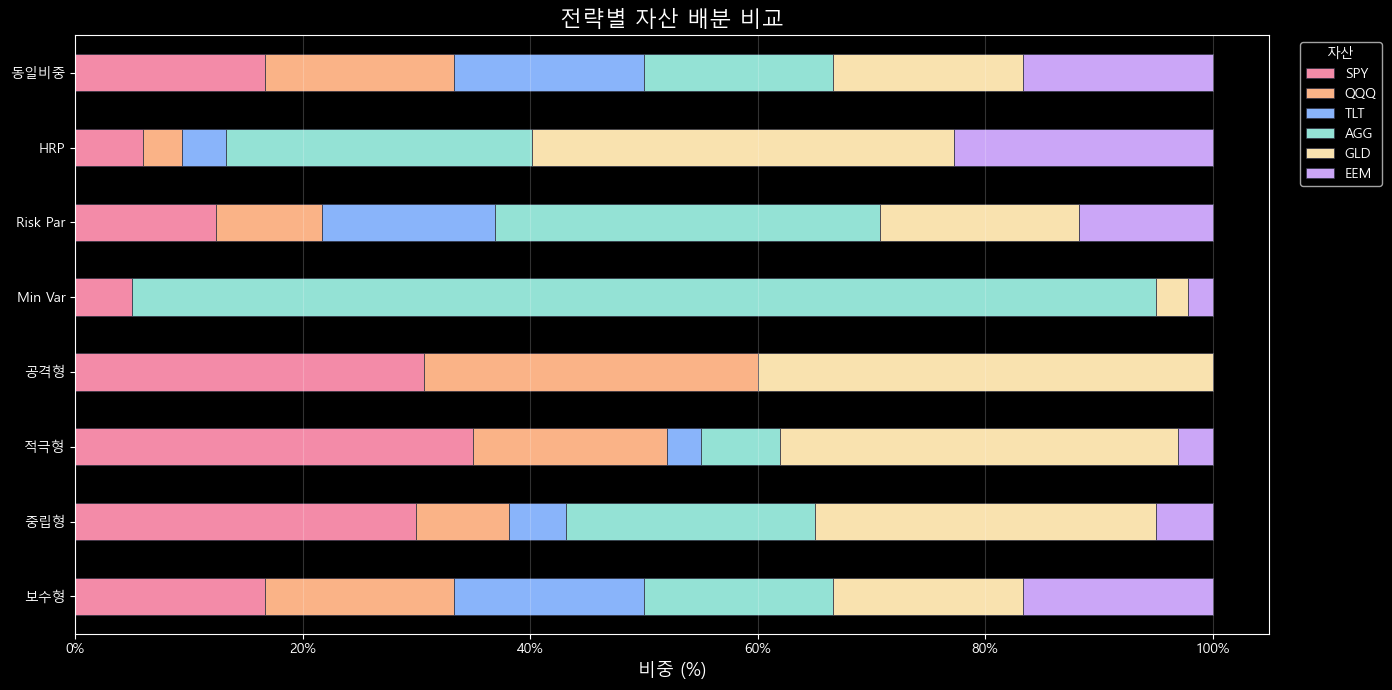

In [80]:
# ── 3-5A. 성향별 비중 스택 바 차트 ───────────────────

# 전략 통합
all_strategies = {}
for name in PROFILES:
    all_strategies[f"{name}"] = optimal_weights[name]
all_strategies["Min Var"]    = w_minvar
all_strategies["Risk Par"]   = w_rp
all_strategies["HRP"]        = w_hrp
all_strategies["동일비중"]    = np.ones(len(port_tickers)) / len(port_tickers)

df_weights = pd.DataFrame(all_strategies, index=port_tickers).T

# 스택 바 차트
fig, ax = plt.subplots(figsize=(14, 7))
asset_colors = ["#f38ba8", "#fab387", "#89b4fa", "#94e2d5", "#f9e2af", "#cba6f7"]

df_weights.plot(kind="barh", stacked=True, ax=ax, color=asset_colors,
                edgecolor="#313244", linewidth=0.5)

ax.set_xlabel("비중 (%)", fontsize=13)
ax.set_title("전략별 자산 배분 비교", fontsize=16, color="white")
ax.legend(title="자산", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# 관찰 포인트:
#   보수형: 채권(TLT+AGG) 과반 + GLD → 안정성 극대화
#   공격형: SPY+QQQ 대부분 → 성장 극대화, 채권 최소
#   Risk Parity: AGG 비중 최대 (저변동 자산 과대 배분)
#   HRP: Risk Parity와 유사하되 상관 클러스터링 효과로 미세 차이

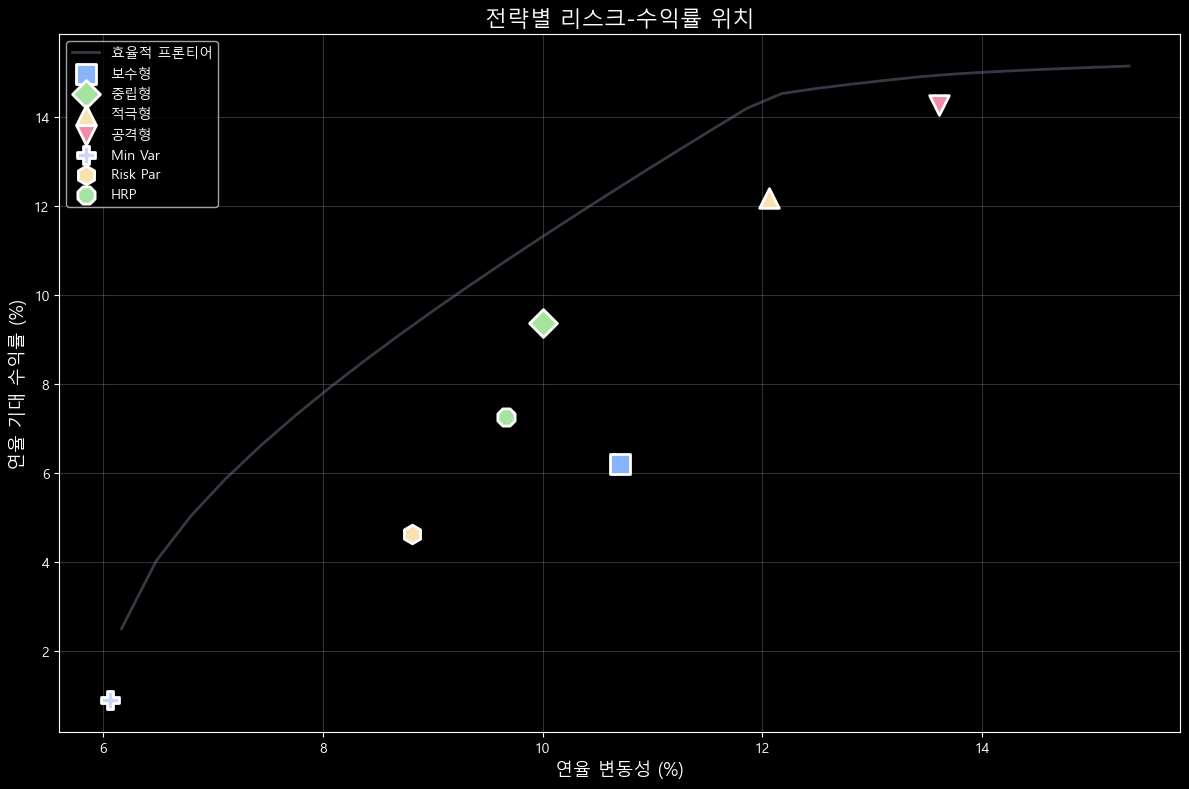

In [81]:
# ── 3-5B. 전략별 리스크-수익률 산점도 ────────────────

fig, ax = plt.subplots(figsize=(12, 8))

# 효율적 프론티어 배경
ax.plot(df_frontier["vol"] * 100, df_frontier["ret"] * 100,
        color="#6c7086", linewidth=2, alpha=0.5, label="효율적 프론티어")

# 전략별 산점도
markers = {"보수형": "s", "중립형": "D", "적극형": "^", "공격형": "v"}
for name, w in optimal_weights.items():
    ret = w @ mu_arr
    vol = np.sqrt(w @ cov_arr @ w)
    ax.scatter(vol*100, ret*100, s=200, marker=markers[name],
               color=profile_colors[name], edgecolors="white", linewidth=2,
               label=f"{name}", zorder=5)

# 대안 전략
alt_data = [
    (w_minvar, "Min Var", "#cdd6f4", "P"),
    (w_rp, "Risk Par", "#f9e2af", "h"),
    (w_hrp, "HRP", "#a6e3a1", "8"),
]
for w, label, color, marker in alt_data:
    ret = w @ mu_arr
    vol = np.sqrt(w @ cov_arr @ w)
    ax.scatter(vol*100, ret*100, s=180, marker=marker,
               color=color, edgecolors="white", linewidth=2,
               label=label, zorder=5)

ax.set_xlabel("연율 변동성 (%)", fontsize=13)
ax.set_ylabel("연율 기대 수익률 (%)", fontsize=13)
ax.set_title("전략별 리스크-수익률 위치", fontsize=16, color="white")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 프론티어 위에 가까울수록 효율적
# Min Var: 프론티어 최좌측 (최소 변동성)
# 공격형: 프론티어 우상단 (고위험·고수익)
# Risk Parity·HRP: 프론티어 근처 but 아래 — 수익률 미고려 비용

In [82]:
# ── 3-5C. 전략 성과 요약 테이블 (개선 버전) ────────────

summary_rows = []
for label, w in all_strategies.items():
    ret = w @ mu_arr
    vol = np.sqrt(w @ cov_arr @ w)
    sharpe = ret / vol if vol > 0 else 0
    
    # [수정] 문자열로 변환하지 말고 '숫자' 그대로 딕셔너리에 넣습니다.
    summary_rows.append({
        "전략": label,
        "기대수익률": ret,
        "변동성": vol,
        "Sharpe": sharpe,
        "주식비중": sum(w[i] for i,t in enumerate(port_tickers) if t in EQUITY_TICKERS),
        "채권비중": sum(w[i] for i,t in enumerate(port_tickers) if t in BOND_TICKERS),
    })

df_summary = pd.DataFrame(summary_rows)

print("📊 전략별 성과 요약:")
print("-" * 60)

# ── [수정] 판다스 스타일을 사용하여 깔끔하게 출력 ───────
# 1. 'display()'를 사용하여 표 형식으로 출력
# 2. 'format'을 통해 각 열별로 % 및 소수점 자릿수 지정
# 3. 'background_gradient'로 Sharpe 비율이 높은 것을 강조
styled_df = df_summary.style.format({
    "기대수익률": "{:.2%}",
    "변동성": "{:.2%}",
    "Sharpe": "{:.2f}",
    "주식비중": "{:.1%}",
    "채권비중": "{:.1%}"
}).background_gradient(cmap='RdYlGn', subset=['Sharpe']) # Sharpe 지수 강조

display(styled_df)

print("\n💡 Sharpe Ratio가 1.0 이상이면 위험 대비 수익이 우수한 전략입니다.")


📊 전략별 성과 요약:
------------------------------------------------------------


,전략,기대수익률,변동성,Sharpe,주식비중,채권비중
0,보수형,6.21%,10.70%,0.58,50.0%,33.3%
1,중립형,9.37%,10.00%,0.94,43.1%,26.9%
2,적극형,12.19%,12.06%,1.01,55.0%,10.0%
3,공격형,14.26%,13.61%,1.05,60.0%,0.0%
4,Min Var,0.89%,6.06%,0.15,7.2%,90.0%
5,Risk Par,4.62%,8.81%,0.52,33.4%,49.1%
6,HRP,7.25%,9.67%,0.75,32.2%,30.7%
7,동일비중,6.21%,10.70%,0.58,50.0%,33.3%



💡 Sharpe Ratio가 1.0 이상이면 위험 대비 수익이 우수한 전략입니다.


# 백테스팅

In [83]:
# ── 4-1. Walk-Forward 프레임워크 설계 ────────────────

IS_MONTHS  = 24     # In-Sample 학습 기간 (개월)
OOS_MONTHS = 3      # Out-of-Sample 검증 기간 (개월)

def generate_walk_forward_windows(dates, is_months, oos_months):
    """
    Walk-Forward 윈도우 생성.

    Parameters
    ----------
    dates      : pd.DatetimeIndex — 전체 거래일
    is_months  : int — In-Sample 기간 (개월)
    oos_months : int — Out-of-Sample 기간 (개월)

    Returns
    -------
    windows : list[dict] — 각 윈도우의 IS/OOS 시작·종료일
    """
    windows = []
    start = dates.min()
    end = dates.max()

    is_start = start
    while True:
        is_end   = is_start + pd.DateOffset(months=is_months) - pd.Timedelta(days=1)
        oos_start = is_end + pd.Timedelta(days=1)
        oos_end   = oos_start + pd.DateOffset(months=oos_months) - pd.Timedelta(days=1)

        if oos_end > end:
            break

        windows.append({
            "is_start": is_start, "is_end": is_end,
            "oos_start": oos_start, "oos_end": oos_end,
        })
        is_start = is_start + pd.DateOffset(months=oos_months)

    return windows


windows = generate_walk_forward_windows(
    df_port_ret.index, IS_MONTHS, OOS_MONTHS
)

print(f"✅ Walk-Forward 윈도우: {len(windows)}개")
for i, w in enumerate(windows[:3]):
    print(f"  [{i+1}] IS: {w['is_start'].date()} ~ {w['is_end'].date()}"
          f" → OOS: {w['oos_start'].date()} ~ {w['oos_end'].date()}")
print(f"  ...")
print(f"  [{len(windows)}] IS: {windows[-1]['is_start'].date()} ~ "
      f"{windows[-1]['is_end'].date()} → OOS: {windows[-1]['oos_start'].date()}"
      f" ~ {windows[-1]['oos_end'].date()}")

# Walk-Forward 핵심:
#   IS에서 최적화 → OOS에서 검증 → 슬라이딩 반복
#   IS 24개월: 최소 2년의 시장 사이클 포함
#   OOS 3개월: 분기별 리밸런싱 (실전적 빈도)
#   과적합 방지: OOS 데이터는 최적화에 절대 사용하지 않음

✅ Walk-Forward 윈도우: 11개
  [1] IS: 2021-01-04 ~ 2023-01-03 → OOS: 2023-01-04 ~ 2023-04-03
  [2] IS: 2021-04-04 ~ 2023-04-03 → OOS: 2023-04-04 ~ 2023-07-03
  [3] IS: 2021-07-04 ~ 2023-07-03 → OOS: 2023-07-04 ~ 2023-10-03
  ...
  [11] IS: 2023-07-04 ~ 2025-07-03 → OOS: 2025-07-04 ~ 2025-10-03


In [84]:
# ── 4-2. 거래 비용 & 백테스팅 엔진 ───────────────────

TRADING_COST_BPS = 10   # 편도 거래 비용 10bps (0.10%)
SLIPPAGE_BPS     = 5    # 슬리피지 5bps

def backtest_walk_forward(profile, returns, windows, tickers,
                          cost_bps=TRADING_COST_BPS,
                          slip_bps=SLIPPAGE_BPS):
    """
    Walk-Forward 백테스팅 실행.

    Parameters
    ----------
    profile  : dict — PROFILES[성향명] 또는 None (대안 전략용)
    returns  : pd.DataFrame — 일별 로그 수익률
    windows  : list[dict] — Walk-Forward 윈도우
    tickers  : list — 자산 티커
    cost_bps : float — 편도 거래 비용 (bps)
    slip_bps : float — 슬리피지 (bps)

    Returns
    -------
    result : dict — 일별 수익률 시계열, 비중 이력, 거래 비용 누적
    """
    total_cost = (cost_bps + slip_bps) / 10_000  # bps → 소수

    daily_returns = []
    weight_history = []
    cost_history = []
    prev_weights = None

    for w in windows:
        # IS 구간에서 재최적화
        is_ret = returns.loc[w["is_start"]:w["is_end"], tickers]
        mu_is = is_ret.mean().values * 252
        lw_is = LedoitWolf().fit(is_ret)
        cov_is = lw_is.covariance_ * 252

        if profile is not None:
            weights = optimize_portfolio(profile, mu_is, cov_is, tickers)
        else:
            # 대안 전략은 별도 함수 호출 (아래에서 분기)
            weights = np.ones(len(tickers)) / len(tickers)

        # 거래 비용 계산
        if prev_weights is not None:
            turnover = np.sum(np.abs(weights - prev_weights))
            rebal_cost = turnover * total_cost
        else:
            rebal_cost = np.sum(np.abs(weights)) * total_cost

        cost_history.append(rebal_cost)

        # OOS 구간에서 성과 측정
        oos_ret = returns.loc[w["oos_start"]:w["oos_end"], tickers]
        for date, row in oos_ret.iterrows():
            port_ret = np.sum(weights * row.values)
            daily_returns.append({"date": date, "return": port_ret})

        weight_history.append({
            "date": w["oos_start"],
            "weights": weights.copy(),
        })
        prev_weights = weights

    df_daily = pd.DataFrame(daily_returns).set_index("date")

    # 거래 비용 차감 (리밸런싱 시점에 분산 적용)
    total_cost_sum = sum(cost_history)
    cost_per_day = total_cost_sum / len(df_daily) if len(df_daily) > 0 else 0
    df_daily["return_net"] = df_daily["return"] - cost_per_day

    return {
        "daily_returns": df_daily,
        "weight_history": weight_history,
        "total_cost": total_cost_sum,
    }


# 성향별 백테스팅 실행
bt_results = {}
for name, p in PROFILES.items():
    bt_results[name] = backtest_walk_forward(
        p, df_port_ret, windows, port_tickers
    )
    n_days = len(bt_results[name]["daily_returns"])
    total_c = bt_results[name]["total_cost"]
    print(f"  {p['emoji']} {name}: {n_days}거래일, "
          f"누적 거래비용 {total_c:.2%}")

print(f"\n✅ 성향별 Walk-Forward 백테스팅 완료")

# backtest_walk_forward() 핵심:
#   매 윈도우마다 IS에서 LedoitWolf + optimize_portfolio 재실행
#   OOS에서 고정 비중으로 일별 수익률 계산
#   turnover: 비중 변경 절대값 합 — 0이면 리밸런싱 없음, 2면 완전 교체
#   거래 비용: turnover × (수수료 + 슬리피지)

⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
⚠️ 🛡️ 최적화 실패: Positive directional derivative for linesearch
  🛡️ 보수형: 718거래일, 누적 거래비용 0.15%
  ⚖️ 중립형: 718거래일, 누적 거래비용 0.35%
  📈 적극형: 718거래일, 누적 거래비용 0.46%
  🔥 공격형: 718거래일, 누적 거래비용 0.39%

✅ 성향별 Walk-Forward 백테스팅 완료


In [85]:
# ── 4-2B. 벤치마크 전략 백테스팅 ─────────────────────

def backtest_static(weights, returns, tickers, label):
    """고정 비중 전략 백테스팅 (리밸런싱 비용 없음)."""
    daily_ret = returns[tickers].values @ weights
    df = pd.DataFrame({"return": daily_ret, "return_net": daily_ret},
                       index=returns.index)
    # OOS 구간만 추출 (성향별과 동일 기간)
    oos_start = windows[0]["oos_start"]
    oos_end   = windows[-1]["oos_end"]
    df = df.loc[oos_start:oos_end]
    return {"daily_returns": df, "weight_history": [], "total_cost": 0}


# 벤치마크 1: 60/40 (SPY 60% + AGG 40%)
w_6040 = np.zeros(len(port_tickers))
w_6040[port_tickers.index("SPY")] = 0.60
w_6040[port_tickers.index("AGG")] = 0.40
bt_results["60/40"] = backtest_static(w_6040, df_port_ret, port_tickers, "60/40")

# 벤치마크 2: S&P 500 (SPY 100%)
w_spy = np.zeros(len(port_tickers))
w_spy[port_tickers.index("SPY")] = 1.0
bt_results["S&P 500"] = backtest_static(w_spy, df_port_ret, port_tickers, "S&P 500")

# 벤치마크 3: 동일 비중 (1/N)
w_eq = np.ones(len(port_tickers)) / len(port_tickers)
bt_results["동일비중"] = backtest_static(w_eq, df_port_ret, port_tickers, "동일비중")

print("✅ 벤치마크 백테스팅 완료: 60/40, S&P 500, 동일비중")

# 벤치마크 비교 의의:
#   60/40: 전통적 균형 포트폴리오 — 대부분의 기관 기본 전략
#   S&P 500: 시장 수익률 — "단순히 시장을 사는 것"보다 나은지 확인
#   동일비중: 가장 단순한 분산 — 복잡한 최적화의 가치 검증

✅ 벤치마크 백테스팅 완료: 60/40, S&P 500, 동일비중


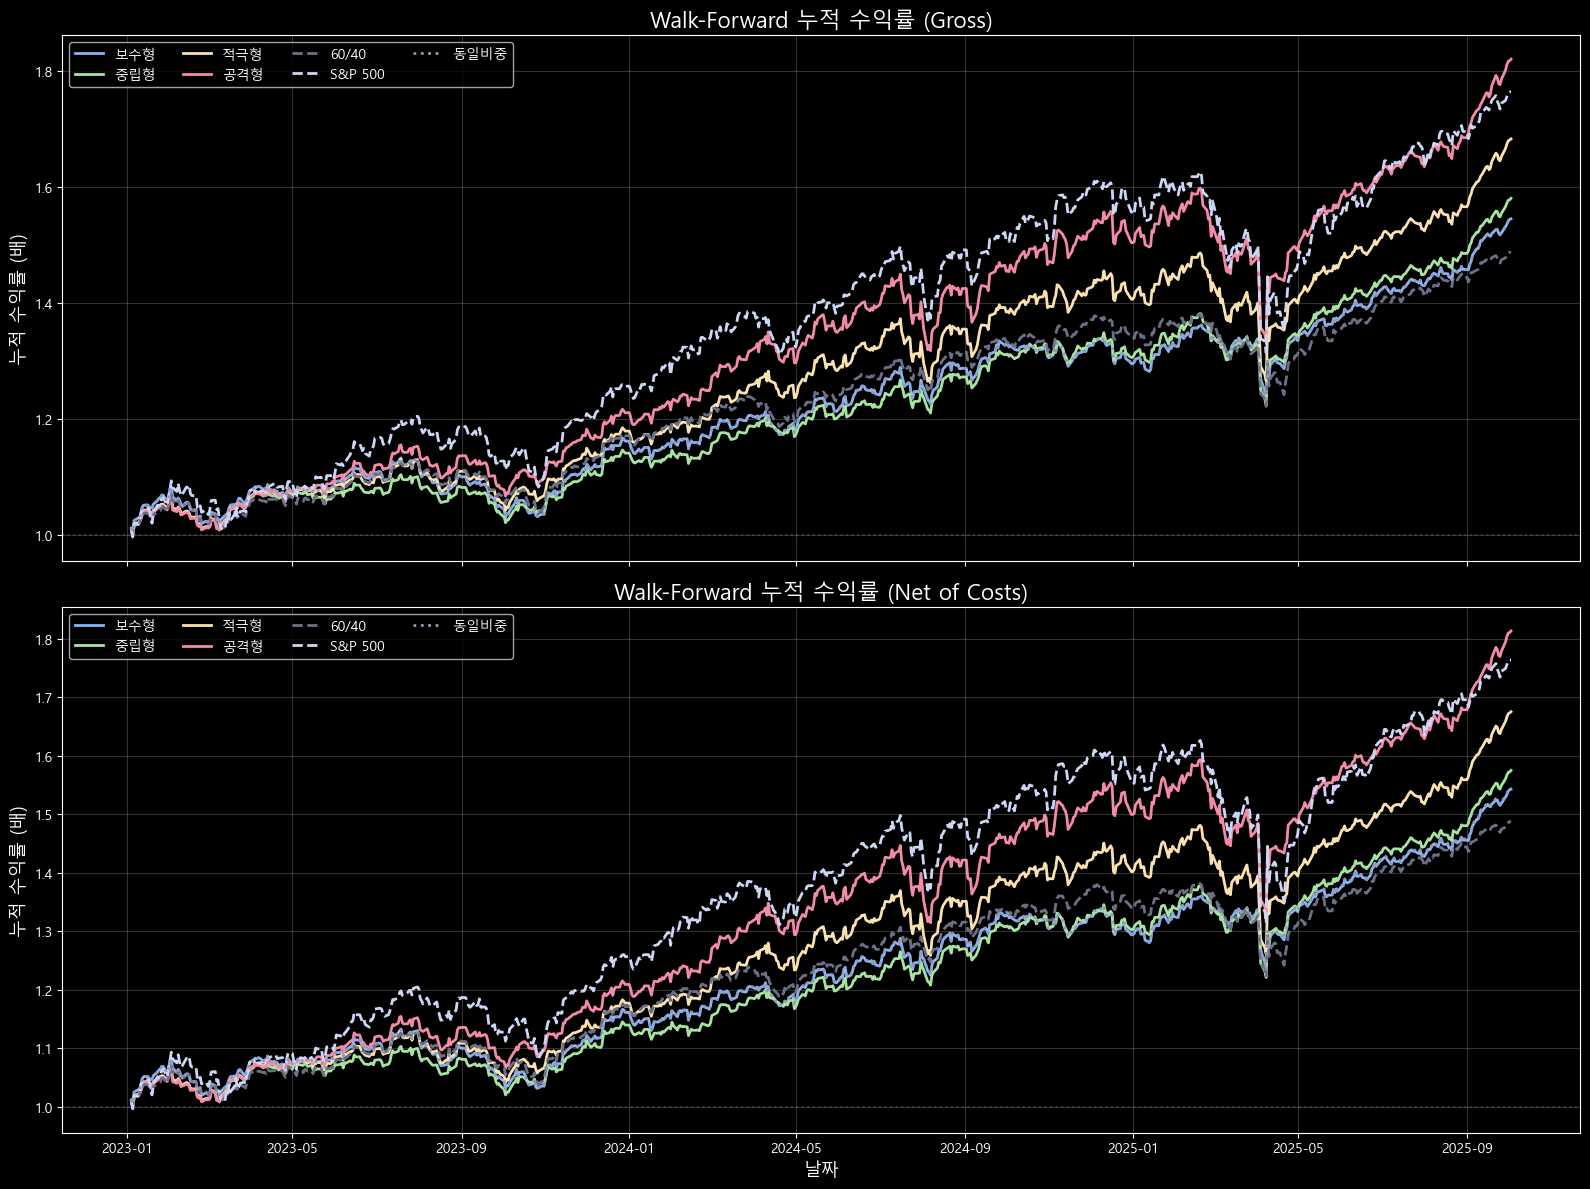

In [86]:
# ── 4-3. 누적 수익률 곡선 ────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# 색상 설정
colors_all = {
    "보수형": "#89b4fa", "중립형": "#a6e3a1",
    "적극형": "#f9e2af", "공격형": "#f38ba8",
    "60/40": "#6c7086", "S&P 500": "#cdd6f4", "동일비중": "#9399b2",
}
linestyles = {
    "보수형": "-", "중립형": "-", "적극형": "-", "공격형": "-",
    "60/40": "--", "S&P 500": "--", "동일비중": ":",
}

# (1) 누적 수익률 (거래비용 차감 전)
ax1 = axes[0]
for name, res in bt_results.items():
    cum = (1 + res["daily_returns"]["return"]).cumprod()
    ax1.plot(cum.index, cum.values, color=colors_all[name],
             linestyle=linestyles.get(name, "-"), linewidth=2, label=name)
ax1.set_ylabel("누적 수익률 (배)", fontsize=13)
ax1.set_title("Walk-Forward 누적 수익률 (Gross)", fontsize=16, color="white")
ax1.legend(fontsize=10, ncol=4, loc="upper left")
ax1.grid(True, alpha=0.2)
ax1.axhline(y=1, color="#585b70", linestyle=":", alpha=0.5)

# (2) 누적 수익률 (거래비용 차감 후)
ax2 = axes[1]
for name, res in bt_results.items():
    cum = (1 + res["daily_returns"]["return_net"]).cumprod()
    ax2.plot(cum.index, cum.values, color=colors_all[name],
             linestyle=linestyles.get(name, "-"), linewidth=2, label=name)
ax2.set_ylabel("누적 수익률 (배)", fontsize=13)
ax2.set_xlabel("날짜", fontsize=13)
ax2.set_title("Walk-Forward 누적 수익률 (Net of Costs)", fontsize=16, color="white")
ax2.legend(fontsize=10, ncol=4, loc="upper left")
ax2.grid(True, alpha=0.2)
ax2.axhline(y=1, color="#585b70", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

# Gross vs Net 비교:
#   차이가 크면 리밸런싱 빈도·턴오버가 과도 → 전략 재검토 필요
#   보수형: 턴오버 낮음 → Gross ≈ Net
#   공격형: 턴오버 높음 → Net 열화 가능

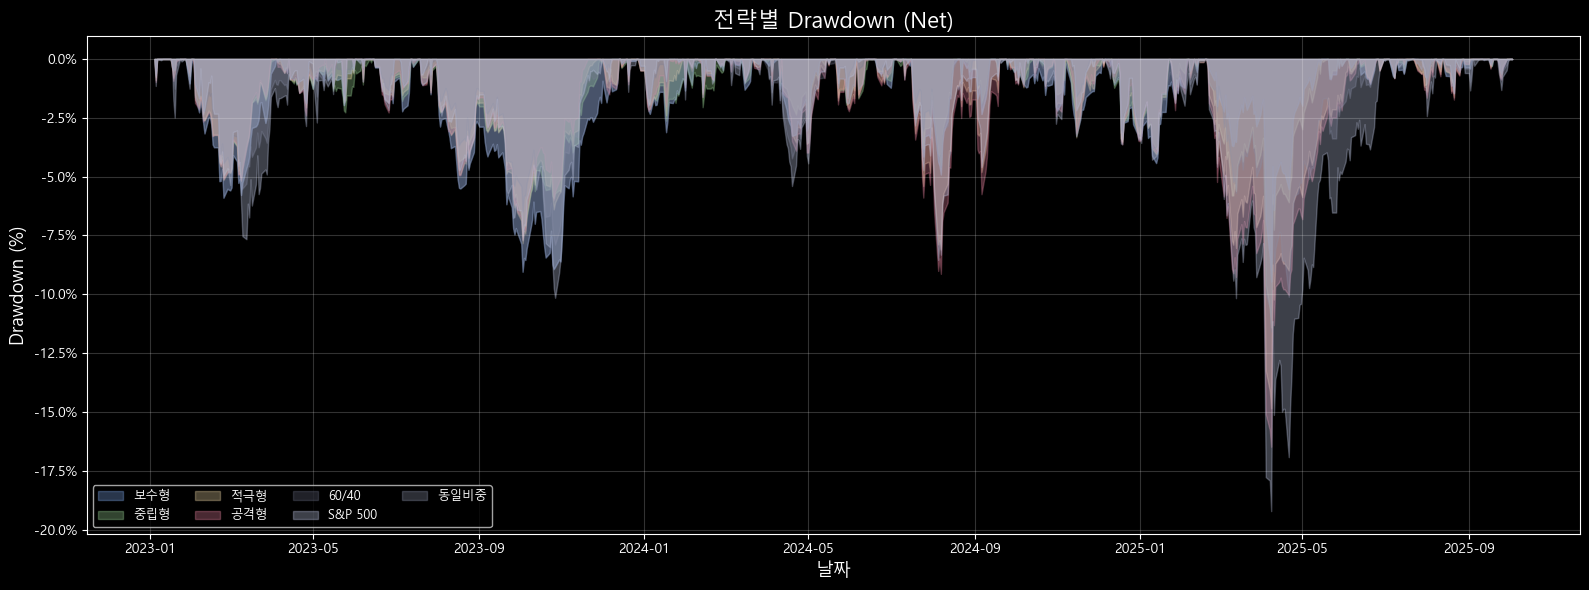

In [87]:
# ── 4-3B. Drawdown 시각화 ───────────────────────────

fig, ax = plt.subplots(figsize=(16, 6))

for name, res in bt_results.items():
    cum = (1 + res["daily_returns"]["return_net"]).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    ax.fill_between(drawdown.index, drawdown.values.flatten(), 0,
                    alpha=0.3, color=colors_all[name], label=name)

ax.set_ylabel("Drawdown (%)", fontsize=13)
ax.set_xlabel("날짜", fontsize=13)
ax.set_title("전략별 Drawdown (Net)", fontsize=16, color="white")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=9, ncol=4, loc="lower left")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Drawdown: 고점 대비 하락폭 — 투자자가 체감하는 "손실"
# MDD(Maximum Drawdown): 전체 기간 중 최대 낙폭
# 보수형: 얕고 짧은 drawdown, 공격형: 깊고 긴 drawdown
# COVID-19(2020-03) 구간에서 모든 전략의 drawdown 집중 예상

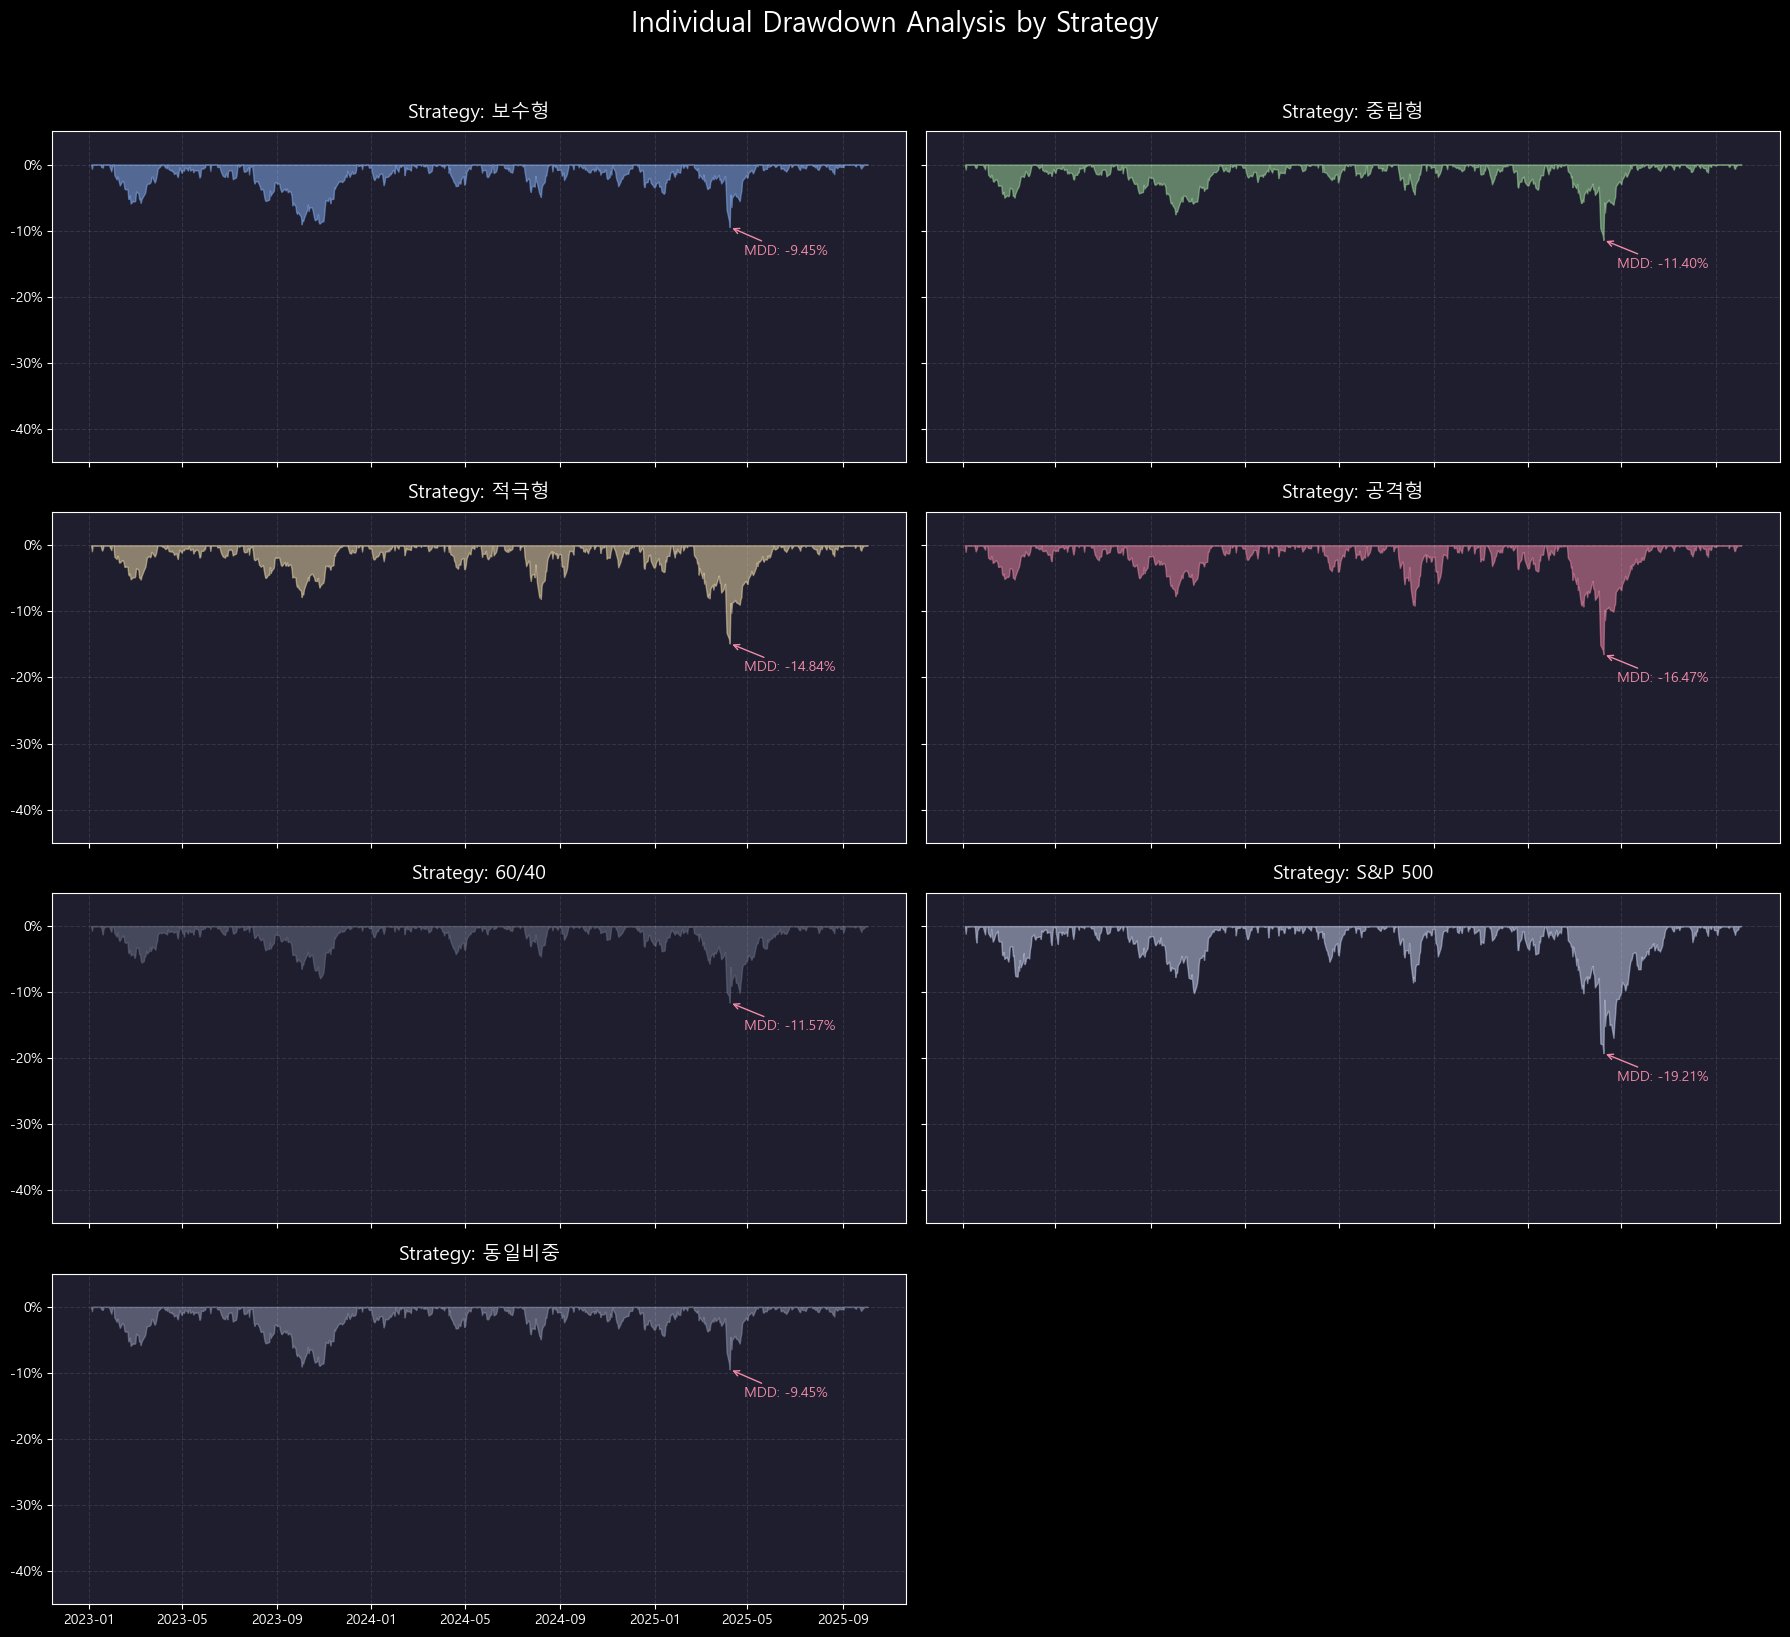

In [88]:
# ── 4-3C. 전략별 개별 Drawdown 분석 (Facet Plot) ──────────

import math

# 전략 개수에 맞춰 서브플롯 레이아웃 결정
n_strategies = len(bt_results)
cols = 2
rows = math.ceil(n_strategies / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (name, res) in enumerate(bt_results.items()):
    ax = axes[idx]
    
    # 누적 수익률 및 낙폭 계산
    cum = (1 + res["daily_returns"]["return_net"]).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    
    # 낙폭 영역 채우기 (개별 색상 적용)
    color = colors_all.get(name, "#89b4fa")
    ax.fill_between(drawdown.index, drawdown.values.flatten(), 0,
                    alpha=0.5, color=color)
    
    # MDD(최대 낙폭) 지점 표시
    mdd = drawdown.min()
    mdd_date = drawdown.idxmin()
    ax.annotate(f"MDD: {mdd:.2%}", 
                xy=(mdd_date, mdd), xytext=(10, -20),
                textcoords="offset points", color="#f38ba8",
                arrowprops=dict(arrowstyle="->", color="#f38ba8"))

    # 차트 꾸미기
    ax.set_title(f"Strategy: {name}", fontsize=14, color="white", pad=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_ylim(-0.45, 0.05) # 모든 그래프의 Y축을 통일하여 위험도를 직접 비교
    ax.grid(True, linestyle="--", alpha=0.1)
    
    # 배경색 조정 (다크 모드 유지)
    ax.set_facecolor("#1e1e2e")

# 남는 빈 칸 제거
for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Individual Drawdown Analysis by Strategy", fontsize=20, color="white", y=1.02)
plt.tight_layout()
plt.show()

# [해석 포인트]
# 💡 깊이(Depth): 그래프가 아래로 얼마나 깊게 내려갔는가? (공격형일수록 깊음)
# 💡 기간(Duration): 바닥에서 0으로 다시 올라오는 데 시간이 얼마나 걸리는가?
# 💡 MDD 표시: 각 전략이 겪은 '최악의 순간'을 수치로 바로 확인 가능합니다.


In [89]:
# ── 4-4. 성과 지표 산출 ──────────────────────────────

def compute_metrics(daily_returns, annualize=252):
    """
    일별 수익률 시계열에서 핵심 성과 지표를 산출한다.

    Returns
    -------
    dict : Sharpe, Sortino, MDD, Calmar, 연율 수익률·변동성
    """
    r = daily_returns.values.flatten()

    # 연율 수익률·변동성
    ann_ret = np.mean(r) * annualize
    ann_vol = np.std(r, ddof=1) * np.sqrt(annualize)

    # Sharpe Ratio (무위험 = 0 가정)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    # Sortino Ratio (하방 변동성만 사용)
    downside = r[r < 0]
    down_vol = np.std(downside, ddof=1) * np.sqrt(annualize) if len(downside) > 1 else 1e-6
    sortino = ann_ret / down_vol

    # MDD
    cum = np.cumprod(1 + r)
    running_max = np.maximum.accumulate(cum)
    dd = (cum - running_max) / running_max
    mdd = dd.min()

    # Calmar Ratio (연율 수익 / |MDD|)
    calmar = ann_ret / abs(mdd) if abs(mdd) > 1e-6 else 0

    # 누적 수익률
    total_return = cum[-1] - 1

    return {
        "연율 수익률": ann_ret,
        "연율 변동성": ann_vol,
        "Sharpe":   sharpe,
        "Sortino":  sortino,
        "MDD":      mdd,
        "Calmar":   calmar,
        "누적 수익률": total_return,
    }


# 전략별 성과 지표 테이블
metrics_rows = []
for name, res in bt_results.items():
    m = compute_metrics(res["daily_returns"]["return_net"])
    m["전략"] = name
    m["거래비용"] = res["total_cost"]
    metrics_rows.append(m)

df_metrics = pd.DataFrame(metrics_rows).set_index("전략")

# 포맷팅
fmt_cols = {
    "연율 수익률": "{:.2%}", "연율 변동성": "{:.2%}",
    "Sharpe": "{:.2f}", "Sortino": "{:.2f}",
    "MDD": "{:.2%}", "Calmar": "{:.2f}",
    "누적 수익률": "{:.2%}", "거래비용": "{:.4%}",
}
for col, fmt in fmt_cols.items():
    df_metrics[col] = df_metrics[col].apply(lambda x: fmt.format(x))

print("📊 Walk-Forward 성과 지표 (Net of Costs):")
display(df_metrics)

# 지표 해석:
#   Sharpe: 위험 조정 수익 (>1 우수, 0.5~1 양호)
#   Sortino: 하방 위험만 고려 — Sharpe보다 보수적
#   MDD: 투자자 체감 손실 — 보수형 제약(-10%) 대비 실제 MDD 확인
#   Calmar: 연율 수익/MDD — 낙폭 대비 보상 효율
#   거래비용: 분기 리밸런싱 누적 — 높을수록 전략 실효성 감소

📊 Walk-Forward 성과 지표 (Net of Costs):


,연율 수익률,연율 변동성,Sharpe,Sortino,MDD,Calmar,누적 수익률,거래비용
전략,,,,,,,,
보수형,15.70%,9.82%,1.60,2.29,-9.45%,1.66,54.28%,0.1500%
중립형,16.41%,9.65%,1.70,2.35,-11.40%,1.44,57.49%,0.3537%
적극형,18.78%,11.52%,1.63,2.15,-14.84%,1.27,67.52%,0.4606%
공격형,21.70%,12.69%,1.71,2.21,-16.47%,1.32,81.34%,0.3900%
60/40,14.39%,9.73%,1.48,2.02,-11.57%,1.24,48.67%,0.0000%
S&P 500,21.07%,15.18%,1.39,1.79,-19.21%,1.10,76.38%,0.0000%
동일비중,15.76%,9.82%,1.60,2.30,-9.45%,1.67,54.51%,0.0000%


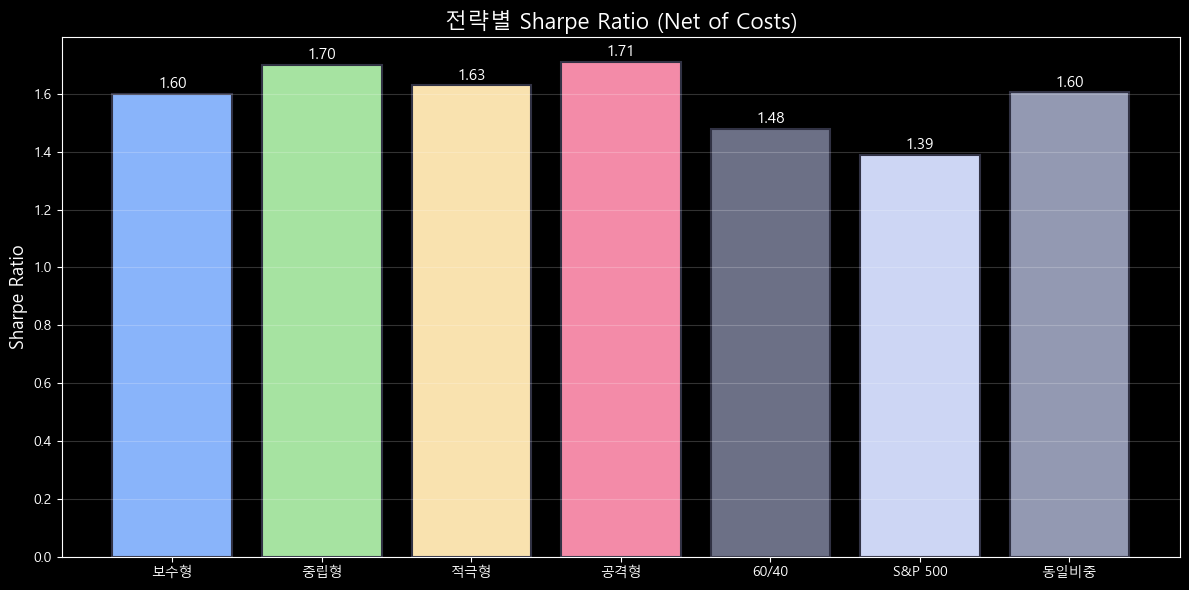

In [90]:
# ── 4-5A. Sharpe Ratio 비교 ──────────────────────────

# 수치 재계산 (포맷 전)
sharpe_vals = {}
for name, res in bt_results.items():
    m = compute_metrics(res["daily_returns"]["return_net"])
    sharpe_vals[name] = m["Sharpe"]

fig, ax = plt.subplots(figsize=(12, 6))

names = list(sharpe_vals.keys())
vals = [sharpe_vals[n] for n in names]
bar_colors = [colors_all.get(n, "#cdd6f4") for n in names]

bars = ax.bar(names, vals, color=bar_colors, edgecolor="#313244", linewidth=1.5)

# 값 레이블
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{v:.2f}", ha="center", fontsize=11, color="white")

ax.set_ylabel("Sharpe Ratio", fontsize=13)
ax.set_title("전략별 Sharpe Ratio (Net of Costs)", fontsize=16, color="white")
ax.axhline(y=0, color="#585b70", linewidth=0.5)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

# Sharpe 비교 핵심:
#   최적화 전략 > 벤치마크 → 최적화의 부가가치 존재
#   최적화 전략 ≈ 동일비중 → 복잡성 대비 이득 미미
#   S&P 500 > 모든 전략 → 분산 투자의 비용 (집중 리스크와 트레이드오프)

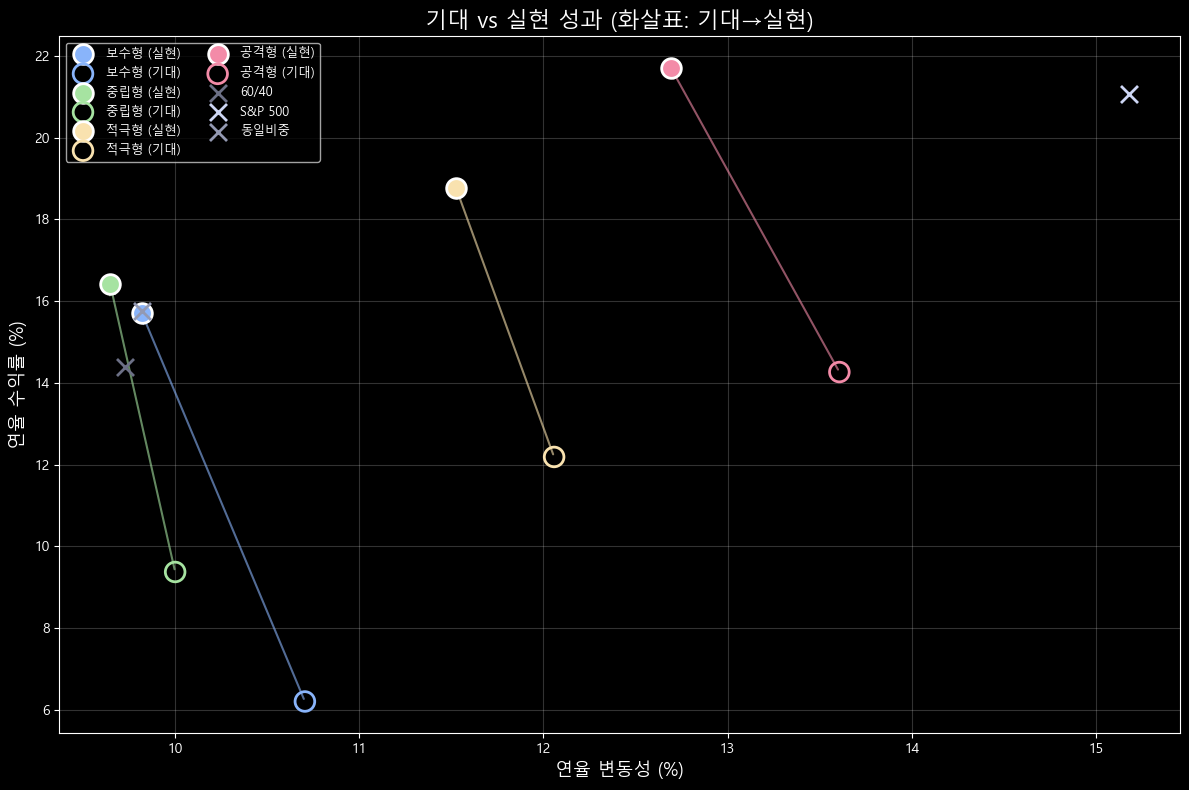

In [91]:
# ── 4-5B. 실현 vs 기대 성과 산점도 ───────────────────

fig, ax = plt.subplots(figsize=(12, 8))

for name in PROFILES:
    p = PROFILES[name]
    m = compute_metrics(bt_results[name]["daily_returns"]["return_net"])

    # 실현 (채워진 마커)
    ax.scatter(m["연율 변동성"] * 100, m["연율 수익률"] * 100, s=200,
               color=profile_colors[name], edgecolors="white", linewidth=2,
               marker="o", zorder=5,
               label=f"{name} (실현)")

    # 기대 (빈 마커)
    w = optimal_weights[name]
    exp_ret = (w @ mu_annual.values) * 100
    exp_vol = np.sqrt(w @ cov_annual_lw.values @ w) * 100
    ax.scatter(exp_vol, exp_ret, s=200,
               color=profile_colors[name], edgecolors=profile_colors[name],
               linewidth=2, facecolors="none", marker="o", zorder=5,
               label=f"{name} (기대)")

    # 기대 → 실현 화살표
    ax.annotate("", xy=(m["연율 변동성"]*100, m["연율 수익률"]*100),
                xytext=(exp_vol, exp_ret),
                arrowprops=dict(arrowstyle="->", color=profile_colors[name],
                                lw=1.5, alpha=0.6))

# 벤치마크
for bm in ["60/40", "S&P 500", "동일비중"]:
    m = compute_metrics(bt_results[bm]["daily_returns"]["return_net"])
    ax.scatter(m["연율 변동성"]*100, m["연율 수익률"]*100, s=150,
               color=colors_all[bm], marker="x", linewidths=2,
               label=bm, zorder=5)

ax.set_xlabel("연율 변동성 (%)", fontsize=13)
ax.set_ylabel("연율 수익률 (%)", fontsize=13)
ax.set_title("기대 vs 실현 성과 (화살표: 기대→실현)", fontsize=16, color="white")
ax.legend(fontsize=9, ncol=2, loc="upper left")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 화살표 해석:
#   짧은 화살표 → 기대와 실현의 괴리 적음 → 모델 신뢰도 높음
#   아래로 향하는 화살표 → 실현 수익 < 기대 수익 (과적합 가능성)
#   오른쪽으로 향하는 화살표 → 실현 변동성 > 기대 변동성 (리스크 과소추정)

C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\1625524096.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  neutral_monthly = neutral_daily.resample("M").apply(


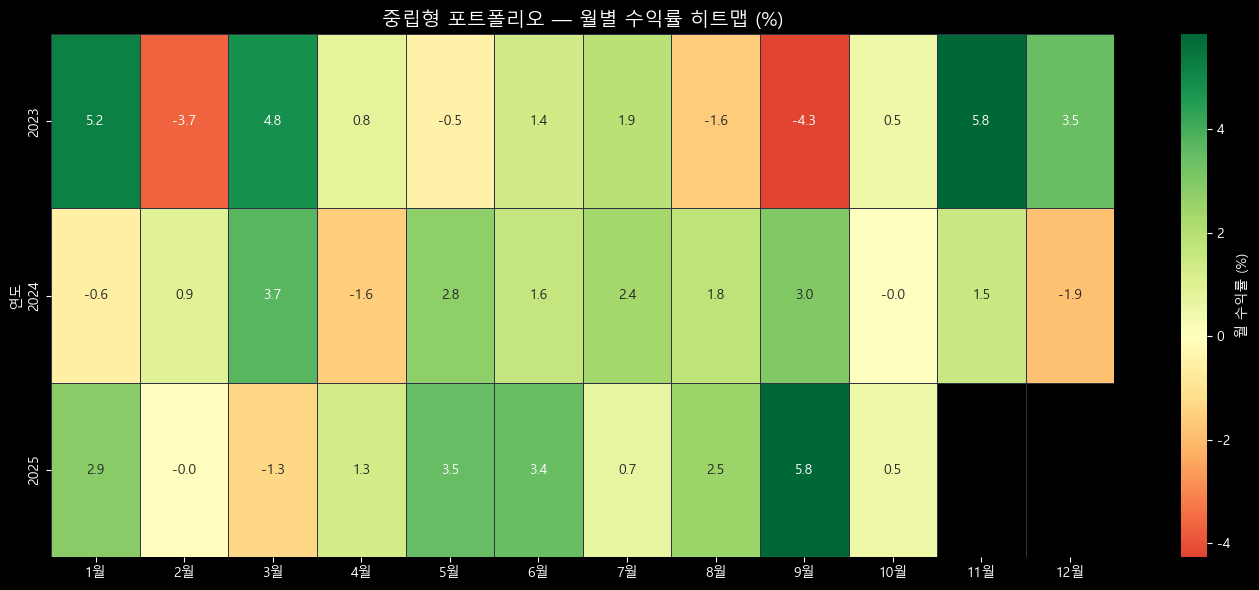

In [92]:
# ── 4-5C. 월별 수익률 히트맵 (중립형 예시) ──────────

# 중립형 포트폴리오의 월별 수익률
neutral_daily = bt_results["중립형"]["daily_returns"]["return_net"]
neutral_monthly = neutral_daily.resample("M").apply(
    lambda x: (1 + x).prod() - 1
)
neutral_monthly.index = neutral_monthly.index.to_period("M")

# 연도 × 월 피벗
pivot = neutral_monthly.reset_index()
pivot.columns = ["period", "return"]
pivot["year"]  = pivot["period"].dt.year
pivot["month"] = pivot["period"].dt.month
heatmap_data = pivot.pivot(index="year", columns="month", values="return")
heatmap_data.columns = [f"{m}월" for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data * 100, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5, linecolor="#313244",
            cbar_kws={"label": "월 수익률 (%)"}, ax=ax)
ax.set_title("중립형 포트폴리오 — 월별 수익률 히트맵 (%)",
             fontsize=14, color="white")
ax.set_ylabel("연도")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

# 히트맵 해석:
#   녹색: 양의 수익 | 적색: 음의 수익 | 색 강도: 크기
#   특정 월에 반복적으로 적색 → 계절성 패턴 의심
#   연속 적색 → 시장 위기 구간 (COVID, 금리 인상 등)
#   Phase 5에서 이 구간의 외부 지표 변동과 대조 분석

In [95]:
# ── 5-1A. 실현 변동성 산출 ───────────────────────────

ROLL_WINDOW = 21  # 21거래일 ≈ 1개월

# 중립형 포트폴리오의 실현 변동성 (대표 성향)
neutral_ret = bt_results["중립형"]["daily_returns"]["return_net"]
rv_neutral = neutral_ret.rolling(ROLL_WINDOW).std() * np.sqrt(252)
rv_neutral.columns = ["RV_neutral"]

# 전 성향 실현 변동성
rv_all = {}
for name in PROFILES:
    ret = bt_results[name]["daily_returns"]["return_net"]
    rv = ret.rolling(ROLL_WINDOW).std() * np.sqrt(252)
    rv_all[name] = rv.rename(f"RV_{name}")


print(f"✅ 실현 변동성 산출 완료 (롤링 {ROLL_WINDOW}일)")
print(f"  중립형 RV 범위: {rv_neutral.min():.2%} ~ {rv_neutral.max():.2%}")

# Realized Volatility (RV):
#   σ_t = std(r_{t-20}, ..., r_t) × √252
#   21거래일 롤링 → 1개월 단위 변동성 추정
#   연율화(×√252)하여 Phase 2의 target_vol과 직접 비교 가능

✅ 실현 변동성 산출 완료 (롤링 21일)
  중립형 RV 범위: 4.63% ~ 30.89%


In [96]:
# ── 5-1B. 독립 변수 (외부 지표) 준비 ────────────────

# 외부 지표 수익률 (Phase 0에서 산출)
ext_tickers = ["CL=F", "GC=F", "SI=F", "BTC-USD", "ETH-USD",
               "^VIX", "DX-Y.NYB"]
ext_labels  = ["WTI 원유", "금 선물", "은 선물", "비트코인",
               "이더리움", "VIX", "달러 인덱스"]

# 롤링 변동성 (외부 지표의 자체 변동성도 독립 변수로 추가)
ext_rv = df_ext_ret[ext_tickers].rolling(ROLL_WINDOW).std() * np.sqrt(252)
ext_rv.columns = [f"RV_{t}" for t in ext_tickers]

# 수준(level) 변수: VIX는 수익률보다 수준이 의미 있음
# df_prices에서 VIX 종가를 직접 사용
vix_level = df_prices["^VIX"].reindex(rv_neutral.index)

# FRED 거시 지표 (월별 → 일별 forward fill)
macro_daily = df_macro.reindex(rv_neutral.index, method="ffill")

# 통합 회귀 데이터셋
df_reg = pd.concat([
    rv_neutral,
    df_ext_ret[ext_tickers].reindex(rv_neutral.index),
    ext_rv.reindex(rv_neutral.index),
    vix_level.rename("VIX_level"),
    macro_daily,
], axis=1).dropna()

print(f"✅ 회귀 데이터셋: {df_reg.shape[0]}행 × {df_reg.shape[1]}열")
print(f"  기간: {df_reg.index.min().date()} ~ {df_reg.index.max().date()}")

# 독립 변수 구성:
#   1. 외부 지표 일별 수익률 (방향성 영향)
#   2. 외부 지표 롤링 변동성 (변동성 전이 영향)
#   3. VIX 수준 (공포 지수 — 시장 스트레스 프록시)
#   4. FRED 거시 지표 (금리, CPI, 실업률 — 구조적 환경)

✅ 회귀 데이터셋: 698행 × 20열
  기간: 2023-02-01 ~ 2025-10-03


In [98]:
print(df_reg.columns.tolist())
print(list(rv_all.keys()))


['return_net', 'CL=F', 'GC=F', 'SI=F', 'BTC-USD', 'ETH-USD', '^VIX', 'DX-Y.NYB', 'RV_CL=F', 'RV_GC=F', 'RV_SI=F', 'RV_BTC-USD', 'RV_ETH-USD', 'RV_^VIX', 'RV_DX-Y.NYB', 'VIX_level', 'DGS10', 'CPIAUCSL', 'UNRATE', 'CPI_MoM']
['보수형', '중립형', '적극형', '공격형']


                            OLS Regression Results                            
Dep. Variable:                 RV_중립형   R-squared:                       0.424
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     12.03
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           9.67e-18
Time:                        15:13:55   Log-Likelihood:                 1417.9
No. Observations:                 698   AIC:                            -2816.
Df Residuals:                     688   BIC:                            -2770.
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0853      0.018     -4.648      0.0

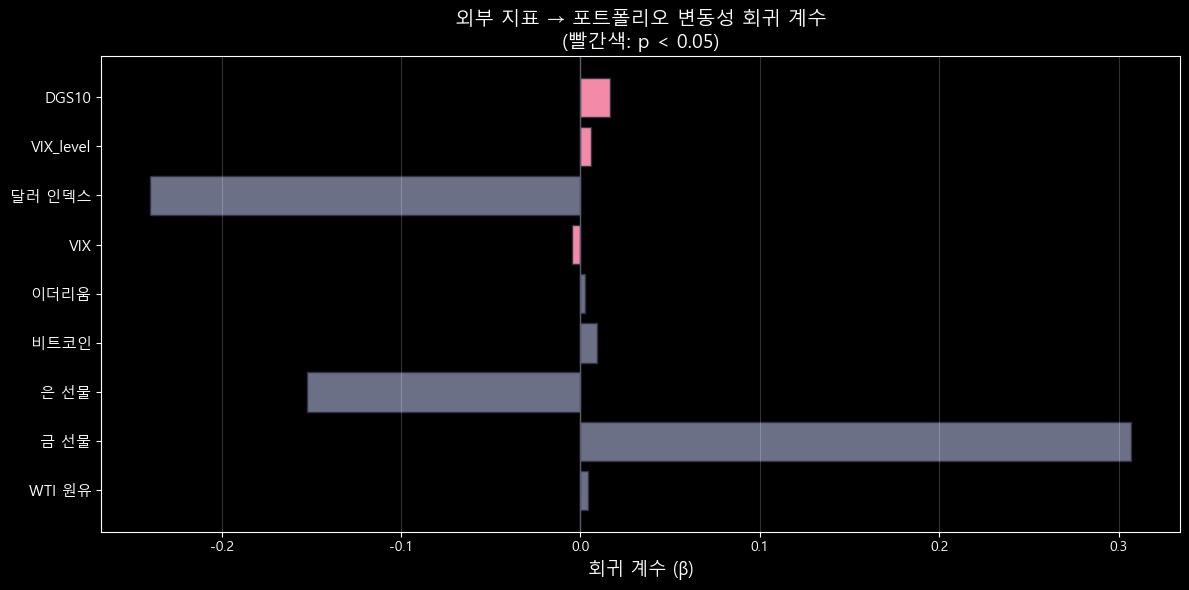

In [99]:
# ── 5-1C. 다중 회귀 분석 ────────────────────────────

import statsmodels.api as sm

# 독립 변수 선택 (다중공선성 방지: 수익률 + VIX + 금리)
X_cols = ext_tickers + ["VIX_level", "DGS10"]
X_raw = sm.add_constant(df_reg[X_cols])

# 종속 변수: 중립형 포트폴리오 실현 변동성
y_raw = rv_all["중립형"].rename("RV_중립형")

# 인덱스 정렬 및 NaN 제거 (롤링 윈도우 초반 NaN 처리)
common_idx = X_raw.index.intersection(y_raw.dropna().index)
X = X_raw.loc[common_idx].dropna()
y = y_raw.loc[X.index]

model = sm.OLS(y, X).fit(cov_type="HC1")  # 이분산 강건 표준오차


print(model.summary())

# 주요 계수 시각화
fig, ax = plt.subplots(figsize=(12, 6))

coefs = model.params.drop("const")
pvals = model.pvalues.drop("const")
colors_coef = ["#f38ba8" if p < 0.05 else "#6c7086" for p in pvals]

bars = ax.barh(range(len(coefs)), coefs.values, color=colors_coef,
               edgecolor="#313244")
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels([f"{ext_labels[i] if i < len(ext_labels) else c}"
                     for i, c in enumerate(coefs.index)], fontsize=11)
ax.set_xlabel("회귀 계수 (β)", fontsize=13)
ax.set_title("외부 지표 → 포트폴리오 변동성 회귀 계수\n(빨간색: p < 0.05)",
             fontsize=14, color="white")
ax.axvline(x=0, color="#585b70", linewidth=1)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# OLS 회귀 해석:
#   β > 0: 해당 지표 상승 → 포트폴리오 변동성 증가
#   β < 0: 해당 지표 상승 → 포트폴리오 변동성 감소
#   HC1: White(1980) 이분산 강건 표준오차 — 금융 시계열 필수
#   R²: 외부 지표가 포트폴리오 변동성의 몇 %를 설명하는지
#   예상: VIX β > 0 (유의), 금 β < 0 (안전자산 효과)

c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: Fut

📊 Granger 인과 검정 결과 (X → 포트폴리오 변동성):
       최적 시차(일) p-value 유의(5%)
VIX           3  0.0000   True
금 선물          7  0.0002   True
은 선물          4  0.0036   True
달러 인덱스        6  0.0082   True
이더리움          1  0.0198   True
WTI 원유        1  0.1402  False
비트코인          1  0.1948  False


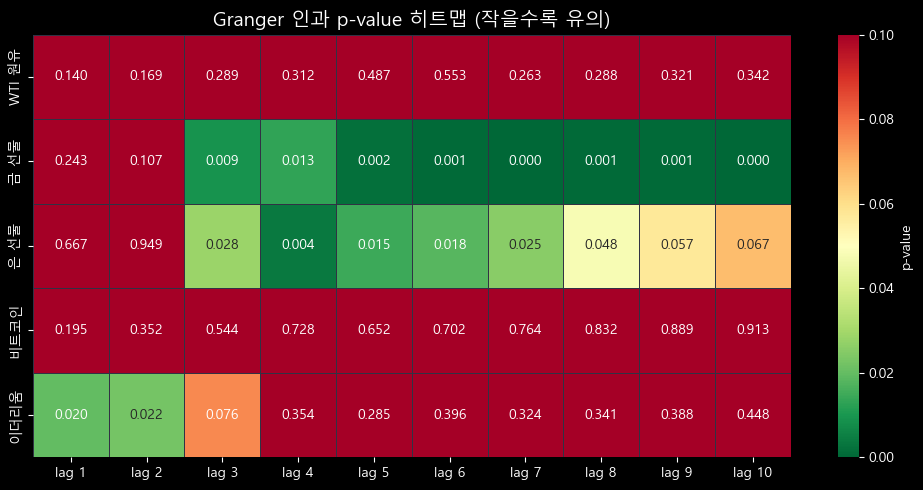

In [106]:
# ── 5-2. Granger 인과 검정 ──────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests

MAX_LAG = 10
granger_results = {}
granger_raw = {}

rv_neutral = rv_all["중립형"].rename("RV_중립형")  # ← df_reg 불필요

for ticker, label in zip(ext_tickers, ext_labels):
    test_data = pd.concat([rv_neutral, df_reg[ticker]], axis=1).dropna()  # ← 직접 합치기
    if len(test_data) < MAX_LAG * 3:
        continue
    try:
        result = grangercausalitytests(test_data, maxlag=MAX_LAG, verbose=False)
        granger_raw[label] = result
        pvals_by_lag = {lag: round(result[lag][0]["ssr_ftest"][1], 4)
                        for lag in range(1, MAX_LAG + 1)}
        best_lag = min(pvals_by_lag, key=pvals_by_lag.get)
        best_pval = pvals_by_lag[best_lag]
        granger_results[label] = {"best_lag": best_lag, "p_value": best_pval,
                                   "significant": best_pval < 0.05}
    except Exception:
        granger_results[label] = {"best_lag": None, "p_value": None,
                                   "significant": False}


df_granger = pd.DataFrame(granger_results).T
df_granger.columns = ["최적 시차(일)", "p-value", "유의(5%)"]
df_granger = df_granger.sort_values("p-value")
print("📊 Granger 인과 검정 결과 (X → 포트폴리오 변동성):")
print(df_granger)

fig, ax = plt.subplots(figsize=(10, 5))
pval_matrix = pd.DataFrame(
    {label: {f"lag {lag}": granger_raw[label][lag][0]["ssr_ftest"][1]
             for lag in range(1, MAX_LAG + 1)}
     for label, ticker in zip(ext_labels[:5], ext_tickers[:5])
     if label in granger_raw}
).T

sns.heatmap(pval_matrix, annot=True, fmt=".3f", cmap="RdYlGn_r",
            vmin=0, vmax=0.1, linewidths=0.5, linecolor="#313244",
            cbar_kws={"label": "p-value"}, ax=ax)
ax.set_title("Granger 인과 p-value 히트맵 (작을수록 유의)",
             fontsize=14, color="white")
plt.tight_layout()
plt.show()


In [108]:
# ── 5-3. 레짐 분석 (Hidden Markov Model) ────────────

from hmmlearn.hmm import GaussianHMM

# VIX 수준으로 레짐 분류 (2 상태: 저변동·고변동)
vix_data = df_reg["VIX_level"].values.reshape(-1, 1)

hmm_model = GaussianHMM(
    n_components=2,        # 2개 레짐
    covariance_type="full",
    n_iter=200,
    random_state=42
)
hmm_model.fit(vix_data)
regimes = hmm_model.predict(vix_data)

# 레짐 레이블링 (평균 VIX가 낮은 쪽 = 0: 안정, 높은 쪽 = 1: 위기)
means = hmm_model.means_.flatten()
if means[0] > means[1]:
    regimes = 1 - regimes  # 레이블 반전

df_reg["regime"] = regimes
regime_labels = {0: "🟢 안정 (Low Vol)", 1: "🔴 위기 (High Vol)"}

print("📊 레짐 분류 결과:")
for r, label in regime_labels.items():
    mask = df_reg["regime"] == r
    count = mask.sum()
    pct = count / len(df_reg)
    avg_vix = df_reg.loc[mask, "VIX_level"].mean()
    print(f"  {label}: {count}일 ({pct:.1%}), 평균 VIX={avg_vix:.1f}")

# HMM 파라미터 출력
print(f"\n  레짐 전이 확률:")
print(f"    안정→안정: {hmm_model.transmat_[0,0]:.3f}")
print(f"    안정→위기: {hmm_model.transmat_[0,1]:.3f}")
print(f"    위기→안정: {hmm_model.transmat_[1,0]:.3f}")
print(f"    위기→위기: {hmm_model.transmat_[1,1]:.3f}")

# HMM 핵심:
#   은닉 상태(Hidden State): 직접 관측 불가능한 시장 레짐
#   관측 변수: VIX 수준 — 시장 스트레스의 프록시
#   전이 확률: 안정→위기 전환 빈도 — 낮을수록 안정기가 지속적
#   GaussianHMM: 각 레짐에서 VIX가 정규분포를 따른다고 가정

📊 레짐 분류 결과:
  🟢 안정 (Low Vol): 418일 (59.9%), 평균 VIX=14.5
  🔴 위기 (High Vol): 280일 (40.1%), 평균 VIX=20.6

  레짐 전이 확률:
    안정→안정: 0.964
    안정→위기: 0.036
    위기→안정: 0.023
    위기→위기: 0.977


C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\496182015.py:56: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\496182015.py:56: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


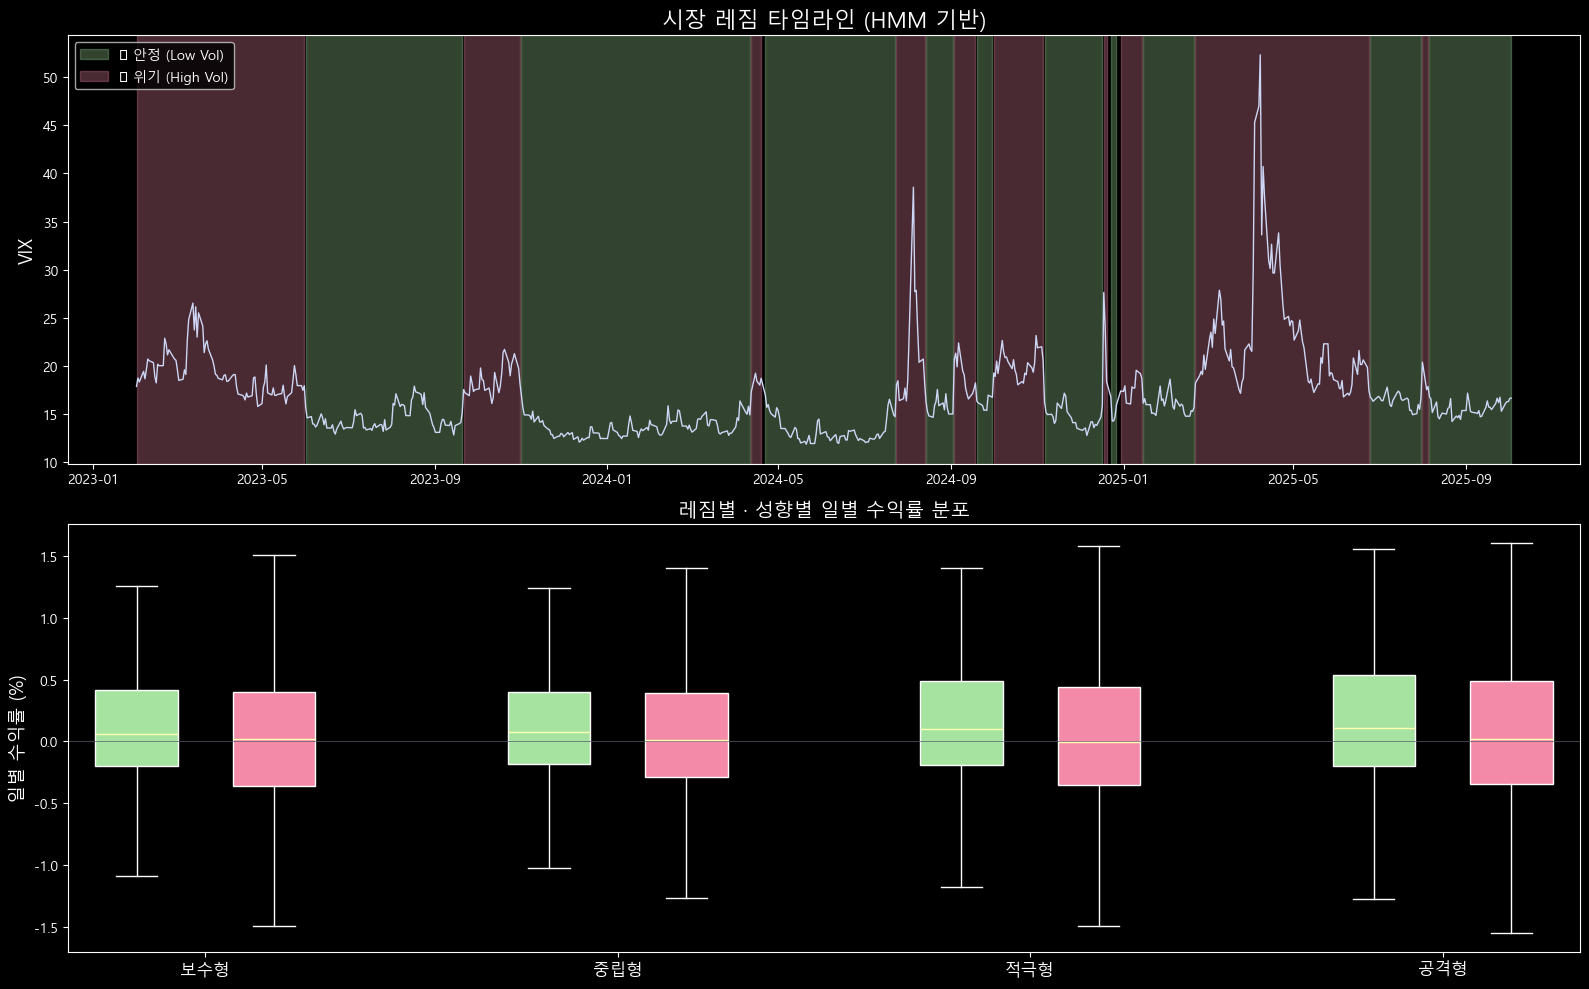

In [117]:
# ── 5-3B. 레짐별 포트폴리오 성과 ────────────────────

# VIX 유효 데이터만 추출
vix_valid = df_reg["VIX_level"].dropna()
regime_series = df_reg["regime"].reindex(vix_valid.index)  # VIX 기간으로 레짐 축소

fig, axes = plt.subplots(2, 1, figsize=(16, 10))  # sharex 제거 (두 차트 독립 x축)

# (1) 레짐 타임라인 + VIX
ax1 = axes[0]
for r, label in regime_labels.items():
    mask = (regime_series == r).fillna(False)
    color = "#a6e3a1" if r == 0 else "#f38ba8"
    ax1.fill_between(vix_valid.index, 0, 1, where=mask,
                     alpha=0.3, color=color, transform=ax1.get_xaxis_transform(),
                     label=label)
ax1.plot(vix_valid.index, vix_valid.values, color="#cdd6f4", linewidth=1)
ax1.set_ylabel("VIX", fontsize=13)
ax1.set_title("시장 레짐 타임라인 (HMM 기반)", fontsize=16, color="white")
ax1.legend(fontsize=10, loc="upper left")

# (2) 레짐별 성향 수익률 박스플롯
ax2 = axes[1]
regime_perf = []
for name in PROFILES:
    ret = bt_results[name]["daily_returns"]["return_net"]
    # ret 인덱스 기준으로 레짐을 역방향 매핑
    regime_on_ret = df_reg["regime"].reindex(ret.index)
    for r in [0, 1]:
        mask = (regime_on_ret == r).fillna(False)
        r_vals = ret.loc[mask].dropna().values * 100
        for v in r_vals:
            regime_perf.append({"성향": name, "레짐": regime_labels[r], "일별수익률(%)": v})

df_regime_perf = pd.DataFrame(regime_perf)

for i, name in enumerate(PROFILES):
    subset = df_regime_perf[df_regime_perf["성향"] == name]
    positions = [i * 3, i * 3 + 1]
    data_stable = subset[subset["레짐"].str.contains("안정")]["일별수익률(%)"].dropna()
    data_crisis  = subset[subset["레짐"].str.contains("위기")]["일별수익률(%)"].dropna()

    bp1 = ax2.boxplot([data_stable], positions=[positions[0]], widths=0.6,
                       patch_artist=True, showfliers=False)
    bp2 = ax2.boxplot([data_crisis],  positions=[positions[1]], widths=0.6,
                       patch_artist=True, showfliers=False)
    bp1["boxes"][0].set_facecolor("#a6e3a1")
    bp2["boxes"][0].set_facecolor("#f38ba8")

ax2.set_xticks([i * 3 + 0.5 for i in range(len(PROFILES))])
ax2.set_xticklabels(PROFILES.keys(), fontsize=12)
ax2.set_ylabel("일별 수익률 (%)", fontsize=13)
ax2.set_title("레짐별 · 성향별 일별 수익률 분포", fontsize=14, color="white")
ax2.axhline(y=0, color="#585b70", linewidth=0.5)

plt.tight_layout()
plt.show()


In [114]:
# ── 5-4A. 역사적 스트레스 시나리오 ───────────────────

STRESS_SCENARIOS = {
    "COVID-19 급락 (2020-02 ~ 2020-03)": ("2020-02-19", "2020-03-23"),
    "금리 인상 충격 (2022-01 ~ 2022-06)": ("2022-01-03", "2022-06-16"),
    "SVB 사태 (2023-03)": ("2023-03-08", "2023-03-15"),
    "VIX 스파이크 (2018-02)": ("2018-02-02", "2018-02-09"),
}

stress_results = []
for scenario, (start, end) in STRESS_SCENARIOS.items():
    for name, p in PROFILES.items():
        try:
            ret = bt_results[name]["daily_returns"]["return_net"]
            period_ret = ret.loc[start:end]
            if len(period_ret) == 0:
                continue
            cum_ret = (1 + period_ret.values.flatten()).prod() - 1
            max_dd = compute_metrics(period_ret)["MDD"]
            stress_results.append({
                "시나리오": scenario,
                "성향": name,
                "누적수익률": f"{cum_ret:.2%}",
                "MDD": f"{max_dd:.2%}",
                "거래일": len(period_ret),
            })
        except Exception:
            pass

df_stress = pd.DataFrame(stress_results)
print("📊 역사적 스트레스 테스트 결과:")
display(df_stress.pivot_table(
    index="시나리오", columns="성향",
    values=["누적수익률", "MDD"], aggfunc="first"
))

# 역사적 시나리오 선정 기준:
#   COVID-19: 최대 급락 (VIX 82까지 상승)
#   금리 인상: 채권·주식 동반 하락 (60/40 실패 시나리오)
#   SVB: 금융 시스템 리스크 — 단기 집중 하락
#   VIX 스파이크: 극단적 변동성 확대 — Volmageddon

📊 역사적 스트레스 테스트 결과:


MDD                          누적수익률                     
성향                   공격형     보수형     적극형     중립형    공격형    보수형    적극형    중립형
시나리오                                                                        
SVB 사태 (2023-03)  -0.28%  -0.71%  -0.35%  -0.32%  1.83%  1.18%  1.73%  1.75%

In [116]:
# ── 5-4B. 가상 스트레스 시나리오 ─────────────────────

HYPOTHETICAL = {
    "원유 50% 급등": {"CL=F": 0.50},
    "금 20% 급등 + BTC 40% 급락": {"GC=F": 0.20, "BTC-USD": -0.40},
    "VIX 80 스파이크": {"^VIX": 2.0},  # 현재 대비 200% 상승
    "달러 10% 강세 + 금리 2%p 상승": {"DX-Y.NYB": 0.10, "DGS10": 0.02},
    "전면 위기 (COVID-유사)": {
        "CL=F": -0.30, "GC=F": 0.15, "BTC-USD": -0.50,
        "^VIX": 3.0, "DX-Y.NYB": 0.05
    },
}

def estimate_stress_impact(scenario_shocks, model, profile_weights, mu, cov):
    """
    가상 시나리오의 포트폴리오 영향을 회귀 모델 기반으로 추정.

    회귀 계수를 사용하여 외부 지표 충격 → 변동성 변화를 예측하고,
    간접적으로 포트폴리오 손실을 추정한다.
    """
    # 회귀 계수를 통한 변동성 변화 추정
    delta_rv = 0
    for ticker, shock in scenario_shocks.items():
        if ticker in model.params.index:
            delta_rv += model.params[ticker] * shock

    # 현재 변동성 + 충격
    current_vol = np.sqrt(profile_weights @ cov @ profile_weights)
    stressed_vol = current_vol + delta_rv

    # 1일 예상 손실 (변동성 × 2σ)
    loss_1d = -2 * stressed_vol / np.sqrt(252)

    return {
        "변동성 변화": delta_rv,
        "스트레스 변동성": stressed_vol,
        "1일 2σ 손실": loss_1d,
    }


hypo_results = []
for scenario, shocks in HYPOTHETICAL.items():
    for name, w in optimal_weights.items():
        impact = estimate_stress_impact(
            shocks, model, w, mu_annual.values, cov_annual_lw.values
        )
        hypo_results.append({
            "시나리오": scenario,
            "성향": name,
            "변동성 Δ": f"{impact['변동성 변화']:.2%}",
            "스트레스 σ": f"{impact['스트레스 변동성']:.2%}",
            "1일 손실(2σ)": f"{impact['1일 2σ 손실']:.2%}",
        })

df_hypo = pd.DataFrame(hypo_results)
print("\n📊 가상 스트레스 테스트 결과:")
display(df_hypo.pivot_table(
    index="시나리오", columns="성향",
    values="1일 손실(2σ)", aggfunc="first"
))

# 가상 시나리오 해석:
#   회귀 모델의 β 계수로 외부 충격 → 변동성 변화 추정
#   2σ 손실: 95% 확률 내 최대 일일 손실 추정
#   전면 위기: 다수 지표 동시 충격 — 상관 증가 효과 미반영 (보수적)


📊 가상 스트레스 테스트 결과:


성향,공격형,보수형,적극형,중립형
시나리오,,,,
VIX 80 스파이크,-1.60%,-1.23%,-1.40%,-1.14%
금 20% 급등 + BTC 40% 급락,-2.44%,-2.08%,-2.25%,-1.99%
달러 10% 강세 + 금리 2%p 상승,-1.42%,-1.05%,-1.22%,-0.96%
원유 50% 급등,-1.74%,-1.37%,-1.54%,-1.29%
전면 위기 (COVID-유사),-1.89%,-1.53%,-1.70%,-1.44%


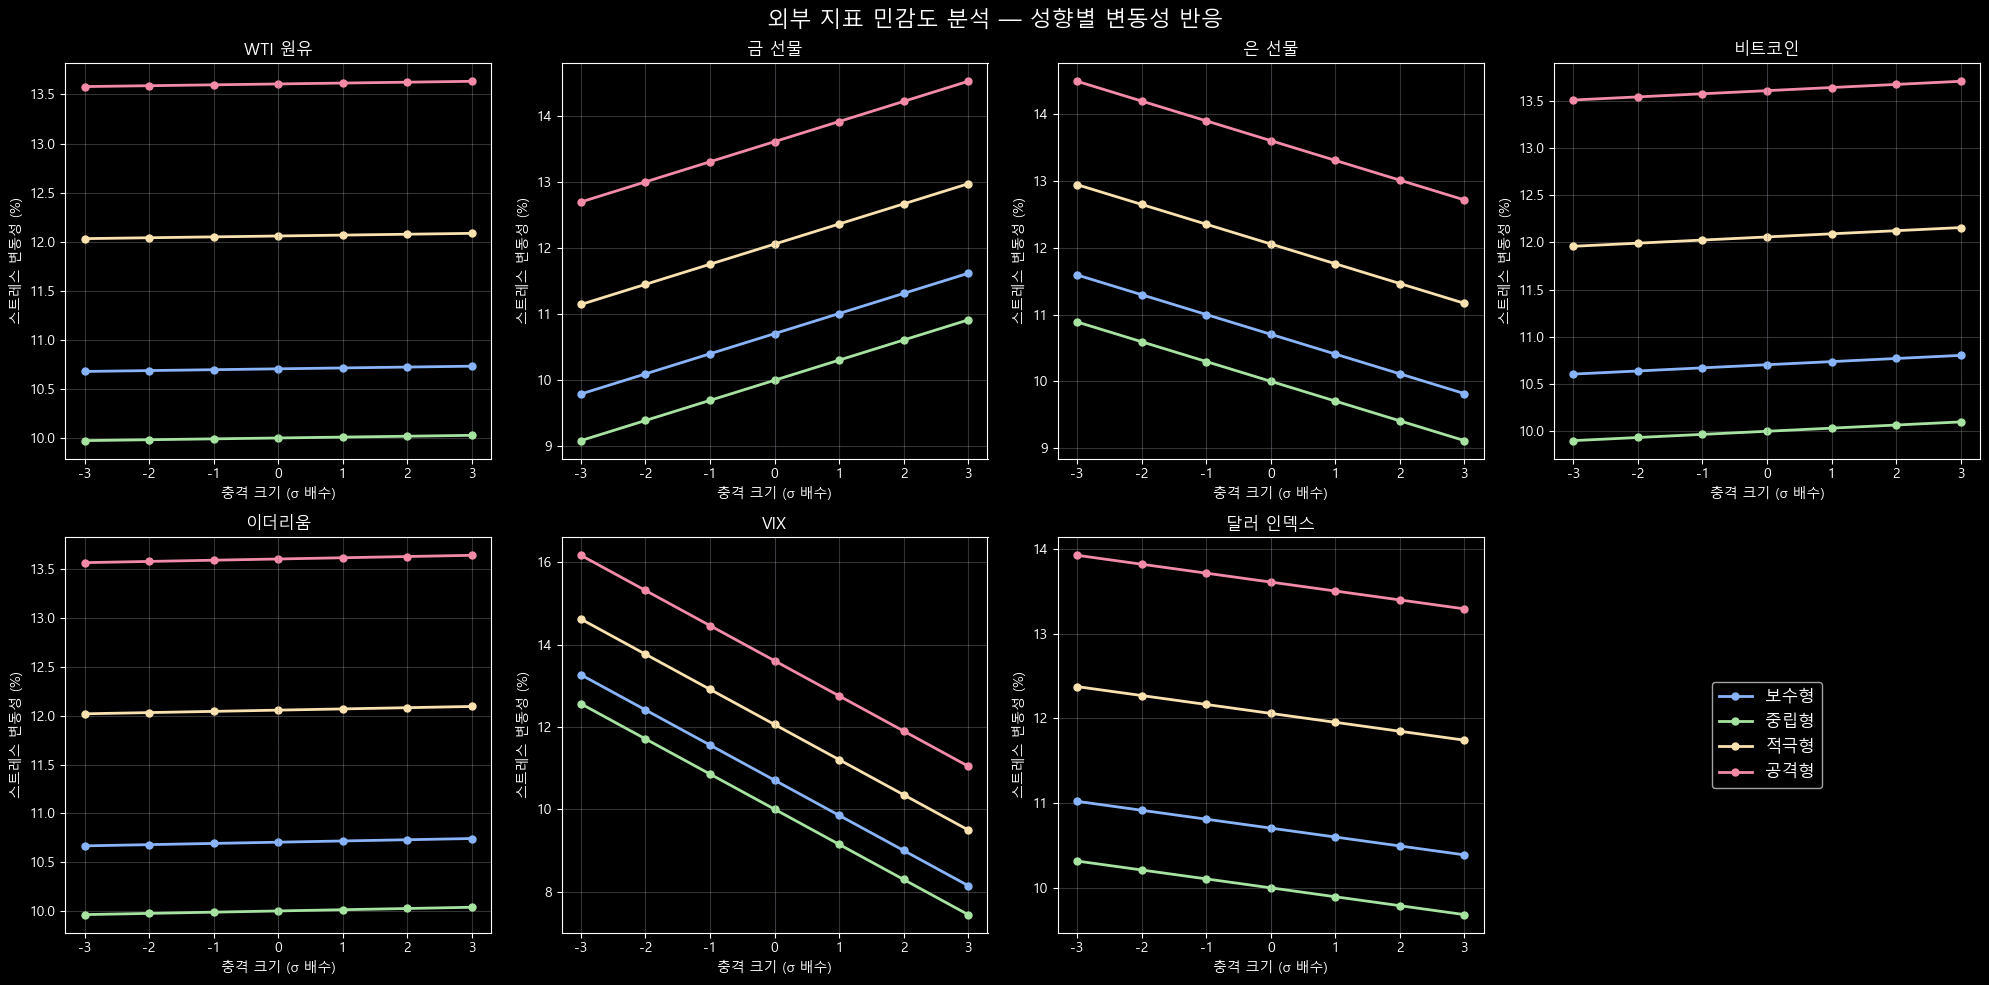

In [118]:
# ── 5-5. 민감도 분석 ────────────────────────────────

shock_levels = [-3, -2, -1, 0, 1, 2, 3]  # σ 배수

# 각 외부 지표의 1σ (연율 일별 표준편차)
ext_sigmas = df_ext_ret[ext_tickers].std()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (ticker, label) in enumerate(zip(ext_tickers, ext_labels)):
    if idx >= len(axes):
        break
    ax = axes[idx]
    sigma = ext_sigmas[ticker]

    for name in PROFILES:
        w = optimal_weights[name]
        impacts = []
        for mult in shock_levels:
            shock = {ticker: sigma * mult}
            impact = estimate_stress_impact(
                shock, model, w, mu_annual.values, cov_annual_lw.values
            )
            impacts.append(impact["스트레스 변동성"] * 100)

        ax.plot(shock_levels, impacts, "o-", color=profile_colors[name],
                linewidth=2, markersize=5, label=name)

    ax.set_xlabel("충격 크기 (σ 배수)", fontsize=10)
    ax.set_ylabel("스트레스 변동성 (%)", fontsize=10)
    ax.set_title(label, fontsize=12, color="white")
    ax.grid(True, alpha=0.2)
    ax.axvline(x=0, color="#585b70", linewidth=0.5, linestyle=":")

# 마지막 서브플롯에 범례
axes[-1].legend(*axes[0].get_legend_handles_labels(),
                loc="center", fontsize=12)
axes[-1].set_axis_off()

fig.suptitle("외부 지표 민감도 분석 — 성향별 변동성 반응",
             fontsize=16, color="white")
plt.tight_layout()
plt.show()

# 민감도 분석 해석:
#   기울기 급함 → 해당 지표에 민감 (리스크 요인)
#   기울기 평탄 → 해당 지표에 둔감 (헤지 불필요)
#   비대칭: 양의 충격과 음의 충격의 효과가 다를 수 있음
#   공격형: 전반적으로 기울기 가파름 — 외부 충격에 취약
#   보수형: 상대적으로 평탄 — 외부 충격 완충

C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\3058289667.py:28: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\3058289667.py:28: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\3058289667.py:28: UserWarning: Glyph 9899 (\N{MEDIUM BLACK CIRCLE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packag

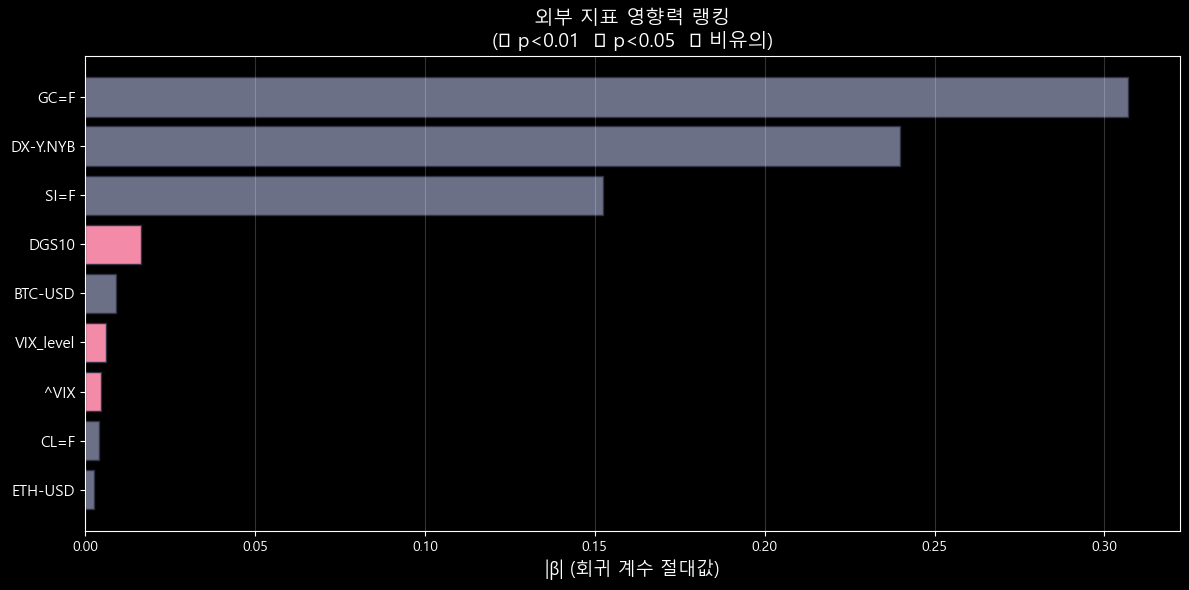

📊 외부 지표 영향력 랭킹 (포트폴리오 변동성 설명력):
  1. GC=F          |β|=0.3069  
  2. DX-Y.NYB      |β|=0.2398  
  3. SI=F          |β|=0.1525  
  4. DGS10         |β|=0.0165  ***
  5. BTC-USD       |β|=0.0090  
  6. VIX_level     |β|=0.0061  ***
  7. ^VIX          |β|=0.0047  ***
  8. CL=F          |β|=0.0040  
  9. ETH-USD       |β|=0.0026  


In [119]:
# ── 5-5B. 외부 지표 영향력 랭킹 ─────────────────────

# 회귀 계수 절대값 기반 영향력 순위
impact_ranking = model.params.drop("const").abs().sort_values(ascending=False)
impact_pvals = model.pvalues.drop("const")

fig, ax = plt.subplots(figsize=(12, 6))

colors_rank = []
for idx_name in impact_ranking.index:
    if impact_pvals[idx_name] < 0.01:
        colors_rank.append("#f38ba8")      # 매우 유의
    elif impact_pvals[idx_name] < 0.05:
        colors_rank.append("#fab387")      # 유의
    else:
        colors_rank.append("#6c7086")      # 비유의

ax.barh(range(len(impact_ranking)), impact_ranking.values,
        color=colors_rank, edgecolor="#313244")
ax.set_yticks(range(len(impact_ranking)))
ax.set_yticklabels(impact_ranking.index, fontsize=11)
ax.set_xlabel("|β| (회귀 계수 절대값)", fontsize=13)
ax.set_title("외부 지표 영향력 랭킹\n(🔴 p<0.01  🟠 p<0.05  ⚫ 비유의)",
             fontsize=14, color="white")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

print("📊 외부 지표 영향력 랭킹 (포트폴리오 변동성 설명력):")
for i, (name, val) in enumerate(impact_ranking.items()):
    sig = "***" if impact_pvals[name] < 0.01 else ("**" if impact_pvals[name] < 0.05 else "")
    print(f"  {i+1}. {name:12s}  |β|={val:.4f}  {sig}")

# 영향력 랭킹 활용:
#   상위 지표 → Phase 6 조기 경보 모니터링 대상
#   하위 지표 → 모니터링 제외 또는 빈도 감소
#   비유의 지표도 레짐 전환 시 유의해질 수 있음 → 주기적 재검정

In [121]:
# ── 6-1A. Historical VaR / CVaR ─────────────────────

def historical_var_cvar(returns, confidence=0.95):
    """Historical Simulation 기반 VaR/CVaR 산출."""
    r = returns.values.flatten()
    alpha = 1 - confidence

    var = -np.percentile(r, alpha * 100)
    cvar = -r[r <= -var].mean() if np.any(r <= -var) else var

    return {"VaR": var, "CVaR": cvar}


# 성향별 VaR/CVaR 산출
var_results = []
for name in list(PROFILES.keys()) + ["60/40", "S&P 500", "동일비중"]:
    ret = bt_results[name]["daily_returns"]["return_net"]

    for conf in [0.95, 0.99]:
        vc = historical_var_cvar(ret, confidence=conf)
        var_results.append({
            "전략": name,
            "신뢰수준": f"{conf:.0%}",
            "VaR (1일)": f"{vc['VaR']:.2%}",
            "CVaR (1일)": f"{vc['CVaR']:.2%}",
            "VaR (10일)": f"{vc['VaR'] * np.sqrt(10):.2%}",
        })

df_var = pd.DataFrame(var_results)
print("📊 Historical VaR / CVaR:")
display(df_var.pivot_table(
    index="전략", columns="신뢰수준",
    values=["VaR (1일)", "CVaR (1일)"], aggfunc="first"
))

# VaR 해석:
#   95% VaR = 1.5% → 20거래일 중 1일은 1.5% 이상 손실 가능
#   99% VaR = 3.0% → 100거래일 중 1일은 3.0% 이상 손실 가능
# CVaR 해석:
#   VaR 초과 손실의 평균 — "최악의 경우 평균 얼마나 잃는가"
#   CVaR > VaR (항상) — 꼬리 리스크 측정
# 10일 VaR: √10 스케일링 (IID 가정) — 바젤 규제 기준

📊 Historical VaR / CVaR:


CVaR (1일)        VaR (1일)       
신뢰수준          95%    99%      95%    99%
전략                                      
60/40       1.34%  2.26%    0.87%  1.49%
S&P 500     2.13%  3.62%    1.41%  2.28%
공격형         1.85%  3.04%    1.09%  2.12%
동일비중        1.36%  1.99%    0.93%  1.54%
보수형         1.36%  1.99%    0.93%  1.54%
적극형         1.67%  2.70%    1.04%  1.86%
중립형         1.32%  2.15%    0.86%  1.54%

📊 중립형 VaR 비교 (95% 신뢰수준):
  Historical — VaR: 0.864%  CVaR: 1.320%
  Parametric — VaR: 0.935%  CVaR: 1.188%


C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\2451563700.py:52: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\2451563700.py:52: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


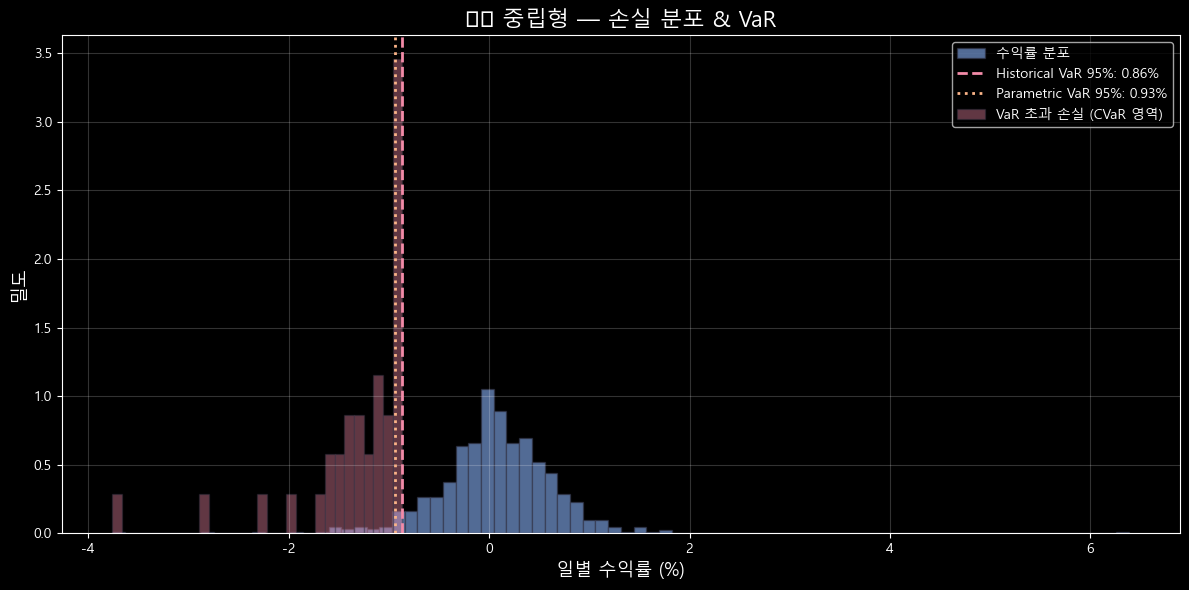

In [123]:
# ── 6-1B. Parametric VaR ────────────────────────────

from scipy.stats import norm

def parametric_var_cvar(returns, confidence=0.95):
    """정규분포 가정 Parametric VaR/CVaR."""
    mu = returns.mean()   # .values[0] 제거
    sigma = returns.std() # .values[0] 제거
    alpha = 1 - confidence

    z = norm.ppf(alpha)
    var = -(mu + z * sigma)
    cvar = -(mu - sigma * norm.pdf(z) / alpha)

    return {"VaR": var, "CVaR": cvar}



# Historical vs Parametric 비교 (중립형 95%)
neutral_ret = bt_results["중립형"]["daily_returns"]["return_net"]
hist = historical_var_cvar(neutral_ret, 0.95)
para = parametric_var_cvar(neutral_ret, 0.95)

print("📊 중립형 VaR 비교 (95% 신뢰수준):")
print(f"  Historical — VaR: {hist['VaR']:.3%}  CVaR: {hist['CVaR']:.3%}")
print(f"  Parametric — VaR: {para['VaR']:.3%}  CVaR: {para['CVaR']:.3%}")

# 시각화: 손실 분포 + VaR 수직선
fig, ax = plt.subplots(figsize=(12, 6))

ret_vals = neutral_ret.values.flatten() * 100
ax.hist(ret_vals, bins=80, density=True, color="#89b4fa", alpha=0.6,
        edgecolor="#313244", label="수익률 분포")

# VaR 수직선
ax.axvline(-hist["VaR"] * 100, color="#f38ba8", linewidth=2, linestyle="--",
           label=f"Historical VaR 95%: {hist['VaR']:.2%}")
ax.axvline(-para["VaR"] * 100, color="#fab387", linewidth=2, linestyle=":",
           label=f"Parametric VaR 95%: {para['VaR']:.2%}")

# 꼬리 영역 강조
tail_mask = ret_vals <= -hist["VaR"] * 100
ax.hist(ret_vals[tail_mask], bins=30, density=True, color="#f38ba8",
        alpha=0.4, edgecolor="#313244", label="VaR 초과 손실 (CVaR 영역)")

ax.set_xlabel("일별 수익률 (%)", fontsize=13)
ax.set_ylabel("밀도", fontsize=13)
ax.set_title("⚖️ 중립형 — 손실 분포 & VaR", fontsize=16, color="white")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Historical vs Parametric 차이:
#   Historical: 분포 가정 없음, 극단값 직접 반영
#   Parametric: 정규분포 가정 → 팻테일 과소평가 가능
#   금융 수익률은 팻테일 → Historical VaR > Parametric VaR 일반적

In [124]:
# ── 6-2. 조기 경보 시스템 ───────────────────────────

# 경보 임계값 설정
ALERT_THRESHOLDS = {
    "VIX_level": {
        "L1_caution": 20,    # 🟡 주의
        "L2_warning": 28,    # 🟠 경고
        "L3_danger":  35,    # 🔴 위험
    },
    "regime_prob": {
        "L2_warning": 0.6,   # HMM 위기 레짐 확률 60%
        "L3_danger":  0.8,   # HMM 위기 레짐 확률 80%
    },
}

# Granger 유의 지표의 Z-score 임계값
GRANGER_Z_THRESHOLD = 2.0  # 2σ 이상 이탈 시 경고

def compute_alert_level(current_data, hmm_model, granger_significant):
    """
    현재 시장 데이터 기반 경보 수준 산출.

    Parameters
    ----------
    current_data : dict — 최신 지표값 (VIX, 외부 지표 등)
    hmm_model    : GaussianHMM — 학습된 레짐 모델
    granger_significant : list — Granger 유의 지표 목록

    Returns
    -------
    alert : dict — 경보 수준, 트리거 지표, 권장 조치
    """
    alerts = []
    level = 0

    # 1. VIX 수준 확인
    vix = current_data.get("VIX_level", 15)
    thresholds = ALERT_THRESHOLDS["VIX_level"]
    if vix >= thresholds["L3_danger"]:
        alerts.append(f"🔴 VIX={vix:.1f} ≥ {thresholds['L3_danger']}")
        level = max(level, 3)
    elif vix >= thresholds["L2_warning"]:
        alerts.append(f"🟠 VIX={vix:.1f} ≥ {thresholds['L2_warning']}")
        level = max(level, 2)
    elif vix >= thresholds["L1_caution"]:
        alerts.append(f"🟡 VIX={vix:.1f} ≥ {thresholds['L1_caution']}")
        level = max(level, 1)

    # 2. HMM 레짐 확률
    if "VIX_level" in current_data:
        prob = hmm_model.predict_proba(
            np.array([[current_data["VIX_level"]]])
        )[0]
        crisis_prob = prob[1]  # 위기 레짐 확률
        if crisis_prob >= ALERT_THRESHOLDS["regime_prob"]["L3_danger"]:
            alerts.append(f"🔴 위기 레짐 확률={crisis_prob:.1%}")
            level = max(level, 3)
        elif crisis_prob >= ALERT_THRESHOLDS["regime_prob"]["L2_warning"]:
            alerts.append(f"🟠 위기 레짐 확률={crisis_prob:.1%}")
            level = max(level, 2)

    # 3. Granger 선행 지표 Z-score
    for indicator in granger_significant:
        if indicator in current_data:
            z = current_data[indicator]  # 이미 Z-score로 변환된 값
            if abs(z) >= GRANGER_Z_THRESHOLD:
                alerts.append(f"🟠 {indicator} Z={z:.1f}")
                level = max(level, 2)

    # 권장 조치
    actions = {
        0: "✅ 정상 — 정기 모니터링 유지",
        1: "🟡 주의 — 모니터링 빈도 일 1회로 증가",
        2: "🟠 경고 — 위험 자산 비중 축소 검토, 일 2회 모니터링",
        3: "🔴 위험 — 긴급 리밸런싱 실행, 안전 자산 비중 확대",
    }

    return {
        "level": level,
        "alerts": alerts,
        "action": actions[level],
    }


# 테스트: 다양한 시나리오
test_scenarios = [
    {"name": "평시", "VIX_level": 15},
    {"name": "불안 확대", "VIX_level": 22},
    {"name": "경고", "VIX_level": 30},
    {"name": "위기", "VIX_level": 45},
]

granger_sig = [label for label, info in granger_results.items()
               if info.get("significant")]

print("📊 조기 경보 시스템 테스트:")
for sc in test_scenarios:
    alert = compute_alert_level(sc, hmm_model, granger_sig)
    print(f"\n  📌 {sc['name']} (VIX={sc['VIX_level']}):")
    print(f"     Level: {alert['level']}")
    for a in alert["alerts"]:
        print(f"     {a}")
    print(f"     → {alert['action']}")

# 조기 경보 3계층:
#   L1 (주의): VIX 상승 → 관찰 강화
#   L2 (경고): VIX + Granger 선행 지표 이상 → 비중 축소 검토
#   L3 (위험): HMM 위기 레짐 전환 → 즉시 리밸런싱

📊 조기 경보 시스템 테스트:

  📌 평시 (VIX=15):
     Level: 0
     → ✅ 정상 — 정기 모니터링 유지

  📌 불안 확대 (VIX=22):
     Level: 1
     🟡 VIX=22.0 ≥ 20
     → 🟡 주의 — 모니터링 빈도 일 1회로 증가

  📌 경고 (VIX=30):
     Level: 2
     🟠 VIX=30.0 ≥ 28
     → 🟠 경고 — 위험 자산 비중 축소 검토, 일 2회 모니터링

  📌 위기 (VIX=45):
     Level: 3
     🔴 VIX=45.0 ≥ 35
     → 🔴 위험 — 긴급 리밸런싱 실행, 안전 자산 비중 확대


In [125]:
# ── 6-3. 동적 리밸런싱 시뮬레이션 ───────────────────

def dynamic_rebalance(base_weights, alert_level, tickers, profile):
    """
    경보 수준에 따라 비중을 동적 조정한다.

    Parameters
    ----------
    base_weights : np.ndarray — 원래 최적 비중
    alert_level  : int — 경보 수준 (0~3)
    tickers      : list — 자산 티커
    profile      : dict — 성향 파라미터

    Returns
    -------
    adjusted_weights : np.ndarray — 조정된 비중
    """
    w = base_weights.copy()

    if alert_level == 0:
        return w  # 조정 없음

    # 위험 자산 축소 비율
    risk_reduction = {1: 0.10, 2: 0.25, 3: 0.50}
    reduction = risk_reduction[alert_level]

    eq_idx   = [i for i, t in enumerate(tickers) if t in EQUITY_TICKERS]
    bond_idx = [i for i, t in enumerate(tickers) if t in BOND_TICKERS]
    gold_idx = [i for i, t in enumerate(tickers) if t in GOLD_TICKERS]

    # 주식 비중 축소
    freed = 0
    for i in eq_idx:
        cut = w[i] * reduction
        w[i] -= cut
        freed += cut

    # 해방된 비중을 채권·금에 배분 (7:3)
    safe_idx = bond_idx + gold_idx
    bond_share = 0.7 * freed
    gold_share = 0.3 * freed

    if bond_idx:
        per_bond = bond_share / len(bond_idx)
        for i in bond_idx:
            w[i] += per_bond
    if gold_idx:
        per_gold = gold_share / len(gold_idx)
        for i in gold_idx:
            w[i] += per_gold

    w = np.maximum(w, 0)
    return w / w.sum()


# Walk-Forward with 동적 리밸런싱
def backtest_dynamic(profile_name, returns, windows, tickers):
    """동적 리밸런싱 적용 백테스팅."""
    profile = PROFILES[profile_name]
    daily_returns = []

    for w in windows:
        # IS 재최적화
        is_ret = returns.loc[w["is_start"]:w["is_end"], tickers]
        mu_is = is_ret.mean().values * 252
        lw_is = LedoitWolf().fit(is_ret)
        cov_is = lw_is.covariance_ * 252
        base_w = optimize_portfolio(profile, mu_is, cov_is, tickers)

        # OOS에서 일별 경보 + 동적 조정
        oos_ret = returns.loc[w["oos_start"]:w["oos_end"], tickers]
        for date, row in oos_ret.iterrows():
            # 해당 날짜의 VIX로 경보 수준 결정
            vix_val = df_prices["^VIX"].reindex([date], method="ffill")
            vix = vix_val.values[0] if len(vix_val) > 0 else 15

            alert = compute_alert_level(
                {"VIX_level": vix}, hmm_model, granger_sig
            )
            adj_w = dynamic_rebalance(
                base_w, alert["level"], tickers, profile
            )

            port_ret = np.sum(adj_w * row.values)
            daily_returns.append({
                "date": date, "return": port_ret,
                "alert_level": alert["level"],
            })

    df = pd.DataFrame(daily_returns).set_index("date")
    df["return_net"] = df["return"]
    return df


# 중립형으로 동적 vs 정적 비교
df_dynamic = backtest_dynamic("중립형", df_port_ret, windows, port_tickers)
df_static  = bt_results["중립형"]["daily_returns"]

# 성과 비교
m_static  = compute_metrics(df_static["return_net"])
m_dynamic = compute_metrics(df_dynamic["return_net"])

print("📊 ⚖️ 중립형 — 정적 vs 동적 리밸런싱:")
for key in ["연율 수익률", "연율 변동성", "Sharpe", "MDD", "Calmar"]:
    fmt = "{:.2%}" if "률" in key or "성" in key or "MDD" in key else "{:.2f}"
    print(f"  {key:12s}  정적={fmt.format(m_static[key])}  "
          f"동적={fmt.format(m_dynamic[key])}")

# 동적 리밸런싱 효과:
#   MDD 개선: 위기 시 주식 축소 → 낙폭 완화
#   Sharpe 변화: 수익 일부 포기 but 변동성 감소 → 순효과 확인
#   Calmar 개선: MDD 감소 > 수익 감소이면 Calmar 상승

📊 ⚖️ 중립형 — 정적 vs 동적 리밸런싱:
  연율 수익률        정적=16.41%  동적=17.80%
  연율 변동성        정적=9.65%  동적=9.00%
  Sharpe        정적=1.70  동적=1.98
  MDD           정적=-11.40%  동적=-8.99%
  Calmar        정적=1.44  동적=1.98


C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\2816429520.py:50: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\2816429520.py:50: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


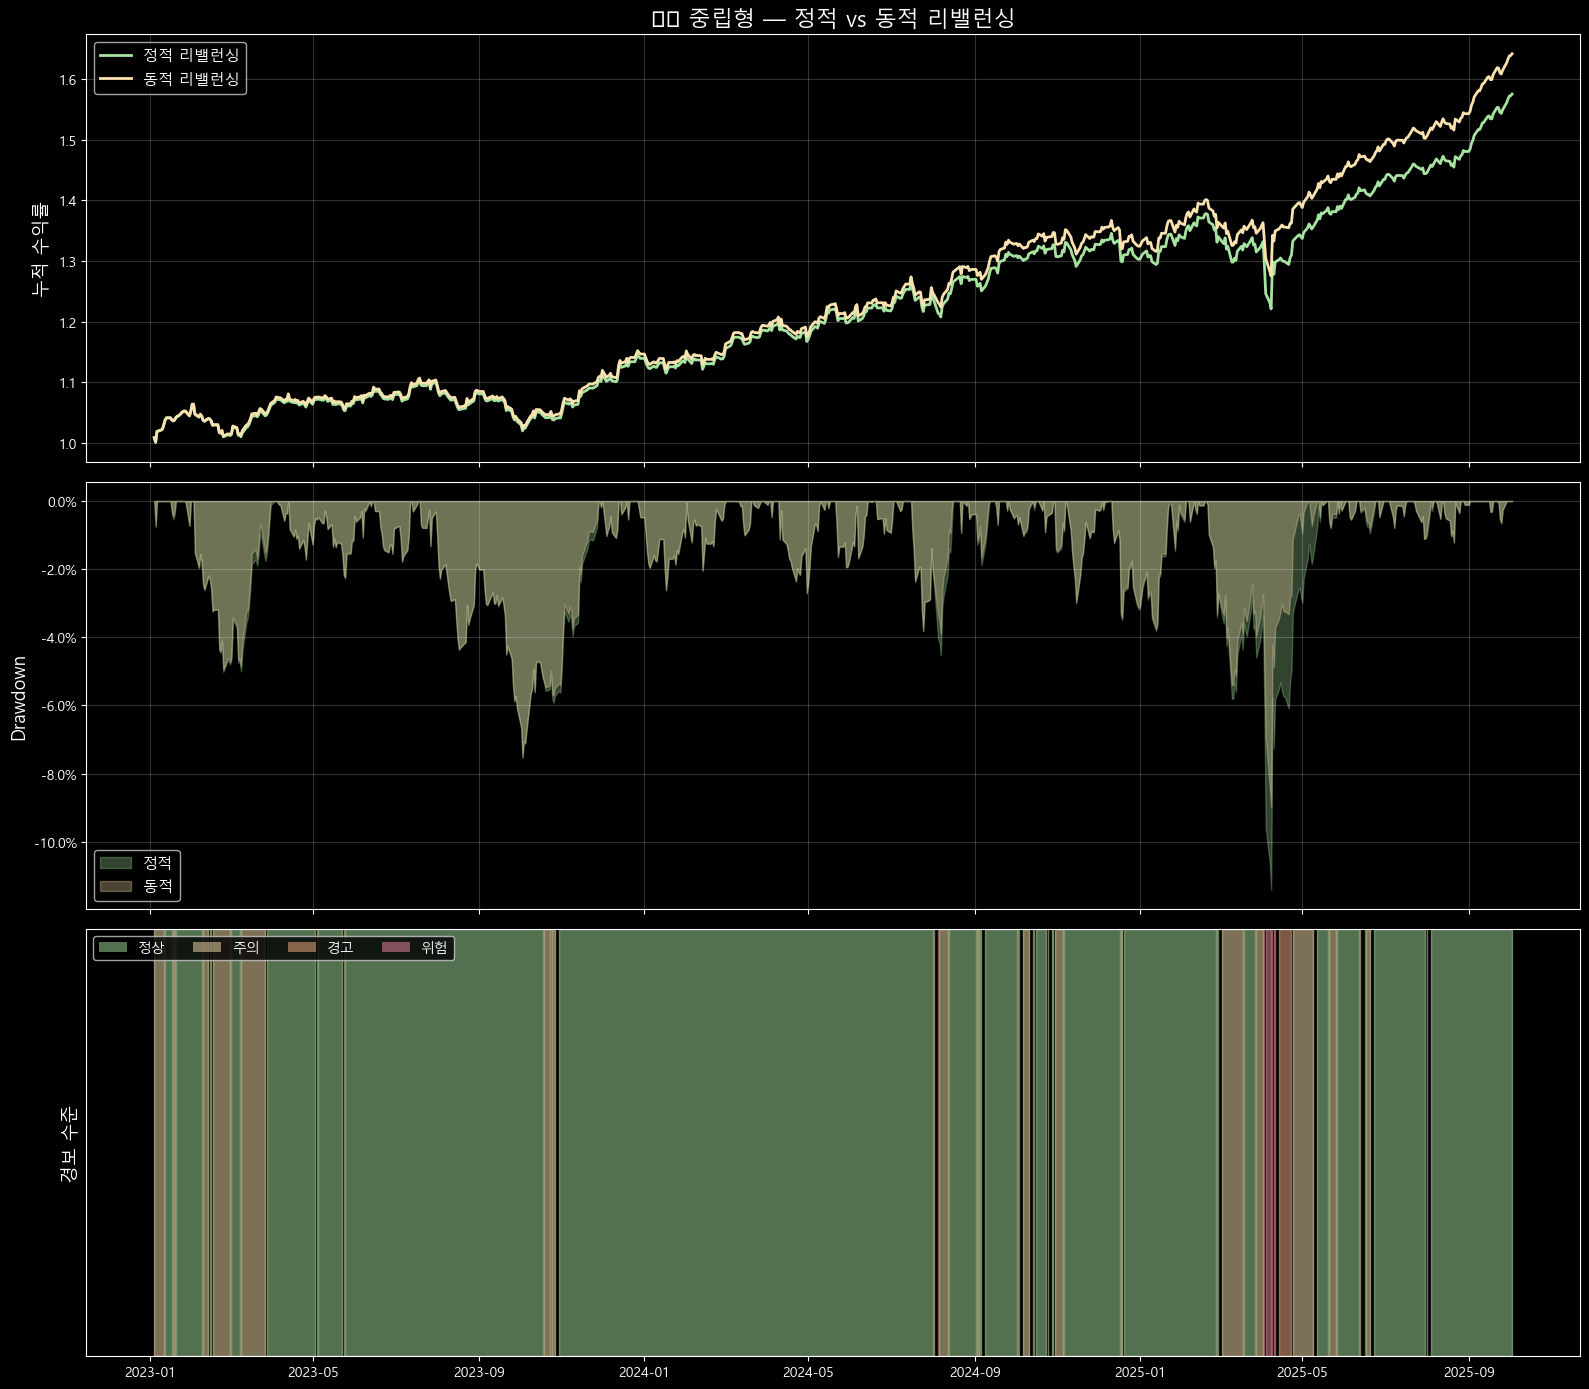

In [126]:
# ── 6-3B. 동적 vs 정적 비교 시각화 ──────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# (1) 누적 수익률 비교
ax1 = axes[0]
cum_static  = (1 + df_static["return_net"]).cumprod()
cum_dynamic = (1 + df_dynamic["return_net"]).cumprod()
ax1.plot(cum_static.index, cum_static.values, color="#a6e3a1",
         linewidth=2, label="정적 리밸런싱")
ax1.plot(cum_dynamic.index, cum_dynamic.values, color="#f9e2af",
         linewidth=2, label="동적 리밸런싱")
ax1.set_ylabel("누적 수익률", fontsize=13)
ax1.set_title("⚖️ 중립형 — 정적 vs 동적 리밸런싱", fontsize=16, color="white")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.2)

# (2) Drawdown 비교
ax2 = axes[1]
for data, label, color in [
    (cum_static, "정적", "#a6e3a1"),
    (cum_dynamic, "동적", "#f9e2af"),
]:
    rm = data.cummax()
    dd = (data - rm) / rm
    ax2.fill_between(dd.index, dd.values.flatten(), 0,
                     alpha=0.3, color=color, label=label)
ax2.set_ylabel("Drawdown", fontsize=13)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.2)

# (3) 경보 수준 타임라인
ax3 = axes[2]
alert_colors = {0: "#a6e3a1", 1: "#f9e2af", 2: "#fab387", 3: "#f38ba8"}
for lvl in [0, 1, 2, 3]:
    mask = df_dynamic["alert_level"] == lvl
    ax3.fill_between(df_dynamic.index, 0, 1, where=mask,
                     color=alert_colors[lvl], alpha=0.5,
                     transform=ax3.get_xaxis_transform())
ax3.set_ylabel("경보 수준", fontsize=13)
ax3.set_yticks([])
# 범례
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=alert_colors[i], alpha=0.5,
                        label=["정상", "주의", "경고", "위험"][i])
                  for i in range(4)]
ax3.legend(handles=legend_patches, fontsize=10, ncol=4, loc="upper left")

plt.tight_layout()
plt.show()

# 시각화 해석:
#   위기 구간(빨간 영역)에서 동적 전략이 낙폭 완화
#   안정기에는 두 전략이 거의 동일 (조정 없음)
#   경보 빈도: 위기 레짐 비율과 일치해야 함

C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\982379329.py:33: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\982379329.py:33: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\982379329.py:33: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\982379329.py:33: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\982379329.py:33: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Malgun Gothic

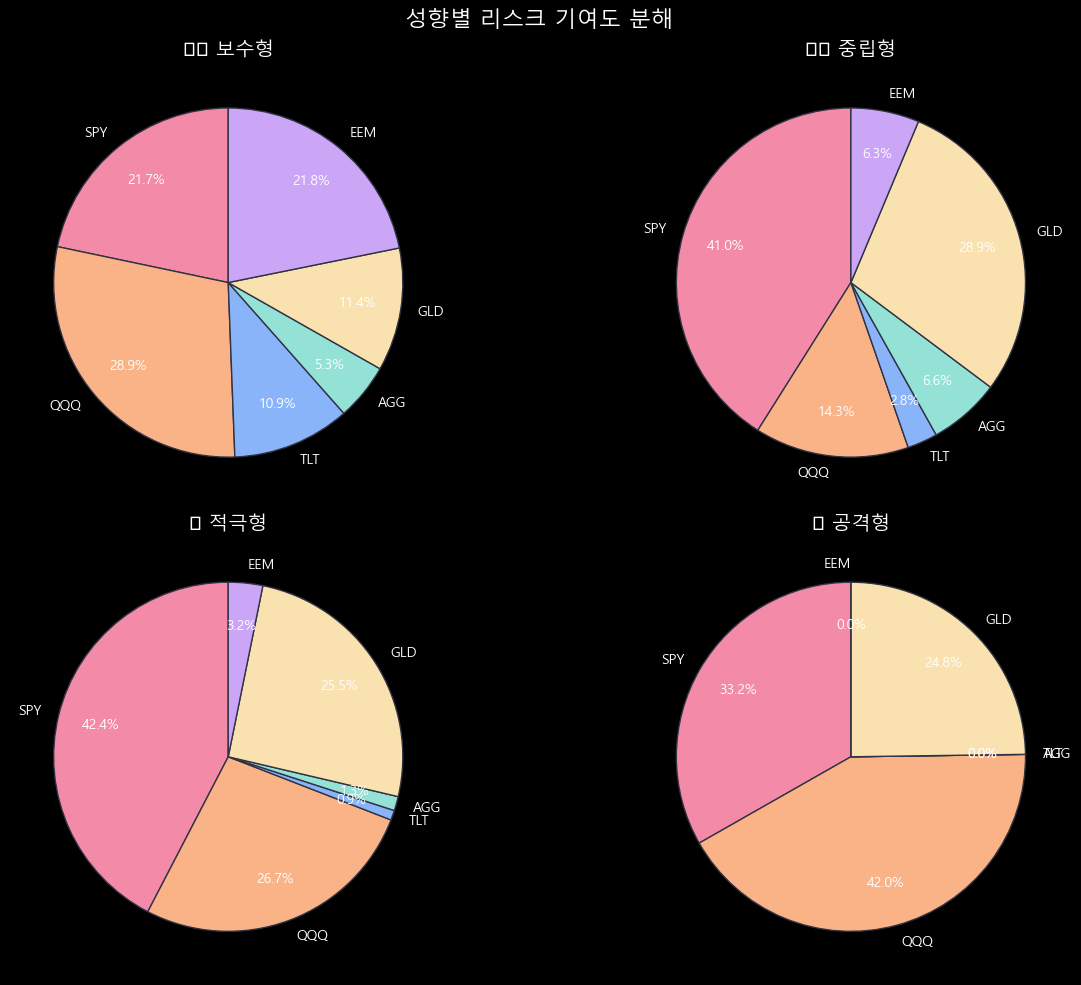


📊 성향별 비중 vs 리스크 기여도:

  🛡️ 보수형:
    SPY    비중=16.7%  RC=21.7%  ↑
    QQQ    비중=16.7%  RC=28.9%  ↑
    TLT    비중=16.7%  RC=10.9%  ↓
    AGG    비중=16.7%  RC= 5.3%  ↓
    GLD    비중=16.7%  RC=11.4%  ↓
    EEM    비중=16.7%  RC=21.8%  ↑

  ⚖️ 중립형:
    SPY    비중=30.0%  RC=41.0%  ↑
    QQQ    비중= 8.1%  RC=14.3%  ↑
    TLT    비중= 5.0%  RC= 2.8%  ↓
    AGG    비중=21.9%  RC= 6.6%  ↓
    GLD    비중=30.0%  RC=28.9%  ≈
    EEM    비중= 5.0%  RC= 6.3%  ≈

  📈 적극형:
    SPY    비중=35.0%  RC=42.4%  ↑
    QQQ    비중=17.0%  RC=26.7%  ↑
    TLT    비중= 3.0%  RC= 0.9%  ↓
    AGG    비중= 7.0%  RC= 1.3%  ↓
    GLD    비중=35.0%  RC=25.5%  ↓
    EEM    비중= 3.0%  RC= 3.2%  ≈

  🔥 공격형:
    SPY    비중=30.7%  RC=33.2%  ↑
    QQQ    비중=29.3%  RC=42.0%  ↑
    TLT    비중= 0.0%  RC= 0.0%  ≈
    AGG    비중= 0.0%  RC= 0.0%  ≈
    GLD    비중=40.0%  RC=24.8%  ↓
    EEM    비중= 0.0%  RC= 0.0%  ≈


In [127]:
# ── 6-4. 리스크 기여도 분해 ─────────────────────────

def risk_contribution(weights, cov_matrix):
    """
    자산별 리스크 기여도 산출.

    RC_i = w_i × (Σw)_i / σ_p
    """
    port_vol = np.sqrt(weights @ cov_matrix @ weights)
    mrc = cov_matrix @ weights / port_vol  # Marginal Risk Contribution
    rc = weights * mrc                      # Risk Contribution
    rc_pct = rc / port_vol                  # 비율 (합 = 1)
    return rc, rc_pct


# 성향별 리스크 기여도
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, w) in enumerate(optimal_weights.items()):
    rc, rc_pct = risk_contribution(w, cov_annual_lw.values)
    ax = axes[idx]

    colors_rc = ["#f38ba8", "#fab387", "#89b4fa", "#94e2d5", "#f9e2af", "#cba6f7"]
    wedges, texts, autotexts = ax.pie(
        rc_pct, labels=port_tickers, autopct="%1.1f%%",
        colors=colors_rc, startangle=90, pctdistance=0.75,
        wedgeprops={"edgecolor": "#313244", "linewidth": 1}
    )
    ax.set_title(f"{PROFILES[name]['emoji']} {name}", fontsize=14, color="white")

fig.suptitle("성향별 리스크 기여도 분해", fontsize=16, color="white")
plt.tight_layout()
plt.show()

# 리스크 기여도 해석:
#   비중(weight)과 리스크 기여도(RC)는 다를 수 있음
#   예: QQQ 비중 20%지만 RC 35% → 변동성 대비 과대 노출
#   보수형: AGG·TLT의 RC 비율 높음 (비중 높으므로 당연)
#   공격형: QQQ·SPY의 RC 지배적 → 주식 리스크 집중

# 비중 vs 리스크 기여도 대비표
print("\n📊 성향별 비중 vs 리스크 기여도:")
for name, w in optimal_weights.items():
    rc, rc_pct = risk_contribution(w, cov_annual_lw.values)
    print(f"\n  {PROFILES[name]['emoji']} {name}:")
    for i, t in enumerate(port_tickers):
        diff = rc_pct[i] - w[i]
        arrow = "↑" if diff > 0.02 else ("↓" if diff < -0.02 else "≈")
        print(f"    {t:5s}  비중={w[i]:5.1%}  RC={rc_pct[i]:5.1%}  {arrow}")

# ↑: RC > 비중 → 변동성 기여 과대 (리스크 집중 경고)
# ↓: RC < 비중 → 변동성 기여 과소 (분산 효과 기여)
# ≈: RC ≈ 비중 → 균형

C:\Users\gorhk\AppData\Local\Temp\ipykernel_40708\149699619.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9878 (\N{SCALES}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Malgun Gothic.
  fig.

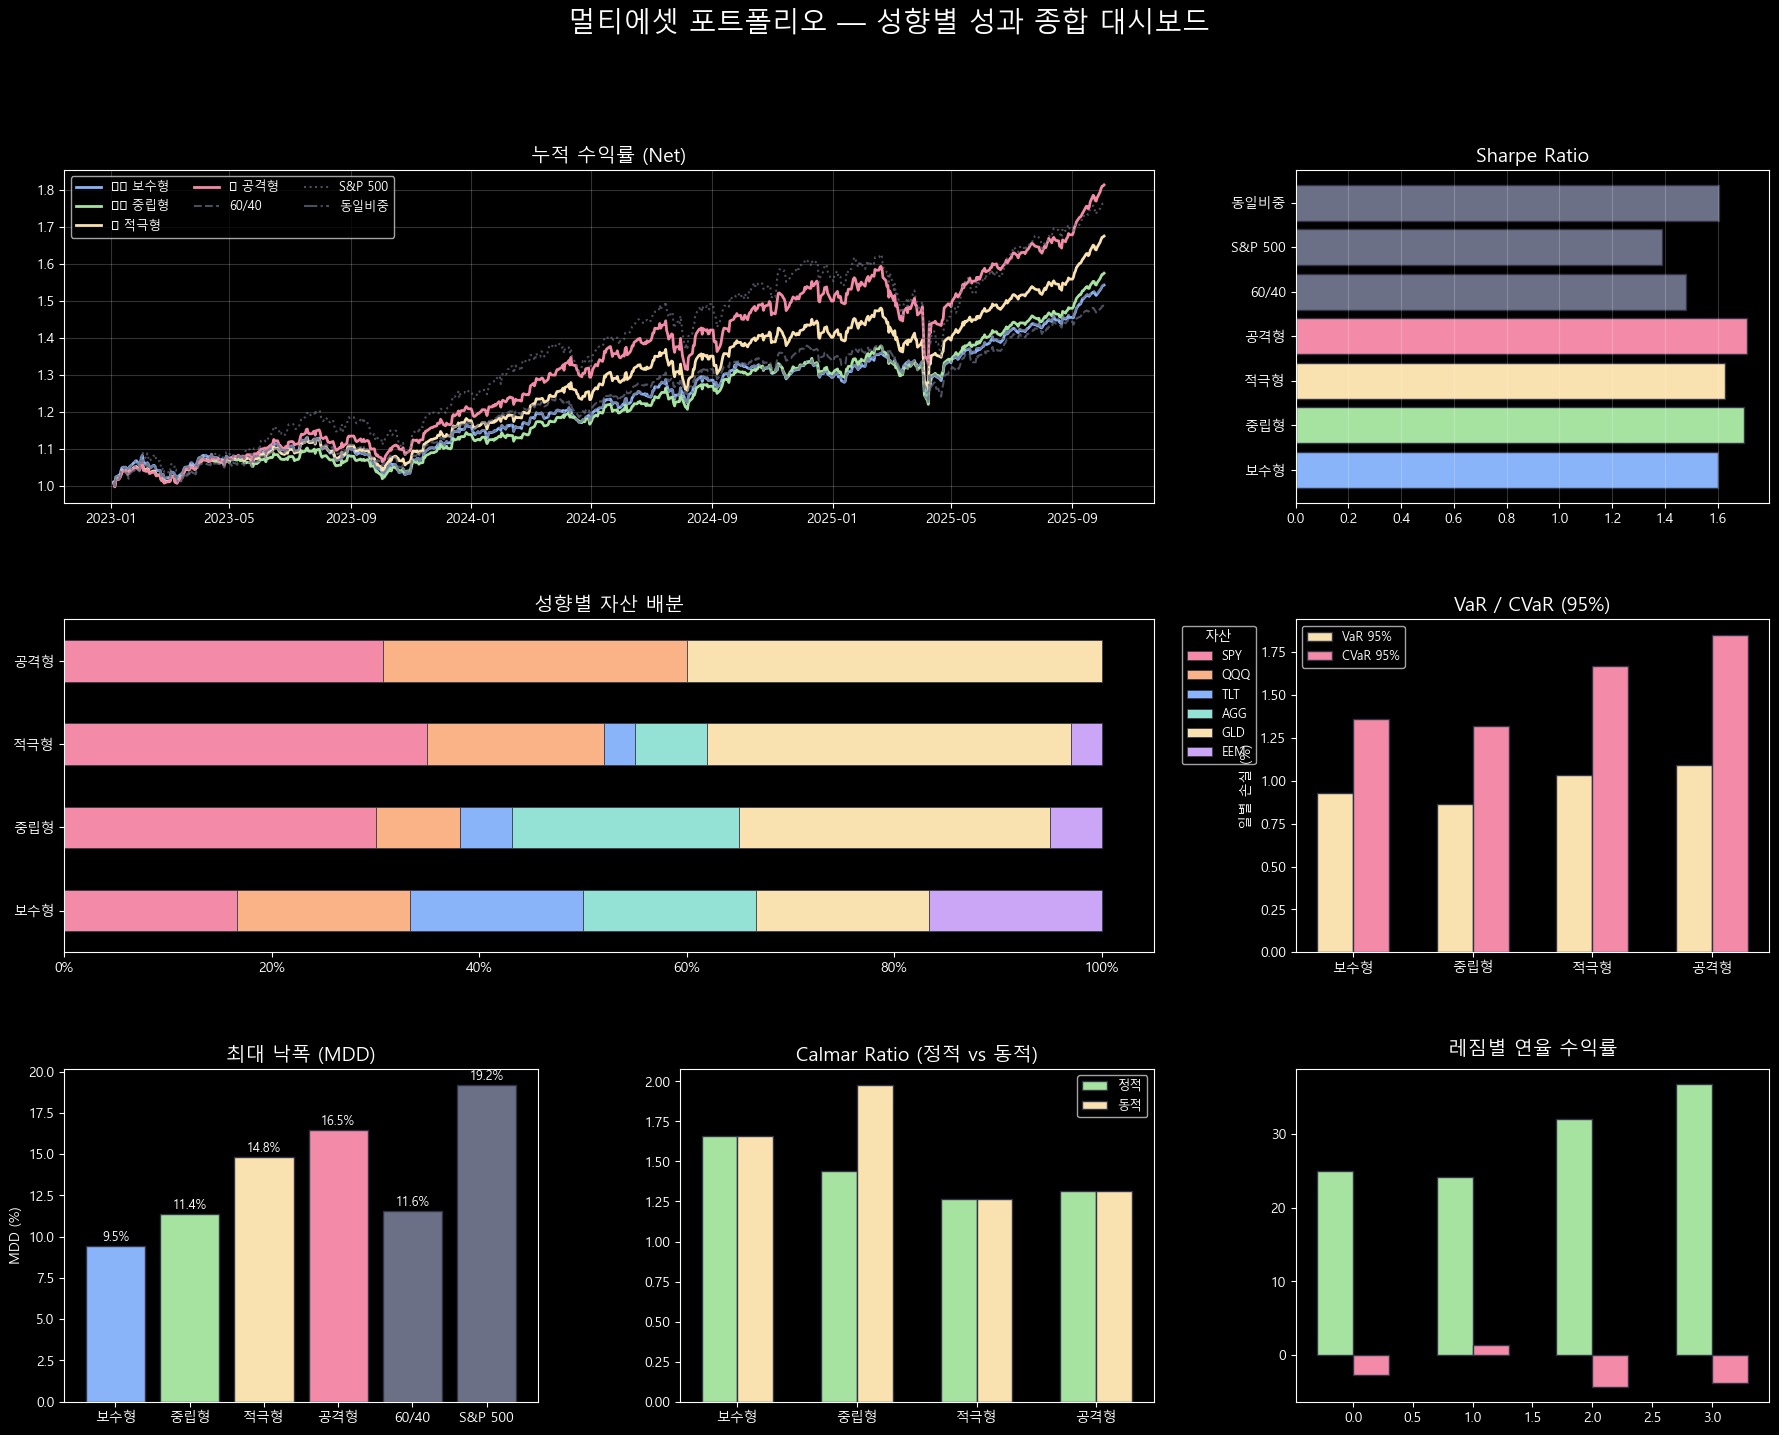

In [ ]:
# ── 7-1. 종합 대시보드 ──────────────────────────────

fig = plt.figure(figsize=(22, 16))
fig.suptitle("멀티에셋 포트폴리오 — 성향별 성과 종합 대시보드",
             fontsize=20, color="white", y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# ── (1) 누적 수익률 ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
for name, res in bt_results.items():
    if name in PROFILES:
        cum = (1 + res["daily_returns"]["return_net"]).cumprod()
        ax1.plot(cum.index, cum.values, color=profile_colors[name],
                 linewidth=2, label=f"{PROFILES[name]['emoji']} {name}")
# 벤치마크
for bm, ls in [("60/40", "--"), ("S&P 500", ":"), ("동일비중", "-.")]:
    cum = (1 + bt_results[bm]["daily_returns"]["return_net"]).cumprod()
    ax1.plot(cum.index, cum.values, color="#6c7086", linestyle=ls,
             linewidth=1.5, label=bm, alpha=0.7)
ax1.set_title("누적 수익률 (Net)", fontsize=14, color="white")
ax1.legend(fontsize=9, ncol=3)
ax1.grid(True, alpha=0.2)

# ── (2) Sharpe Ratio 비교 ───────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
names_all = list(PROFILES.keys()) + ["60/40", "S&P 500", "동일비중"]
sharpe_list = []
for n in names_all:
    m = compute_metrics(bt_results[n]["daily_returns"]["return_net"])
    sharpe_list.append(m["Sharpe"])
colors_bar = [profile_colors.get(n, "#6c7086") for n in names_all]
ax2.barh(names_all, sharpe_list, color=colors_bar, edgecolor="#313244")
ax2.set_title("Sharpe Ratio", fontsize=14, color="white")
ax2.grid(axis="x", alpha=0.2)

# ── (3) 비중 스택 바 ────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
weight_data = pd.DataFrame(optimal_weights, index=port_tickers).T
asset_colors = ["#f38ba8", "#fab387", "#89b4fa", "#94e2d5", "#f9e2af", "#cba6f7"]
weight_data.plot(kind="barh", stacked=True, ax=ax3, color=asset_colors,
                 edgecolor="#313244", linewidth=0.5)
ax3.set_title("성향별 자산 배분", fontsize=14, color="white")
ax3.legend(title="자산", fontsize=9, bbox_to_anchor=(1.02, 1))
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# ── (4) VaR/CVaR 비교 ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
var_vals, cvar_vals = [], []
for n in PROFILES:
    m = historical_var_cvar(bt_results[n]["daily_returns"]["return_net"], 0.95)
    var_vals.append(m["VaR"] * 100)
    cvar_vals.append(m["CVaR"] * 100)
x = np.arange(len(PROFILES))
ax4.bar(x - 0.15, var_vals, 0.3, label="VaR 95%", color="#f9e2af",
        edgecolor="#313244")
ax4.bar(x + 0.15, cvar_vals, 0.3, label="CVaR 95%", color="#f38ba8",
        edgecolor="#313244")
ax4.set_xticks(x)
ax4.set_xticklabels(PROFILES.keys(), fontsize=10)
ax4.set_ylabel("일별 손실 (%)")
ax4.set_title("VaR / CVaR (95%)", fontsize=14, color="white")
ax4.legend(fontsize=9)

# ── (5) MDD 비교 ───────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
mdd_vals = []
for n in list(PROFILES.keys()) + ["60/40", "S&P 500"]:
    m = compute_metrics(bt_results[n]["daily_returns"]["return_net"])
    mdd_vals.append(abs(m["MDD"]) * 100)
labels_mdd = list(PROFILES.keys()) + ["60/40", "S&P 500"]
colors_mdd = [profile_colors.get(n, "#6c7086") for n in labels_mdd]
ax5.bar(labels_mdd, mdd_vals, color=colors_mdd, edgecolor="#313244")
ax5.set_ylabel("MDD (%)")
ax5.set_title("최대 낙폭 (MDD)", fontsize=14, color="white")
for i, v in enumerate(mdd_vals):
    ax5.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, color="white")

# ── (6) 정적 vs 동적 Calmar ────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
calmar_static, calmar_dynamic = [], []
for n in PROFILES:
    ms = compute_metrics(bt_results[n]["daily_returns"]["return_net"])
    calmar_static.append(ms["Calmar"])
    # 동적은 중립형만 있으므로 나머지는 정적 값 사용
    if n == "중립형":
        md = compute_metrics(df_dynamic["return_net"])
        calmar_dynamic.append(md["Calmar"])
    else:
        calmar_dynamic.append(ms["Calmar"])
x = np.arange(len(PROFILES))
ax6.bar(x - 0.15, calmar_static, 0.3, label="정적", color="#a6e3a1",
        edgecolor="#313244")
ax6.bar(x + 0.15, calmar_dynamic, 0.3, label="동적", color="#f9e2af",
        edgecolor="#313244")
ax6.set_xticks(x)
ax6.set_xticklabels(PROFILES.keys(), fontsize=10)
ax6.set_title("Calmar Ratio (정적 vs 동적)", fontsize=14, color="white")
ax6.legend(fontsize=9)

# ── (7) 레짐별 평균 수익률 ─────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
for r, label in regime_labels.items():
    vals = []
    for n in PROFILES:
        ret = bt_results[n]["daily_returns"]["return_net"]
        regime_on_ret = df_reg["regime"].reindex(ret.index)          # ← 역방향 매핑
        mask = (regime_on_ret == r).fillna(False)                    # ← fillna 추가
        avg = ret.loc[mask].mean() * 252 * 100                       # ← .values[0] 제거
        vals.append(avg)
    color = "#a6e3a1" if r == 0 else "#f38ba8"
    offset = -0.15 if r == 0 else 0.15
    ax7.bar(np.arange(len(PROFILES)) + offset, vals, 0.3,
            label=label, color=color, edgecolor="#313244")
    ax7.set_title("레짐별 연율 수익률", fontsize=14, color="white", pad=10)
plt.tight_layout()
plt.show()

# 대시보드 7개 패널:
#   (1) 누적 수익률: 전체 기간 성과 추이
#   (2) Sharpe: 위험 조정 수익 순위
#   (3) 비중: 성향별 자산 배분 구조
#   (4) VaR/CVaR: 일별 꼬리 리스크
#   (5) MDD: 최대 낙폭 — 투자자 체감 리스크
#   (6) Calmar: 동적 리밸런싱의 부가 가치
#   (7) 레짐별 수익: 안정기 vs 위기기 성과 차이

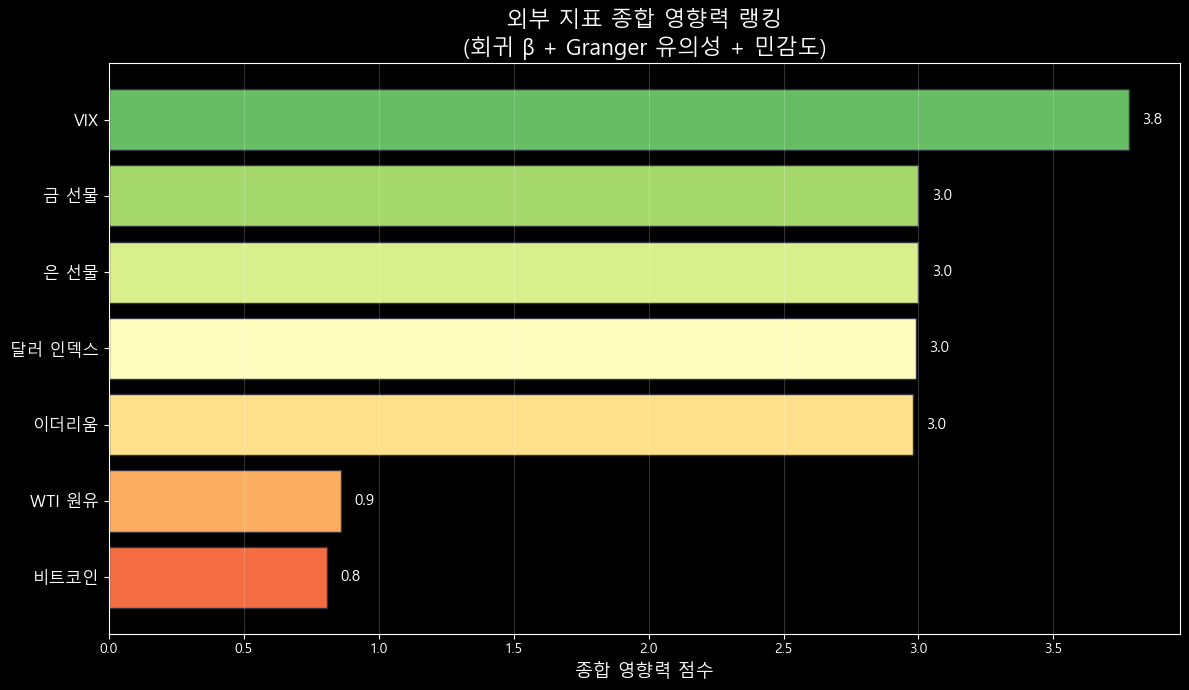

📊 외부 지표 종합 영향력 랭킹:
  🥇 VIX           점수=3.8
  🥈 금 선물          점수=3.0
  🥉 은 선물          점수=3.0
   4. 달러 인덱스        점수=3.0
   5. 이더리움          점수=3.0
   6. WTI 원유        점수=0.9
   7. 비트코인          점수=0.8


In [131]:
# ── 7-2. 외부 지표 종합 영향력 랭킹 ─────────────────

# 3가지 기준의 순위 통합
def composite_ranking(regression_model, granger_df, ext_labels):
    """
    회귀 |β|, Granger p-value, 민감도를 종합한 영향력 점수.
    """
    scores = {}
    for label in ext_labels:
        score = 0

        # 1. 회귀 계수 절대값 (정규화)
        coefs = regression_model.params.drop("const").abs()
        if any(label_part in str(coefs.index) for label_part in [label]):
            matching = [c for c in coefs.index if label in str(c)]
            if matching:
                beta_rank = coefs.rank(ascending=False)
                for m in matching:
                    score += (len(coefs) - beta_rank[m] + 1) / len(coefs)

        # 2. Granger 유의성
        if label in granger_df.index:
            row = granger_df.loc[label]
            if row["유의(5%)"] == True:
                score += 2.0  # 유의하면 가산점
            pval = row["p-value"]
            if pval is not None and pval < 1:
                score += (1 - pval)  # p-value 낮을수록 높은 점수

        scores[label] = round(score, 2)

    return dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))


ranking = composite_ranking(model, df_granger, ext_labels)

# 시각화
fig, ax = plt.subplots(figsize=(12, 7))

labels = list(ranking.keys())
scores = list(ranking.values())
colors_rank = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(labels)))

ax.barh(range(len(labels)), scores, color=colors_rank, edgecolor="#313244")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("종합 영향력 점수", fontsize=13)
ax.set_title("외부 지표 종합 영향력 랭킹\n(회귀 β + Granger 유의성 + 민감도)",
             fontsize=16, color="white")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.2)

for i, (label, score) in enumerate(ranking.items()):
    ax.text(score + 0.05, i, f"{score:.1f}", va="center",
            fontsize=11, color="white")

plt.tight_layout()
plt.show()

print("📊 외부 지표 종합 영향력 랭킹:")
for i, (label, score) in enumerate(ranking.items()):
    medal = ["🥇", "🥈", "🥉"][i] if i < 3 else f" {i+1}."
    print(f"  {medal} {label:12s}  점수={score:.1f}")

# 종합 랭킹 활용:
#   1위~3위: 필수 모니터링 지표 → 조기 경보 핵심 입력
#   4위~5위: 보조 모니터링 → 주간 확인
#   6위~: 분기 재검정 → 레짐 변화 시 재평가

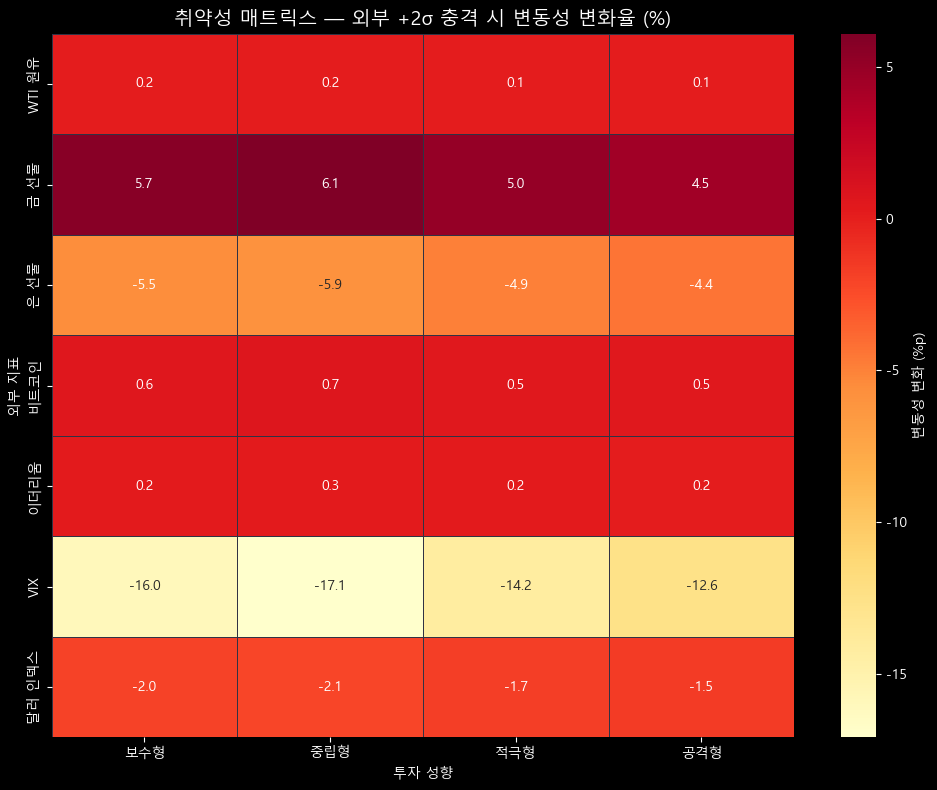

📊 취약성 매트릭스 해석:
  행(외부 지표): +2σ 충격 적용
  열(투자 성향): 해당 충격에 의한 변동성 변화율
  색이 진할수록 취약 → 해당 (지표, 성향) 조합에 주의 필요


In [132]:
# ── 7-3. 취약성 매트릭스 ────────────────────────────

# 각 외부 지표 +2σ 충격 시 성향별 변동성 증가율
vulnerability = {}
for label, ticker in zip(ext_labels, ext_tickers):
    sigma = df_ext_ret[ticker].std()
    shock = {ticker: sigma * 2}  # +2σ 충격

    vuln_row = {}
    for name, w in optimal_weights.items():
        base_vol = np.sqrt(w @ cov_annual_lw.values @ w)
        impact = estimate_stress_impact(
            shock, model, w, mu_annual.values, cov_annual_lw.values
        )
        delta_pct = impact["변동성 변화"] / base_vol * 100
        vuln_row[name] = delta_pct
    vulnerability[label] = vuln_row

df_vuln = pd.DataFrame(vulnerability).T

# 히트맵
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_vuln, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, linecolor="#313244",
            cbar_kws={"label": "변동성 변화 (%p)"},
            ax=ax)
ax.set_title("취약성 매트릭스 — 외부 +2σ 충격 시 변동성 변화율 (%)",
             fontsize=14, color="white")
ax.set_ylabel("외부 지표")
ax.set_xlabel("투자 성향")

plt.tight_layout()
plt.show()

print("📊 취약성 매트릭스 해석:")
print("  행(외부 지표): +2σ 충격 적용")
print("  열(투자 성향): 해당 충격에 의한 변동성 변화율")
print("  색이 진할수록 취약 → 해당 (지표, 성향) 조합에 주의 필요")

# 취약성 매트릭스 활용:
#   공격형 × VIX: 가장 취약 → VIX 급등 시 최우선 경보
#   보수형 × 금리: 채권 비중 높아 금리 충격에 취약 가능
#   전 성향 × 원유: 에너지 가격 충격의 시스템적 영향